# SeamlessM4T v2 → Textless Pure S2ST (~673M)
## Voice Cloning · 5 Languages · Long-Form Audio · INTERSPEECH/IWSLT 2026

**Architectural transformation paper** — converting SeamlessM4T v2 from text-mediated S2ST
to a fully textless, speaker-preserving, long-form-capable S2ST system.

| Component | Original | After |
|---|---|---|
| Text Decoder | 867M, 24 layers | **0M — permanently removed** |
| lm_head + shared vocab | ~262M | **0M — removed** |
| Speech Encoder | 635M, 24L | **~441M, 16L** (BI+iterative prune) |
| T2U Model | 262M, 6+6L | **~175M, 4+4L** (LaCo RDSC merge) |
| CIF Connector | — | **~5M NEW** (trained from scratch) |
| Speaker Adapter | — | **~0.1M NEW** (ECAPA→vocoder 192→256) |
| **Total** | **1805M** | **~673M** |

**Papers:** S2UT (Lee ACL 2022) · SeamlessExpressive (arXiv:2312.05187) ·
LaCo (Yang EMNLP 2024) · CIF (Dong & Xu ICASSP 2020) · ECAPA-TDNN (Desplanques IS 2020) ·
DoRA (Liu ICML 2024) · ShortGPT (ACL 2025) · MMS (Pratap 2023)

**Phases:** P0 V1-Baseline → P1 Vocab5L → P2 EncPrune16L → P3 LaCoT2U →
P4 TextlessArch → P5 KD-Extract → P6a CIF-FeatureKD → P6b E2E-DoRA → P7 FullBenchmark


## ⚙️ Setup — run ALL at the start of EVERY Kaggle session

In [1]:
import os, sys, subprocess, pathlib, re, glob, json, gc, copy, time, math, shutil, random
import warnings; warnings.filterwarnings('ignore')

ON_KAGGLE = os.path.exists('/kaggle/working')
ON_COLAB  = not ON_KAGGLE
PLATFORM  = 'kaggle' if ON_KAGGLE else 'colab'

GDRIVE_MOUNT = '/content/drive/MyDrive/seamTL'   # ← NEW project folder
KAGGLE_WORK  = '/kaggle/working'

WORK_DIR  = KAGGLE_WORK if ON_KAGGLE else GDRIVE_MOUNT
CKPT_DIR  = f'{WORK_DIR}/checkpoints'
AUDIO_DIR = f'{WORK_DIR}/audio'
FIG_DIR   = f'{WORK_DIR}/figures'
MODEL_DIR = f'{WORK_DIR}/models'

GDRIVE_ROOT = 'gdrive:seamTL'   # rclone remote root (Kaggle only)


In [2]:
if ON_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print(f'Drive mounted. Working folder: {GDRIVE_MOUNT}')
else:
    print('Kaggle: skipping Drive mount.')


Kaggle: skipping Drive mount.


In [3]:
for d in [WORK_DIR, CKPT_DIR, AUDIO_DIR, FIG_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)
print(f'Platform : {PLATFORM}')
print(f'Work dir : {WORK_DIR}')
print(f'Checkpts : {CKPT_DIR}')


Platform : kaggle
Work dir : /kaggle/working
Checkpts : /kaggle/working/checkpoints


In [4]:
if ON_KAGGLE:
    subprocess.run('curl -s https://rclone.org/install.sh | sudo bash',
                   shell=True, capture_output=True)
    ver = subprocess.run('rclone version', shell=True, capture_output=True, text=True)
    print(ver.stdout.split('\n')[0])
else:
    print('Colab: rclone not needed — using mounted Drive directly.')
    if not os.path.exists('/content/drive/MyDrive'):
        print('WARNING: Drive does not appear to be mounted.')
    else:
        print('Drive mount: OK')


rclone v1.73.5


In [5]:
def _get_secret(key):
    if ON_KAGGLE:
        try:
            from kaggle_secrets import UserSecretsClient
            return UserSecretsClient().get_secret(key)
        except Exception as e:
            raise RuntimeError(f'Kaggle secret {key!r} not found: {e}')
    else:
        try:
            from google.colab import userdata
            return userdata.get(key)
        except Exception as e:
            raise RuntimeError(f'Colab secret {key!r} not found: {e}')

if ON_KAGGLE:
    RCLONE_CONF = _get_secret('RCLONE_CONF')
    raw = RCLONE_CONF.strip()
    raw = re.sub(r'\s*(\[[^\]]+\])\s*', r'\n\1\n', raw)
    raw = re.sub(r'\s+(type|scope|token|team_drive|client_id|client_secret|'
                 r'root_folder_id|service_account_file|drive_id)\s*=\s*',
                 r'\n\1 = ', raw)
    raw = raw.strip() + '\n'
    rclone_cfg = pathlib.Path.home() / '.config/rclone/rclone.conf'
    rclone_cfg.parent.mkdir(parents=True, exist_ok=True)
    rclone_cfg.write_text(raw)
    r = subprocess.run('rclone lsd gdrive:', shell=True, capture_output=True, text=True)
    print('Drive root:' if r.returncode == 0 else 'rclone FAILED:')
    print(r.stdout[:300] or r.stderr[:300])
else:
    print('Colab: skipping rclone config.')

try:
    HF_TOKEN = _get_secret('HF_TOKEN')
    from huggingface_hub import login
    login(HF_TOKEN)
    print('HuggingFace login: OK')
except Exception as e:
    print(f'HF login skipped: {e}')


Drive root:
           0 2026-04-11 05:42:37        -1 .ipynb_checkpoints
           0 2026-04-17 11:03:10        -1 Colab Notebooks
           0 2025-11-10 11:33:43        -1 ScholarMate
           0 2026-04-05 12:59:09        -1 cse465
           0 2026-04-12 12:42:04        -1 cse465v5
           0 2026-04-1
HuggingFace login: OK


In [6]:
subprocess.run([
    'pip', 'install', '-q',
    'transformers>=4.41.0', 'datasets', 'torchaudio', 'speechbrain>=1.0.0',
    'peft>=0.10.0', 'librosa', 'jiwer', 'evaluate', 'sacrebleu',
    'sentencepiece', 'accelerate', 'matplotlib', 'seaborn',
    'soundfile', 'requests', 'pandas',
], check=True)
print('All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 35.1 MB/s eta 0:00:00
All packages installed.


In [7]:
from transformers.utils import logging
logging.set_verbosity_error()

In [8]:
import torch
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [9]:
# ── pulled verbatim from seamless-cse465v5 Cell 14 ──
import torch
from datetime import datetime

_CUSTOM_STATE_FILE = '_custom_state.pt'
_PRUNING_MANIFEST  = 'pruning_manifest.pt'

def _rclone_push(local_path, remote_subpath):
    if not ON_KAGGLE: return
    r = subprocess.run(
        f'rclone copy "{local_path}" "{GDRIVE_ROOT}/{remote_subpath}/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
        shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'[rclone] WARNING: push failed for {local_path}: {r.stderr[:200]}')

def _rclone_pull_model(stage_name):
    if not ON_KAGGLE: return
    local = f'{MODEL_DIR}/{stage_name}'
    os.makedirs(local, exist_ok=True)
    r = subprocess.run(
        f'rclone sync "{GDRIVE_ROOT}/models/{stage_name}/" "{local}/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
        shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f'[rclone] model pull failed for {stage_name}: {r.stderr[:300]}')
    print(f'[rclone] Pulled {stage_name} → {local}')

def save_checkpoint(state, name, step=0, keep=3):
    fname = f'{name}_step{step:06d}.pt'
    path  = f'{CKPT_DIR}/{fname}'
    torch.save(state, path)
    mb = os.path.getsize(path) / 1e6
    print(f'[ckpt] Saved {fname} ({mb:.1f} MB)')
    if ON_KAGGLE: _rclone_push(path, 'checkpoints')
    old = sorted(glob.glob(f'{CKPT_DIR}/{name}_step*.pt'))
    for f in old[:-keep]:
        if os.path.exists(f): os.remove(f)

def load_latest_checkpoint(name):
    files = sorted(glob.glob(f'{CKPT_DIR}/{name}_step*.pt'))
    if not files:
        print(f'[ckpt] No checkpoint for {name!r}')
        return None
    state = torch.load(files[-1], map_location='cpu', weights_only=False)
    print(f'[ckpt] Loaded {os.path.basename(files[-1])}')
    return state

def sync_checkpoints_from_drive():
    if ON_KAGGLE:
        print('[ckpt] Syncing from rclone remote...')
        r = subprocess.run(
            f'rclone sync "{GDRIVE_ROOT}/checkpoints/" "{CKPT_DIR}/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
            shell=True, capture_output=True, text=True)
        if r.returncode != 0:
            print(f'[ckpt] WARNING: {r.stderr[:300]}')
    else:
        print(f'[ckpt] Colab: reading directly from {CKPT_DIR}')
    files = sorted(os.listdir(CKPT_DIR)) if os.path.exists(CKPT_DIR) else []
    print(f'[ckpt] {len(files)} file(s) available')
    for f in files:
        mb = os.path.getsize(f'{CKPT_DIR}/{f}') / 1e6
        print(f'  {f:<55} {mb:>7.1f} MB')

print('Checkpoint helpers ready.')


Checkpoint helpers ready.


In [10]:
import torch.nn as nn, torch.nn.functional as F

_CUSTOM_ATTR_NAMES = ['_vocab_remap_to_old']

def _save_custom_state(mdl, path):
    state = {a: getattr(mdl, a) for a in _CUSTOM_ATTR_NAMES if hasattr(mdl, a)}
    if state:
        torch.save(state, os.path.join(path, _CUSTOM_STATE_FILE))
        print(f'  Saved custom state: {list(state.keys())}')

def _load_custom_state(mdl, path):
    fpath = os.path.join(path, _CUSTOM_STATE_FILE)
    if not os.path.exists(fpath): return
    state = torch.load(fpath, map_location='cpu', weights_only=False)
    for k, v in state.items(): setattr(mdl, k, v)
    print(f'  Restored custom state: {list(state.keys())}')

def _find_layers(component):
    for attr in ['layers', 'inner_layers', 'layer']:
        mod = getattr(component, attr, None)
        if isinstance(mod, nn.ModuleList) and len(mod) > 0:
            return mod
    return None

def _get_t2u_encoder_decoder(mdl):
    t2u   = getattr(mdl, 't2u_model', None)
    if t2u is None: return None, None
    inner = getattr(t2u, 'model', None)
    if inner is None: return None, None
    return getattr(inner, 'encoder', None), getattr(inner, 'decoder', None)

def sync_model_config(mdl):
    """Keep config in sync with actual ModuleList depths after pruning."""    
    cfg = mdl.config
    if hasattr(mdl, 'speech_encoder'):
        enc = mdl.speech_encoder
        parent = enc.encoder if hasattr(enc, 'encoder') else enc
        if hasattr(parent, 'layers'):
            actual = len(parent.layers)
            for k in ['speech_encoder_layers']:
                if hasattr(cfg, k) and getattr(cfg, k) != actual:
                    print(f'  [config] {k}: {getattr(cfg,k)} -> {actual}')
                    setattr(cfg, k, actual)
            sc = getattr(mdl.speech_encoder, 'config', None)
            if sc and hasattr(sc, 'num_hidden_layers') and sc.num_hidden_layers != actual:
                sc.num_hidden_layers = actual
    if hasattr(mdl, 'text_decoder') and mdl.text_decoder is not None:
        layers = _find_layers(mdl.text_decoder)
        if layers is not None:
            actual = len(layers)
            if hasattr(cfg, 'decoder_layers') and cfg.decoder_layers != actual:
                print(f'  [config] decoder_layers: {cfg.decoder_layers} -> {actual}')
                cfg.decoder_layers = actual
    t2u_enc, t2u_dec = _get_t2u_encoder_decoder(mdl)
    for sub, attr in [(t2u_enc,'t2u_encoder_layers'), (t2u_dec,'t2u_decoder_layers')]:
        if sub is None: continue
        layers = _find_layers(sub)
        if layers and hasattr(cfg, attr) and getattr(cfg, attr) != len(layers):
            print(f'  [config] {attr}: {getattr(cfg,attr)} -> {len(layers)}')
            setattr(cfg, attr, len(layers))
    t2u = getattr(mdl, 't2u_model', None)
    if t2u and hasattr(t2u, 'config'):
        tc = t2u.config
        for sub, attr in [(t2u_enc,'encoder_layers'), (t2u_dec,'decoder_layers')]:
            if sub is None: continue
            layers = _find_layers(sub)
            if layers and hasattr(tc, attr) and getattr(tc, attr) != len(layers):
                print(f'  [config] t2u.config.{attr}: {getattr(tc,attr)} -> {len(layers)}')
                setattr(tc, attr, len(layers))
    print('  [config] sync done.')

def _consolidate_to_single_gpu(mdl):
    """Move model to cuda:0 if split by device_map='auto'."""    
    if not torch.cuda.is_available(): return mdl
    if not (hasattr(mdl, 'hf_device_map') and len(set(mdl.hf_device_map.values())) > 1):
        return mdl
    print('  Multi-device → consolidating to cuda:0...')
    try:
        from accelerate.hooks import remove_hook_from_submodules
        remove_hook_from_submodules(mdl)
    except Exception: pass
    mdl = mdl.to('cuda:0')
    torch.cuda.empty_cache()
    print(f'  Model now on: {next(mdl.parameters()).device}')
    return mdl

def load_hf_weights_dict(model_dir):
    from pathlib import Path
    safe = Path(model_dir) / 'model.safetensors'
    if safe.is_file():
        try:
            from safetensors.torch import load_file
            return load_file(str(safe))
        except ImportError: pass
    pt = Path(model_dir) / 'pytorch_model.bin'
    if pt.is_file():
        blob = torch.load(str(pt), map_location='cpu', weights_only=False)
        return blob.get('model', blob) if isinstance(blob, dict) else blob
    return None

def _infer_t2u_layer_counts(model_dir):
    sd = load_hf_weights_dict(model_dir)
    if not sd: return None, None
    enc_idx, dec_idx = set(), set()
    for k in sd:
        if k.startswith('t2u_model.model.encoder.layers.'):
            r = k.split('.')[4]
            if r.isdigit(): enc_idx.add(int(r))
        elif k.startswith('t2u_model.model.decoder.layers.'):
            r = k.split('.')[4]
            if r.isdigit(): dec_idx.add(int(r))
    return (max(enc_idx)+1 if enc_idx else None), (max(dec_idx)+1 if dec_idx else None)

def save_model_to_drive(mdl, proc, stage_name, manifest_extra=None):
    """Save model to Drive using HF save_pretrained (battle-tested from v5)."""    
    target = f'{MODEL_DIR}/{stage_name}'
    os.makedirs(target, exist_ok=True)
    print(f'[model] Saving {stage_name} → {target} ...')
    sync_model_config(mdl)
    _save_custom_state(mdl, target)
    man = {'stage_name': stage_name}
    if manifest_extra: man.update(manifest_extra)
    torch.save(man, os.path.join(target, _PRUNING_MANIFEST))
    try:
        mdl.save_pretrained(target, safe_serialization=True)
    except Exception as e:
        print(f'  safe_serialization failed ({e}); trying .bin')
        mdl.save_pretrained(target)
    if proc is not None: proc.save_pretrained(target)
    total = sum(os.path.getsize(f'{target}/{f}') for f in os.listdir(target)) / 1e6
    print(f'[model] Local: {total:.0f} MB in {len(os.listdir(target))} files.')
    if ON_KAGGLE:
        r = subprocess.run(f'rclone sync "{target}/" "{GDRIVE_ROOT}/models/{stage_name}/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
                           shell=True, capture_output=True, text=True)
        if r.returncode != 0:
            print(f'[model] WARNING rclone push failed: {r.stderr[:300]}')
        else:
            print(f'[model] Pushed to remote: {GDRIVE_ROOT}/models/{stage_name}/')
    else:
        print('[model] Colab: saved directly to Drive.')


def save_textless_model_to_drive(mdl, proc, stage_name):
    """
    Save textless model (Phase 4+) that has cif_connector + speaker_adapter.
    Uses state_dict saving instead of save_pretrained because HF doesn't know
    about our custom modules. load_textless_model_from_drive will load it correctly
    via surgery + load_state_dict(strict=False).
    """
    target = f'{MODEL_DIR}/{stage_name}'
    os.makedirs(target, exist_ok=True)
    print(f'[model] Saving textless model {stage_name} → {target} ...')

    sync_model_config(mdl)
    _save_custom_state(mdl, target)

    # Save manifest with architecture metadata
    manifest = {
        'stage_name': stage_name,
        'hidden':     mdl.config.hidden_size,
        'n_langs':    getattr(mdl.config, 'vocoder_num_langs',
                      getattr(mdl.config, 't2u_num_langs', 36)),
        'has_cif':    hasattr(mdl, 'cif_connector'),
        'has_speaker': hasattr(mdl, 'speaker_adapter'),
    }
    torch.save(manifest, os.path.join(target, _PRUNING_MANIFEST))

    # Save full state dict — includes cif_connector + speaker_adapter weights
    # load_textless_model_from_drive rebuilds architecture via surgery then
    # calls load_state_dict(strict=False), so this loads correctly
    sd_path = os.path.join(target, 'pytorch_model.bin')
    torch.save(mdl.state_dict(), sd_path)
    print(f'  Saved state dict: {os.path.getsize(sd_path)/1e6:.0f} MB')

    if proc is not None:
        proc.save_pretrained(target)
        print('  Saved processor.')

    total = sum(os.path.getsize(f'{target}/{f}')
                for f in os.listdir(target)) / 1e6
    print(f'[model] Local: {total:.0f} MB in {len(os.listdir(target))} files.')

    if ON_KAGGLE:
        r = subprocess.run(
            f'rclone sync "{target}/" "{GDRIVE_ROOT}/models/{stage_name}/" '
            f'--transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
            shell=True, capture_output=True, text=True)
        if r.returncode != 0:
            print(f'[model] WARNING rclone push failed: {r.stderr[:300]}')
        else:
            print(f'[model] Pushed to remote: {GDRIVE_ROOT}/models/{stage_name}/')

    print(f'[model] ✓ {stage_name} saved.')

def load_model_from_drive(stage_name):
    from transformers import SeamlessM4Tv2ForSpeechToSpeech, SeamlessM4TProcessor, AutoConfig
    local = f'{MODEL_DIR}/{stage_name}'
    if ON_KAGGLE and (not os.path.exists(local) or not os.listdir(local)):
        print(f'[model] Not in local cache — pulling from remote...')
        _rclone_pull_model(stage_name)
    if not os.path.exists(local) or not os.listdir(local):
        raise RuntimeError(f'[model] Not found or empty: {local}')
    wf = [f for f in os.listdir(local) if f.endswith('.safetensors') or f.endswith('.bin')]
    if not wf:
        raise RuntimeError(f'[model] No weight files in {local}')
    print(f'[model] Loading {stage_name} from {local} ...')
    cfg = AutoConfig.from_pretrained(local)
    enc_n, dec_n = _infer_t2u_layer_counts(local)
    if enc_n and getattr(cfg,'t2u_encoder_layers',None) != enc_n:
        print(f'  Repair T2U enc depth: {cfg.t2u_encoder_layers} -> {enc_n}')
        cfg.t2u_encoder_layers = enc_n
    if dec_n and getattr(cfg,'t2u_decoder_layers',None) != dec_n:
        print(f'  Repair T2U dec depth: {cfg.t2u_decoder_layers} -> {dec_n}')
        cfg.t2u_decoder_layers = dec_n
    mdl = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
        local, config=cfg, torch_dtype=torch.float16, device_map='auto')
    _load_custom_state(mdl, local)
    proc = SeamlessM4TProcessor.from_pretrained(local)
    mdl.eval()
    print(f'[model] Loaded {stage_name}.')
    return mdl, proc

print('Model I/O helpers ready.')


def load_textless_model_from_drive(stage_name):
    """
    Load textless model (Phase 4+) that has no text decoder.
    FIXED: Properly handles pruned encoder layers by loading Phase 3 model as base.
    """
    from transformers import SeamlessM4Tv2ForSpeechToSpeech, SeamlessM4TProcessor
    
    local = f'{MODEL_DIR}/{stage_name}'
    if ON_KAGGLE and (not os.path.exists(local) or not os.listdir(local)):
        print(f'[model] Not in local cache — pulling from remote...')
        _rclone_pull_model(stage_name)
    
    if not os.path.exists(local) or not os.listdir(local):
        raise RuntimeError(f'[model] Not found or empty: {local}')
    
    print(f'[model] Loading textless model {stage_name} from {local} ...')
    
    # Load manifest to get metadata
    manifest_path = os.path.join(local, _PRUNING_MANIFEST)
    if os.path.exists(manifest_path):
        manifest = torch.load(manifest_path, map_location='cpu', weights_only=False)
        hidden = manifest.get('hidden', 1024)
        n_langs = manifest.get('n_langs', 36)
        print(f'  Manifest: hidden={hidden}, n_langs={n_langs}')
    else:
        hidden = 1024
        n_langs = 36
        print(f'  No manifest, using defaults: hidden={hidden}, n_langs={n_langs}')
    
    # CRITICAL FIX: Load Phase 3 model (already pruned to 16L) instead of base model (24L)
    print('  [1/5] Loading Phase 3 model (Enc16L + LaCoT2U) as base...')
    try:
        base_model, processor = load_model_from_drive('phase3_t2u_laco')
        print('  ✓ Loaded Phase 3 model with correct 16-layer encoder architecture')
    except Exception as e:
        print(f'  ⚠ Phase 3 model not found ({e}), falling back to base model')
        print('  WARNING: This will cause missing key errors if Phase 4 was built on pruned model!')
        base_model, processor = load_base_model()
    
    base_model = _consolidate_to_single_gpu(base_model)
    
    # Step 2: Apply surgical removal (recreates textless architecture)
    print('  [2/5] Applying textless surgery...')
    model = remove_text_decoder_and_install_cif(base_model)
    
    # Step 3: Load saved weights
    print('  [3/5] Loading saved weights...')
    weight_file = None
    for fname in ['model.safetensors', 'pytorch_model.bin']:
        fpath = os.path.join(local, fname)
        if os.path.exists(fpath):
            weight_file = fpath
            break
    
    if weight_file is None:
        raise RuntimeError(f'No weight file found in {local}')
    
    if weight_file.endswith('.safetensors'):
        from safetensors.torch import load_file
        state_dict = load_file(weight_file)
    else:
        state_dict = torch.load(weight_file, map_location='cpu', weights_only=False)
    
    # Step 4: Load weights (strict=False because text decoder keys are missing)
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    
    # Filter out expected missing keys (text decoder components)
    expected_missing = ['text_decoder', 'lm_head', 'shared']
    actual_missing = [k for k in missing if not any(em in k for em in expected_missing)]
    
    if actual_missing:
        print(f'  ⚠ Unexpected missing keys: {len(actual_missing)}')
        if len(actual_missing) > 100:
            print(f'  ERROR: Architecture mismatch! Base model has wrong number of layers.')
            print(f'  Phase 4 was built on Phase 3 (16 encoder layers), but base has 24 layers.')
            raise RuntimeError('Architecture mismatch - reload Phase 3 model first')
        for k in actual_missing[:10]:
            print(f'    - {k}')
    else:
        print(f'  ✓ All expected keys loaded (text decoder keys skipped as expected)')
    
    if unexpected:
        print(f'  ⚠ Unexpected keys: {len(unexpected)}')
    
    # Step 5: Load custom state
    print('  [4/5] Loading custom state...')
    _load_custom_state(model, local)
    
    # Step 6: Sync config
    print('  [5/5] Syncing config...')
    sync_model_config(model)
    
    model.eval()
    print(f'[model] ✓ Loaded textless model {stage_name}')
    
    return model, processor


print('Textless model loader ready.')


Model I/O helpers ready.
Textless model loader ready.


In [11]:
import numpy as np, matplotlib.pyplot as plt, matplotlib, seaborn as sns
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120, 'savefig.bbox': 'tight'})
sns.set_style('whitegrid')

N_GPU = torch.cuda.device_count()
print(f'PyTorch {torch.__version__} | CUDA {torch.cuda.is_available()} | GPUs {N_GPU}')
for i in range(N_GPU):
    p = torch.cuda.get_device_properties(i)
    print(f'  GPU{i}: {torch.cuda.get_device_name(i)}  {p.total_memory/1e9:.1f} GB')

def count_params(module):
    return sum(p.numel() for p in module.parameters()) / 1e6

def count_params_detailed(model):
    bd = {n: count_params(c) for n, c in model.named_children()}
    bd['TOTAL'] = count_params(model)
    return bd

def print_model_breakdown(model, title='Model Breakdown'):
    bd = count_params_detailed(model)
    print(f'\n--- {title} ---')
    total = bd.pop('TOTAL')
    for name, p in sorted(bd.items(), key=lambda x: -x[1]):
        pct = p / total * 100 if total > 0 else 0
        print(f'  {name:<35} {p:>8.1f}M  ({pct:>5.1f}%)')
    print(f'  {"TOTAL":<35} {total:>8.1f}M')
    print('---')
    return {**bd, 'TOTAL': total}

def gpu_mem():
    if torch.cuda.is_available():
        for i in range(N_GPU):
            a = torch.cuda.memory_allocated(i)/1e9
            r = torch.cuda.memory_reserved(i)/1e9
            print(f'  GPU{i}: {a:.2f}GB alloc / {r:.2f}GB reserved')

def save_figure(fig, name):
    fig.savefig(f'{FIG_DIR}/{name}', dpi=150, bbox_inches='tight')
    if ON_KAGGLE: _rclone_push(f'{FIG_DIR}/{name}', 'figures')
    print(f'[fig] Saved {name}')

import torchaudio
from IPython.display import Audio as IPAudio, display

def play(audio, sr, label=''):
    if hasattr(audio, 'numpy'): audio = audio.squeeze().numpy()
    print(f'  {label}  ({len(audio)/sr:.1f}s | sr={sr})')
    display(IPAudio(audio, rate=int(sr)))

def save_audio(audio, sr, filename):
    path = f'{AUDIO_DIR}/{filename}'
    if not isinstance(audio, torch.Tensor): audio = torch.tensor(audio)
    torchaudio.save(path, audio.squeeze().unsqueeze(0).float().cpu(), sr)
    print(f'[audio] Saved {filename}')

print('Core utilities ready.')


PyTorch 2.10.0+cu128 | CUDA True | GPUs 2
  GPU0: Tesla T4  15.6 GB
  GPU1: Tesla T4  15.6 GB
Core utilities ready.


In [12]:
def _load_summaries_from_drive():
    ckpt = load_latest_checkpoint('all_summaries')
    if ckpt and 'summaries' in ckpt:
        return {s['label']: s for s in ckpt['summaries']}
    return {}

ALL_SUMMARIES: dict = _load_summaries_from_drive()
print(f'Loaded {len(ALL_SUMMARIES)} existing summaries: {list(ALL_SUMMARIES.keys())}')

def store_summary(s):
    label = s['label']
    ALL_SUMMARIES[label] = s.copy()
    save_checkpoint({'summaries': list(ALL_SUMMARIES.values())}, 'all_summaries', 0)
    print(f'[summary] Stored {label} ({len(ALL_SUMMARIES)} total)')

def get_summaries():
    return sorted(ALL_SUMMARIES.values(), key=lambda s: s['label'])

def plot_phase_comparison(summaries=None, save_name='phase_comparison.png'):
    data = summaries or get_summaries()
    if not data: 
        print('No summaries yet.'); 
        return
    
    # Sort by label to ensure consistent ordering
    data = sorted(data, key=lambda s: s['label'])
    labels = [s['label'] for s in data]
    
    print(f'Plotting {len(data)} phases: {labels}')
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Textless S2ST Compression Pipeline: Phase Comparison',
                 fontsize=15, fontweight='bold')
    metrics = [('avg_bleu', 'ASR-BLEU (higher=better)', '#2196F3'),
               ('avg_chrf', 'ASR-ChrF (higher=better)', '#4CAF50'),
               ('avg_rtf',  'RTF (lower=faster)',        '#FF9800'),
               ('params_M', 'Parameters (M)',            '#9C27B0')]
    
    for ax, (key, title, color) in zip(axes.flat, metrics):
        vals = [s.get(key, 0) for s in data]
        x_pos = range(len(labels))
        bars = ax.bar(x_pos, vals, color=color, alpha=0.85, edgecolor='white', width=0.7)
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Add value labels on bars
        for bar, v in zip(bars, vals):
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2, height, 
                       f'{v:.1f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
    
    plt.tight_layout()
    save_figure(fig, save_name)
    plt.show()
def plot_size_vs_quality(summaries=None, save_name='size_vs_quality.png'):
    data = summaries or get_summaries()
    if not data: return
    fig, ax = plt.subplots(figsize=(10, 7))
    params = [s['params_M'] for s in data]
    chrf   = [s['avg_chrf'] for s in data]
    bleu   = [s['avg_bleu'] for s in data]
    ax.scatter(params, bleu, s=120, c='#2196F3', zorder=5, label='ASR-BLEU')
    ax.scatter(params, chrf, s=120, c='#4CAF50', marker='s', zorder=5, label='ASR-ChrF')
    for i, lbl in enumerate([s['label'] for s in data]):
        ax.annotate(lbl, (params[i], bleu[i]), fontsize=7, xytext=(5,5),
                    textcoords='offset points')
    ax.set_xlabel('Parameters (M)'); ax.set_ylabel('Score')
    ax.set_title('Model Size vs Translation Quality', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    save_figure(fig, save_name)
    plt.show()

print('Plotting helpers ready.')


[ckpt] No checkpoint for 'all_summaries'
Loaded 0 existing summaries: []
Plotting helpers ready.


In [13]:
"""
QUICK INTEGRATION SNIPPET
Copy-paste this entire cell into seamless-final.ipynb after the existing summary functions
This is a condensed version for immediate use
"""

# ============================================================================
# ENHANCED TRACKING - Insert after ALL_SUMMARIES definition
# ============================================================================

def _load_detailed_summaries_from_drive():
    ckpt = load_latest_checkpoint('all_detailed_summaries')
    if ckpt and 'detailed_summaries' in ckpt:
        return {s['label']: s for s in ckpt['detailed_summaries']}
    return {}

ALL_DETAILED_SUMMARIES = _load_detailed_summaries_from_drive()
print(f'Loaded {len(ALL_DETAILED_SUMMARIES)} detailed summaries')

def store_detailed_summary(s):
    label = s['label']
    ALL_DETAILED_SUMMARIES[label] = s.copy()
    save_checkpoint({'detailed_summaries': list(ALL_DETAILED_SUMMARIES.values())}, 
                    'all_detailed_summaries', 0)
    print(f'[detailed] Stored {label}')

def compute_detailed_summary(results, label, params_M):
    from collections import defaultdict
    by_pair = defaultdict(list)
    for r in results:
        if not math.isnan(r.get('rtf', float('nan'))):
            by_pair[f"{r['src_lang']}→{r['tgt_lang']}"].append(r)
    
    pair_stats = {}
    for pair_key, pair_results in by_pair.items():
        pair_stats[pair_key] = {
            'n_samples': len(pair_results),
            'avg_bleu': float(np.mean([r['bleu'] for r in pair_results])),
            'avg_chrf': float(np.mean([r['chrf'] for r in pair_results])),
            'avg_rtf': float(np.mean([r['rtf'] for r in pair_results])),
            'std_chrf': float(np.std([r['chrf'] for r in pair_results])),
        }
    
    valid = [r for r in results if not math.isnan(r.get('rtf', float('nan')))]
    by_src = defaultdict(list)
    by_tgt = defaultdict(list)
    for r in valid:
        by_src[r['src_lang']].append(r)
        by_tgt[r['tgt_lang']].append(r)
    
    return {
        'label': label, 'params_M': params_M, 'n_total': len(valid),
        'avg_bleu': float(np.mean([r['bleu'] for r in valid])),
        'avg_chrf': float(np.mean([r['chrf'] for r in valid])),
        'avg_rtf': float(np.mean([r['rtf'] for r in valid])),
        'std_chrf': float(np.std([r['chrf'] for r in valid])),
        'pair_stats': pair_stats,
        'by_src_lang': {lang: {
            'n_samples': len(rs),
            'avg_chrf': float(np.mean([r['chrf'] for r in rs])),
            'avg_bleu': float(np.mean([r['bleu'] for r in rs])),
        } for lang, rs in by_src.items()},
        'by_tgt_lang': {lang: {
            'n_samples': len(rs),
            'avg_chrf': float(np.mean([r['chrf'] for r in rs])),
            'avg_bleu': float(np.mean([r['bleu'] for r in rs])),
        } for lang, rs in by_tgt.items()},
    }

def plot_detailed_phase_comparison(save_name='detailed_comparison.png'):
    summaries = sorted(ALL_DETAILED_SUMMARIES.values(), key=lambda s: s['label'])
    if not summaries: 
        print('No detailed summaries yet.')
        return
    
    print(f'Plotting detailed comparison for {len(summaries)} phases: {[s["label"] for s in summaries]}')
    
    fig = plt.figure(figsize=(20, 14))
    fig.suptitle('Detailed Phase Comparison: Per-Language Breakdown', fontsize=14, fontweight='bold')
    
    labels = [s['label'] for s in summaries]
    
    # Panel 1: Overall ChrF/BLEU
    ax1 = plt.subplot(3, 3, 1)
    chrfs = [s['avg_chrf'] for s in summaries]
    bleus = [s['avg_bleu'] for s in summaries]
    x = np.arange(len(labels))
    ax1.bar(x - 0.2, chrfs, 0.4, label='ChrF', color='#4CAF50', alpha=0.85)
    ax1.bar(x + 0.2, bleus, 0.4, label='BLEU', color='#2196F3', alpha=0.85)
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=30, ha='right', fontsize=7)
    ax1.set_title('Overall Quality', fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Panel 2: Per-pair ChrF comparison across ALL phases (vertical bars, grouped by language pair)
    ax2 = plt.subplot(3, 3, 2)
    
    # Collect all unique language pairs across all phases
    all_pairs = set()
    for s in summaries:
        if 'pair_stats' in s:
            all_pairs.update(s['pair_stats'].keys())
    all_pairs = sorted(all_pairs)
    
    if all_pairs:
        n_pairs = len(all_pairs)
        n_phases = len(summaries)
        bar_width = 0.8 / n_phases
        x_pos = np.arange(n_pairs)
        
        for phase_idx, s in enumerate(summaries):
            pair_stats = s.get('pair_stats', {})
            chrf_vals = [pair_stats.get(pair, {}).get('avg_chrf', 0) for pair in all_pairs]
            offset = (phase_idx - n_phases/2 + 0.5) * bar_width
            ax2.bar(x_pos + offset, chrf_vals, bar_width, 
                   label=s['label'], alpha=0.85)
        
        ax2.set_xticks(x_pos)
        ax2.set_xticklabels(all_pairs, rotation=45, ha='right', fontsize=6)
        ax2.set_ylabel('ASR-ChrF')
        ax2.set_title('ChrF by Language Pair (All Phases)', fontweight='bold', fontsize=9)
        ax2.legend(fontsize=6, ncol=2)
        ax2.grid(alpha=0.3, axis='y')
    
    # Panel 3: BLEU by pair for all phases
    ax3 = plt.subplot(3, 3, 3)
    if all_pairs:
        for phase_idx, s in enumerate(summaries):
            pair_stats = s.get('pair_stats', {})
            bleu_vals = [pair_stats.get(pair, {}).get('avg_bleu', 0) for pair in all_pairs]
            offset = (phase_idx - n_phases/2 + 0.5) * bar_width
            ax3.bar(x_pos + offset, bleu_vals, bar_width, 
                   label=s['label'], alpha=0.85)
        
        ax3.set_xticks(x_pos)
        ax3.set_xticklabels(all_pairs, rotation=45, ha='right', fontsize=6)
        ax3.set_ylabel('ASR-BLEU')
        ax3.set_title('BLEU by Language Pair (All Phases)', fontweight='bold', fontsize=9)
        ax3.legend(fontsize=6, ncol=2)
        ax3.grid(alpha=0.3, axis='y')
    
    # Panel 4: Source language trends
    ax4 = plt.subplot(3, 3, 4)
    if summaries and 'by_src_lang' in summaries[0]:
        # Get all source languages
        all_src_langs = set()
        for s in summaries:
            if 'by_src_lang' in s:
                all_src_langs.update(s['by_src_lang'].keys())
        all_src_langs = sorted(all_src_langs)
        
        for src in all_src_langs:
            src_chrfs = []
            for s in summaries:
                if 'by_src_lang' in s and src in s['by_src_lang']:
                    src_chrfs.append(s['by_src_lang'][src]['avg_chrf'])
                else:
                    src_chrfs.append(None)
            valid_x = [i for i, v in enumerate(src_chrfs) if v is not None]
            valid_y = [v for v in src_chrfs if v is not None]
            if valid_y:
                ax4.plot(valid_x, valid_y, 'o-', label=src.upper(), lw=2, ms=5)
        ax4.set_xticks(range(len(labels)))
        ax4.set_xticklabels(labels, rotation=30, ha='right', fontsize=6)
        ax4.set_ylabel('ASR-ChrF')
        ax4.set_title('Source Language Trends', fontweight='bold', fontsize=9)
        ax4.legend(fontsize=6, ncol=2)
        ax4.grid(alpha=0.3)
    
    # Panel 5: Target language trends
    ax5 = plt.subplot(3, 3, 5)
    if summaries and 'by_tgt_lang' in summaries[0]:
        all_tgt_langs = set()
        for s in summaries:
            if 'by_tgt_lang' in s:
                all_tgt_langs.update(s['by_tgt_lang'].keys())
        all_tgt_langs = sorted(all_tgt_langs)
        
        for tgt in all_tgt_langs:
            tgt_chrfs = []
            for s in summaries:
                if 'by_tgt_lang' in s and tgt in s['by_tgt_lang']:
                    tgt_chrfs.append(s['by_tgt_lang'][tgt]['avg_chrf'])
                else:
                    tgt_chrfs.append(None)
            valid_x = [i for i, v in enumerate(tgt_chrfs) if v is not None]
            valid_y = [v for v in tgt_chrfs if v is not None]
            if valid_y:
                ax5.plot(valid_x, valid_y, 's-', label=tgt.upper(), lw=2, ms=5)
        ax5.set_xticks(range(len(labels)))
        ax5.set_xticklabels(labels, rotation=30, ha='right', fontsize=6)
        ax5.set_ylabel('ASR-ChrF')
        ax5.set_title('Target Language Trends', fontweight='bold', fontsize=9)
        ax5.legend(fontsize=6, ncol=2)
        ax5.grid(alpha=0.3)
    
    # Panel 6: Params vs Quality
    ax6 = plt.subplot(3, 3, 6)
    params = [s['params_M'] for s in summaries]
    ax6.scatter(params, chrfs, s=100, c='#4CAF50', marker='o', label='ChrF', zorder=5)
    ax6.scatter(params, bleus, s=100, c='#2196F3', marker='s', label='BLEU', zorder=5)
    for i, lbl in enumerate(labels):
        ax6.annotate(lbl, (params[i], chrfs[i]), fontsize=6, xytext=(3,3),
                    textcoords='offset points')
    ax6.set_xlabel('Parameters (M)')
    ax6.set_ylabel('Score')
    ax6.set_title('Size vs Quality', fontweight='bold', fontsize=9)
    ax6.legend(fontsize=7)
    ax6.grid(alpha=0.3)
    
    # Panel 7: Speaker sim by pair (if available)
    ax7 = plt.subplot(3, 3, 7)
    ax7.text(0.5, 0.5, 'Reserved for\nSpeaker Similarity', 
            ha='center', va='center', transform=ax7.transAxes, fontsize=10)
    ax7.axis('off')
    
    # Panel 8: RTF comparison
    ax8 = plt.subplot(3, 3, 8)
    rtfs = [s['avg_rtf'] for s in summaries]
    bars = ax8.bar(range(len(labels)), rtfs, color='#FF9800', alpha=0.85, edgecolor='white')
    ax8.set_xticks(range(len(labels)))
    ax8.set_xticklabels(labels, rotation=30, ha='right', fontsize=7)
    ax8.set_ylabel('RTF (lower=faster)')
    ax8.set_title('Inference Speed', fontweight='bold', fontsize=9)
    ax8.grid(alpha=0.3, axis='y')
    for bar, v in zip(bars, rtfs):
        if v > 0:
            ax8.text(bar.get_x()+bar.get_width()/2, bar.get_height(), 
                    f'{v:.3f}', ha='center', va='bottom', fontsize=6)
    
    # Panel 9: Summary table
    ax9 = plt.subplot(3, 3, 9)
    ax9.axis('off')
    table_data = [['Phase', 'Params(M)', 'ChrF', 'BLEU', 'RTF']]
    for s in summaries:
        table_data.append([
            s['label'][:12],
            f"{s['params_M']:.0f}",
            f"{s['avg_chrf']:.1f}",
            f"{s['avg_bleu']:.1f}",
            f"{s['avg_rtf']:.3f}"
        ])
    tbl = ax9.table(cellText=table_data[1:], colLabels=table_data[0],
                   cellLoc='center', loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7)
    tbl.scale(1.0, 1.5)
    ax9.set_title('Summary Table', fontweight='bold', fontsize=9, pad=10)
    
    plt.tight_layout()
    save_figure(fig, save_name)
    plt.show()
    print(f'✓ Detailed comparison plotted for {len(summaries)} phases')
def print_detailed_summary_table(phase_label=None):
    summaries = sorted(ALL_DETAILED_SUMMARIES.values(), key=lambda s: s['label'])
    if not summaries: return
    summary = next((s for s in summaries if s['label'] == phase_label), summaries[-1]) if phase_label else summaries[-1]
    
    print(f'\n{"="*80}\n  {summary["label"]} - {summary["params_M"]:.1f}M params\n{"="*80}')
    print(f'Overall: ChrF={summary["avg_chrf"]:.2f}±{summary.get("std_chrf",0):.2f}  '
          f'BLEU={summary["avg_bleu"]:.2f}  RTF={summary["avg_rtf"]:.4f}')
    
    pair_stats = summary.get('pair_stats', {})
    if pair_stats:
        print(f'\nPer-Pair ({len(pair_stats)} pairs):')
        print(f'  {"Pair":<15} {"N":>4} {"ChrF":>8} {"BLEU":>8} {"RTF":>8}')
        for pair in sorted(pair_stats.keys()):
            s = pair_stats[pair]
            print(f'  {pair:<15} {s["n_samples"]:>4} {s["avg_chrf"]:>8.2f} '
                  f'{s["avg_bleu"]:>8.2f} {s["avg_rtf"]:>8.4f}')
    
    by_src = summary.get('by_src_lang', {})
    if by_src:
        print(f'\nBy Source Language:')
        for lang in sorted(by_src.keys()):
            s = by_src[lang]
            print(f'  {lang.upper():>6}: ChrF={s["avg_chrf"]:>6.2f}  BLEU={s["avg_bleu"]:>6.2f}  (n={s["n_samples"]})')
    
    by_tgt = summary.get('by_tgt_lang', {})
    if by_tgt:
        print(f'\nBy Target Language:')
        for lang in sorted(by_tgt.keys()):
            s = by_tgt[lang]
            print(f'  {lang.upper():>6}: ChrF={s["avg_chrf"]:>6.2f}  BLEU={s["avg_bleu"]:>6.2f}  (n={s["n_samples"]})')
    print('='*80)

print('✓ Enhanced tracking loaded: store_detailed_summary(), compute_detailed_summary(), plot_detailed_phase_comparison(), print_detailed_summary_table()')


[ckpt] No checkpoint for 'all_detailed_summaries'
Loaded 0 detailed summaries
✓ Enhanced tracking loaded: store_detailed_summary(), compute_detailed_summary(), plot_detailed_phase_comparison(), print_detailed_summary_table()


## 📊 Enhanced Per-Language Tracking Enabled

**New functions available:**
- `compute_detailed_summary(results, label, params_M)` - Extract per-language metrics
- `store_detailed_summary(summary)` - Save to checkpoint
- `plot_detailed_phase_comparison()` - 9-panel visualization
- `print_detailed_summary_table(phase_label)` - Text output

**To use in benchmark cells:**
```python
# After running benchmark
p0_results, p0_summary = run_benchmark_asr(model, samples, 'P0_Label', save_n=4)
p0_detailed = compute_detailed_summary(p0_results, 'P0_Label', p0_summary['params_M'])

# Save both
save_checkpoint({
    'results': p0_results,
    'summary': p0_summary,
    'detailed_summary': p0_detailed  # NEW
}, 'phase0_benchmark', 0)

store_summary(p0_summary)
store_detailed_summary(p0_detailed)  # NEW
print_detailed_summary_table('P0_Label')  # NEW
plot_detailed_phase_comparison()  # NEW
```

**All per-language data now preserved in checkpoints!**

In [14]:
# ── MMS-ASR for Bengali, Hindi, Arabic ──────────────────────────────────────
import gc as _stdlib_gc

_MMS_MODEL_ID = 'facebook/mms-1b-all'
_mms_asr_models = {}  # Cache models per language
_mms_asr_processors = {}

def _ensure_mms_loaded(lang_code):
    """Load MMS model for specific language (ben, hin, ara)"""
    global _mms_asr_models, _mms_asr_processors
    if lang_code in _mms_asr_models: return
    
    from transformers import Wav2Vec2ForCTC, AutoProcessor
    print(f'[MMS-ASR] Loading {_MMS_MODEL_ID} lang={lang_code}...')
    _mms_asr_processors[lang_code] = AutoProcessor.from_pretrained(
        _MMS_MODEL_ID, target_lang=lang_code)
    _mms_asr_models[lang_code] = Wav2Vec2ForCTC.from_pretrained(
        _MMS_MODEL_ID, target_lang=lang_code,
        ignore_mismatched_sizes=True, torch_dtype=torch.float16)
    _mms_asr_models[lang_code].load_adapter(lang_code)
    _mms_asr_models[lang_code] = _mms_asr_models[lang_code].eval()
    try: 
        _mms_asr_models[lang_code] = _mms_asr_models[lang_code].to('cuda:0')
    except RuntimeError: 
        pass
    print(f'[MMS-ASR] {lang_code} ready.')

def asr_transcribe_mms(audio_np, lang_code, sr=16000):
    """Transcribe using MMS-1b-all for Bengali, Chinese, Hindi, or Arabic"""
    _ensure_mms_loaded(lang_code)
    if audio_np is None or len(audio_np) < 400: return ''
    if sr != 16000:
        audio_np = torchaudio.functional.resample(
            torch.tensor(audio_np), sr, 16000).numpy()
    
    device = next(_mms_asr_models[lang_code].parameters()).device
    inputs = _mms_asr_processors[lang_code](audio_np, sampling_rate=16000, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = _mms_asr_models[lang_code](**inputs).logits
    pred_ids = torch.argmax(logits, dim=-1)
    return _mms_asr_processors[lang_code].batch_decode(pred_ids)[0].strip()

# ── Whisper-medium for English and Chinese ──────────────────────────────────
_whisper_model = None
_whisper_processor = None

def _ensure_whisper_loaded():
    global _whisper_model, _whisper_processor
    if _whisper_model is not None: return
    from transformers import WhisperForConditionalGeneration, WhisperProcessor
    print('[Whisper] Loading openai/whisper-medium...')
    _whisper_processor = WhisperProcessor.from_pretrained('openai/whisper-medium')
    _whisper_model = WhisperForConditionalGeneration.from_pretrained(
        'openai/whisper-medium', torch_dtype=torch.float16)
    _whisper_model = _whisper_model.eval()
    try:
        device = 'cuda:1' if N_GPU > 1 else 'cuda:0'
        _whisper_model = _whisper_model.to(device)
    except RuntimeError:
        pass
    print('[Whisper] Ready.')

def asr_transcribe_whisper(audio_np, lang='en', sr=16000):
    """
    Transcribe audio using Whisper-medium for English or Chinese.
    lang: 'en' for English, 'zh' for Chinese
    """
    _ensure_whisper_loaded()
    if audio_np is None or len(audio_np) < 400: return ''
    
    # Resample if needed
    if sr != 16000:
        audio_np = torchaudio.functional.resample(
            torch.tensor(audio_np), sr, 16000).numpy()
    
    device = next(_whisper_model.parameters()).device
    dtype = next(_whisper_model.parameters()).dtype
    
    # Whisper language codes
    whisper_lang = 'en'
    
    try:
        # Process audio - ensure correct dtype
        inputs = _whisper_processor(
            audio_np, 
            sampling_rate=16000, 
            return_tensors='pt',
            return_attention_mask=True)
        
        # Move to device and convert to model dtype
        input_features = inputs['input_features'].to(device).to(dtype)
        
        # Use modern task/language parameters instead of forced_decoder_ids
        with torch.no_grad():
            predicted_ids = _whisper_model.generate(
                input_features,
                language=whisper_lang,
                task='transcribe',
                max_new_tokens=256,
                num_beams=1,
                do_sample=False)
        
        transcription = _whisper_processor.batch_decode(
            predicted_ids, skip_special_tokens=True)[0]
        return transcription.strip()
    except Exception as e:
        print(f'[Whisper] Error: {e}')
        import traceback
        traceback.print_exc()
        return ''

# ── M4T lang → ASR backend mapping ──────────────────────────────────────────
M4T_FLEURS_MAP = {
    'eng': 'en_us', 'ben': 'bn_in', 'cmn': 'cmn_hans_cn',
    'arb': 'ar_eg', 'hin': 'hi_in',
}

# MMS language codes - UPDATED to include Chinese
MMS_LANG_MAP = {
    'ben': 'ben',  # Bengali
    'hin': 'hin',  # Hindi
    'arb': 'ara',  # Arabic (MMS uses 'ara' for Arabic)
    'cmn': 'cmn',  # Chinese Mandarin (ADDED)
}

# UPDATED: Whisper only for English, MMS for all others
LANG_ASR_CONFIG = {
    'ben': ('mms', 'ben'),       # MMS for Bengali
    'hin': ('mms', 'hin'),       # MMS for Hindi
    'arb': ('mms', 'ara'),       # MMS for Arabic
    'cmn': ('mms', 'cmn-script_simplified'),       # MMS for Chinese (CHANGED from Whisper)
    'eng': ('whisper', 'en'),    # Whisper for English only
}

def asr_transcribe(audio_np, tgt_lang_m4t, sr=16000):
    """Route to correct ASR backend: Whisper for EN only, MMS for all others"""    
    if audio_np is None or len(audio_np) < 800: return ''
    backend, lang_code = LANG_ASR_CONFIG.get(tgt_lang_m4t)  # Default to MMS
    try:
        if backend == 'mms':
            return asr_transcribe_mms(audio_np, lang_code, sr)
        else:  # whisper (only for English now)
            return asr_transcribe_whisper(audio_np, lang_code, sr)
    except Exception as e:
        print(f'[ASR] Error ({tgt_lang_m4t}): {e}')
        return ''


print('ASR stack ready:')
print('  - Whisper-medium: English only')
print('  - MMS-1b-all: Bengali, Hindi, Arabic, Chinese')

ASR stack ready:
  - Whisper-medium: English only
  - MMS-1b-all: Bengali, Hindi, Arabic, Chinese


In [15]:
# print(len(eval_samples))
# sasa = eval_samples[52]
# print(sasa['tgt_lang'])
# _, wav_out = run_s2st(model_v1, sasa['wav'], tgt_lang=sasa['tgt_lang'])
# asr_transcribe(wav_out, sasa['tgt_lang'] , sr=16000)


In [16]:
# sasa

In [17]:
from sacrebleu.metrics import BLEU, CHRF
_bleu = BLEU(effective_order=True)
_chrf = CHRF()

def find_layers_attr(component):
    for attr in ['layers', 'layer', 'inner_layers', 'encoder_layers', 'decoder_layers']:
        if hasattr(component, attr): return attr
    return None

def compute_bleu(hyp, ref):
    if not hyp.strip() or not ref.strip(): return 0.0
    return _bleu.sentence_score(hyp.strip(), [ref.strip()]).score

def compute_chrf(hyp, ref):
    if not hyp.strip() or not ref.strip(): return 0.0
    return _chrf.sentence_score(hyp.strip(), [ref.strip()]).score

def _remap_ids_for_decode(mdl, ids):
    if hasattr(mdl, '_vocab_remap_to_old'):
        remap = mdl._vocab_remap_to_old
        ids = ids.clone()
        mask = (ids >= 0) & (ids < len(remap))
        ids[mask] = remap[ids[mask]]
    return ids

def _model_input_device(mdl):
    if hasattr(mdl, 'speech_encoder'):
        return next(mdl.speech_encoder.parameters()).device
    return next(mdl.parameters()).device

def run_s2st(mdl, wav, tgt_lang='ben'):
    """Full S2ST for models with text decoder (Phases 0-3)."""
    inputs = processor(audio=wav, sampling_rate=16000, return_tensors='pt')
    inputs = {k: v.to(_model_input_device(mdl)) for k, v in inputs.items()}
    with torch.no_grad():
        try:
            out  = mdl.generate(**inputs, tgt_lang=tgt_lang,
                                return_intermediate_token_ids=True)
            text_ids = _remap_ids_for_decode(mdl, out.sequences.cpu())
            text = processor.batch_decode(text_ids, skip_special_tokens=True)[0]
            wav_out = out.waveform.cpu().numpy().squeeze() if out.waveform is not None else np.zeros(16000)
            return text, wav_out
        except RuntimeError:
            return run_s2t_only(mdl, wav, tgt_lang), np.zeros(16000)

def run_s2t_only(mdl, wav, tgt_lang='ben'):
    """Text-only generation (for benchmarking text-decoder models)."""
    inputs = processor(audio=wav, sampling_rate=16000, return_tensors='pt')
    inputs = {k: v.to(_model_input_device(mdl)) for k, v in inputs.items()}
    orig_voc = mdl.vocoder
    inp_dev  = next(iter(inputs.values())).device
    class _Noop(nn.Module):
        def forward(self, *a, **kw): return torch.zeros(1,1,device=inp_dev), [1]
    mdl.vocoder = _Noop()
    try:
        with torch.no_grad():
            out = mdl.generate(**inputs, tgt_lang=tgt_lang,
                               return_intermediate_token_ids=True)
    finally:
        mdl.vocoder = orig_voc
    text_ids = _remap_ids_for_decode(mdl, out.sequences.cpu())
    return processor.batch_decode(text_ids, skip_special_tokens=True)[0]

def quick_eval_chrf(mdl, samples, max_samples=16, group_size=25):
    scores = []
    num_langs = len(samples) // group_size
    per_lang = max(1, max_samples // num_langs)

    for i in range(num_langs):
        start = i * group_size
        end = start + group_size
        group = samples[start:end]

        # take first `per_lang` from each group
        for s in group[:per_lang]:
            try:
                tgt = s.get('tgt_lang', 'ben')
                _, wav_out = run_s2st(mdl, s['wav'], tgt_lang=tgt)
                pred = asr_transcribe(wav_out, tgt)
                scores.append(compute_chrf(pred, s['ref']))
            except:
                scores.append(0.0)

    return float(np.mean(scores))

print('Benchmark functions ready.')

Benchmark functions ready.


In [18]:
import jieba

def zh_tokenize(text):
    return " ".join(jieba.lcut(text.replace(" ", "")))


def run_benchmark_asr(mdl, samples, label='model', save_n=4):
    """ASR-based benchmark: translate audio → ASR transcribe → compute ASR-ChrF/BLEU."""
    print(f'\n{"="*60}\n  BENCHMARK (ASR): {label}  Samples:{len(samples)}\n{"="*60}')
    gpu_mem()
    results = []
    
    # Group samples by language pair for organized output
    from collections import defaultdict
    by_pair = defaultdict(list)
    for s in samples:
        by_pair[f"{s['src_lang']}→{s['tgt_lang']}"].append(s)
    
    for pair_key, pair_samples in by_pair.items():
        print(f'\n  === {pair_key} ({len(pair_samples)} samples) ===')
        for i, s in enumerate(pair_samples):
            try:
                dur = len(s['wav']) / 16000
                t0  = time.time()
                # Run S2ST translation
                _, wav_out = run_s2st(mdl, s['wav'], tgt_lang=s['tgt_lang'])
                rtf  = (time.time() - t0) / dur
                
                # ASR transcribe output audio
                pred = asr_transcribe(wav_out, s['tgt_lang'])
                
                ref = s['ref']
                hyp = pred
                if s['tgt_lang'] == 'cmn':
                    print("bench cmn")
                    ref_clean = ref.replace(" ", "")
                    hyp_clean = hyp.replace(" ", "")
                
                    # BLEU (tokenized)
                    ref_bleu = zh_tokenize(ref_clean)
                    hyp_bleu = zh_tokenize(hyp_clean)
                
                    # chrF (raw)
                    ref_chrf = ref_clean
                    hyp_chrf = hyp_clean

                    bleu = compute_bleu(hyp_bleu, ref_bleu)
                    chrf = compute_chrf(hyp_chrf, ref_chrf)    
                else:
                    bleu = compute_bleu(pred, ref)
                    chrf = compute_chrf(pred, ref)

                print(f'  [{i+1:>2}/{len(pair_samples)}] ASR-BLEU={bleu:5.1f} ASR-ChrF={chrf:5.1f} RTF={rtf:.3f}')
                print(f'              pred: {pred[:80]}')
                
                if save_n > 0 and i < save_n:
                    play(s['wav'], 16000, label=f'{label}_{pair_key}_s{i+1}in.wav')
                    save_audio(s['wav'], 16000, f'{label}_{pair_key}_s{i+1}in.wav')
                    play(wav_out, 16000, label=f'{label}_{pair_key}_s{i+1}out.wav')
                    save_audio(wav_out, 16000, f'{label}_{pair_key}_s{i+1}out.wav')
                
                results.append(dict(
                    id=s['id'], src_lang=s['src_lang'], tgt_lang=s['tgt_lang'],
                    bleu=bleu, chrf=chrf, rtf=rtf, pred=pred, ref=s['ref']))
            except Exception as e:
                import traceback; traceback.print_exc()
                results.append(dict(
                    id=s['id'], src_lang=s.get('src_lang','?'), tgt_lang=s.get('tgt_lang','?'),
                    bleu=0, chrf=0, rtf=float('nan'), pred='', ref=s.get('ref','')))
    
    valid = [r for r in results if not math.isnan(r['rtf'])]
    summary = dict(
        label=label, n=len(valid),
        avg_bleu=float(np.mean([r['bleu'] for r in valid])) if valid else 0,
        avg_chrf=float(np.mean([r['chrf'] for r in valid])) if valid else 0,
        avg_rtf =float(np.mean([r['rtf']  for r in valid])) if valid else 0,
        params_M=count_params(mdl)
    )
    
    # Per-pair breakdown
    print(f'\n  === Summary by Language Pair ===')
    for pair_key in by_pair.keys():
        pair_res = [r for r in valid if f"{r['src_lang']}→{r['tgt_lang']}" == pair_key]
        if pair_res:
            avg_chrf_pair = np.mean([r['chrf'] for r in pair_res])
            avg_bleu_pair = np.mean([r['bleu'] for r in pair_res])
            print(f'  {pair_key:<12} ASR-ChrF={avg_chrf_pair:5.2f}  ASR-BLEU={avg_bleu_pair:5.2f}')
    
    print(f'\n  Overall: ASR-BLEU={summary["avg_bleu"]:.2f} ASR-ChrF={summary["avg_chrf"]:.2f}'
          f' RTF={summary["avg_rtf"]:.4f} Params={summary["params_M"]:.1f}M')
    return results, summary

# Alias for backward compatibility
run_benchmark = run_benchmark_asr


In [19]:
from transformers import SeamlessM4Tv2ForSpeechToSpeech, SeamlessM4TProcessor

try:
    HF_TOKEN = _get_secret('HF_TOKEN')
    from huggingface_hub import login
    login(HF_TOKEN)
    print('Logged into HuggingFace Hub.')
except Exception as e:
    print(f'HF login skipped: {e}')

MODEL_NAME = 'facebook/seamless-m4t-v2-large'
processor = None   # Will be set when loading any model

def load_base_model():
    global processor
    print(f'Loading processor from {MODEL_NAME}...')
    proc = SeamlessM4TProcessor.from_pretrained(MODEL_NAME)
    print(f'Loading model -- may take 5-10 min...')
    mdl = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
        MODEL_NAME, torch_dtype=torch.float16, device_map='auto')
    mdl.eval()
    print('Model loaded.'); gpu_mem()
    processor = proc
    return mdl, proc

print('load_base_model() ready. Call it to load teacher/base model.')


Logged into HuggingFace Hub.
load_base_model() ready. Call it to load teacher/base model.


In [20]:
## Dataset loading — battle-tested from seamless-cse465v5 (Cells 24-26)
import concurrent.futures, io, soundfile as sfile, pandas as pd

LOCAL_PARQUET_CACHE = '/kaggle/working/fleurs_parquet'
# LOCAL_PARQUET_CACHE = '/kaggle/input/datasets/coderayed/fleurs-en-bn-parquet'
BASE_PARQUET_URL = 'https://huggingface.co/datasets/google/fleurs/resolve/refs%2Fconvert%2Fparquet'
DRIVE_FLEURS_PATH = f'{GDRIVE_ROOT}/fleurs_parquet'

def _list_parquet_urls(lang, split):
    import requests
    urls, i = [], 0
    while True:
        url = f'{BASE_PARQUET_URL}/{lang}/{split}/{i:04d}.parquet?download=true'
        try:
            r = requests.head(url, timeout=15, allow_redirects=True)
            if r.status_code == 200: urls.append(url); i += 1
            else: break
        except: break
    if not urls:
        urls = [f'{BASE_PARQUET_URL}/{lang}/{split}/0000.parquet?download=true']
        print(f'  [WARN] fallback to shard 0000 for {lang}/{split}')
    print(f'  [shards] {lang}/{split}: {len(urls)} shard(s)')
    return urls

def _download_shard(args):
    import requests
    url, dest = args
    dest = pathlib.Path(dest)
    if dest.exists() and dest.stat().st_size > 1024*1024:
        return url, True, 'cached'
    dest.parent.mkdir(parents=True, exist_ok=True)
    for attempt in range(3):
        try:
            r = requests.get(url, stream=True, timeout=120)
            r.raise_for_status()
            with open(dest, 'wb') as f:
                for chunk in r.iter_content(8*1024*1024):
                    if chunk: f.write(chunk)
            if dest.stat().st_size > 1024*1024: return url, True, 'downloaded'
            raise RuntimeError('Downloaded file too small')
        except Exception as e:
            if dest.exists(): dest.unlink()
            if attempt == 2: return url, False, str(e)
    return url, False, 'unknown'

def load_fleurs_parallel(src_lang, tgt_lang, split='train', n_workers=4):
    from datasets import Dataset
    tasks = []
    for lang in [src_lang, tgt_lang]:
        urls = _list_parquet_urls(lang, split)
        for i, url in enumerate(urls):
            dest = f'{LOCAL_PARQUET_CACHE}/{lang}/{split}_{i:04d}.parquet'
            tasks.append((url, dest))
    print(f'[Parallel] Downloading {len(tasks)} shards...')
    with concurrent.futures.ThreadPoolExecutor(max_workers=n_workers) as pool:
        for url, ok, msg in pool.map(_download_shard, tasks):
            print(f'  {"OK" if ok else "FAIL"}: {msg}')
    def _load_lang(lang):
        if lang == "": 
            return None
        files = sorted(glob.glob(f'{LOCAL_PARQUET_CACHE}/{lang}/{split}_*.parquet'))
        if not files: raise FileNotFoundError(f'No cached shards for {lang}')
        return Dataset.from_pandas(pd.read_parquet(files[0]))
    return _load_lang(src_lang), _load_lang(tgt_lang)

def push_fleurs_to_drive():
    if not ON_KAGGLE: return
    subprocess.run(f'rclone copy "{LOCAL_PARQUET_CACHE}/" "{DRIVE_FLEURS_PATH}/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
                   shell=True, capture_output=True)

def load_fleurs_from_drive(src_lang, tgt_lang, split='train'):
    from datasets import Dataset
    if not ON_KAGGLE: return None, None
    if not os.path.exists(LOCAL_PARQUET_CACHE):
        r = subprocess.run(f'rclone copy "{DRIVE_FLEURS_PATH}/" "{LOCAL_PARQUET_CACHE}/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
                           shell=True, capture_output=True, text=True)
        if r.returncode != 0: return None, None
    def _load_lang(lang):
        if lang == "": 
            return None
        files = sorted(glob.glob(f'{LOCAL_PARQUET_CACHE}/{lang}/{split}_*.parquet'))
        if not files: return None
        return Dataset.from_pandas(pd.concat([pd.read_parquet(f) for f in files], ignore_index=True))
    src_ds = _load_lang(src_lang); tgt_ds = _load_lang(tgt_lang)
    if src_ds and tgt_ds: print(f'[gdrive] Loaded: {len(src_ds)} src, {len(tgt_ds)} tgt')
    return src_ds, tgt_ds

def _load_wav(audio_cell):
    """Verbatim from v5 Cell 25 — handles both HF Dataset and parquet byte formats."""    
    audio = audio_cell
    if isinstance(audio, dict) and 'array' in audio:
        arr, sr = audio['array'], audio['sampling_rate']
    elif isinstance(audio, dict) and 'bytes' in audio:
        wav, sr = sfile.read(io.BytesIO(audio['bytes']))
        if wav.ndim > 1: wav = wav.mean(axis=1)
        arr = wav
    else:
        raise RuntimeError(f'Unsupported audio format: {type(audio)}')
    arr = np.array(arr, dtype=np.float32)
    if sr != 16000:
        arr = torchaudio.functional.resample(torch.tensor(arr), sr, 16000).numpy()
    return arr

print('FLEURS data loaders ready.')


FLEURS data loaders ready.


In [21]:
# ── Load Multilingual Eval Samples: En→X and X→En (all 5 languages) ─────────
# PLAN.md Section 5: 5 languages — EN, BN, ZH, AR, HI
N_EVAL_PER_PAIR = 25
EVAL_LANG_PAIRS = [
    ('eng', 'ben'), ('ben', 'eng'),  # English ↔ Bengali
    ('eng', 'cmn'), ('cmn', 'eng'),  # English ↔ Mandarin
    ('eng', 'arb'), ('arb', 'eng'),  # English ↔ Arabic
    ('eng', 'hin'), ('hin', 'eng'),  # English ↔ Hindi
]

In [22]:
# eval_samples = []  # Unified multilingual eval set
# for src_m4t, tgt_m4t in EVAL_LANG_PAIRS:
#     src_fleurs = M4T_FLEURS_MAP.get(src_m4t, src_m4t)
#     tgt_fleurs = M4T_FLEURS_MAP.get(tgt_m4t, tgt_m4t)
    
#     print(f'\nLoading {src_m4t}→{tgt_m4t} ({src_fleurs}→{tgt_fleurs}) [test]...')
#     ds_src, ds_tgt = load_fleurs_from_drive(src_fleurs, tgt_fleurs, split='test')
#     if ds_src is None or ds_tgt is None:
#         print('  [Cache miss] Downloading...')
#         ds_src, ds_tgt = load_fleurs_parallel(src_fleurs, tgt_fleurs, split='test', n_workers=8)
#         push_fleurs_to_drive()
    
#     df_src = ds_src.to_pandas() if hasattr(ds_src,'to_pandas') else pd.DataFrame(ds_src)
#     df_tgt = ds_tgt.to_pandas() if hasattr(ds_tgt,'to_pandas') else pd.DataFrame(ds_tgt)
    
#     src_dedup = (df_src[['id','transcription','audio']].drop_duplicates('id',keep='first')
#                  .rename(columns={'transcription':'src_text','audio':'src_audio'}))
#     tgt_dedup = (df_tgt[['id','transcription','audio']].drop_duplicates('id',keep='first')
#                  .rename(columns={'transcription':'tgt_text','audio':'tgt_audio'}))
#     merged = (pd.merge(src_dedup, tgt_dedup, on='id', how='inner')
#               .sort_values('id').reset_index(drop=True).head(N_EVAL_PER_PAIR))
    
#     for _, row in merged.iterrows():
#         eval_samples.append({
#             'id': f"{src_m4t}2{tgt_m4t}_{row['id']}",
#             'src_lang': src_m4t,
#             'tgt_lang': tgt_m4t,
#             'wav': _load_wav(row['src_audio']),
#             'ref': row['tgt_text'],
#             'src_text': row['src_text'],
#         })
    
#     del df_src, df_tgt, src_dedup, tgt_dedup, merged, ds_src, ds_tgt
#     gc.collect()
#     print(f'  Added {len([s for s in eval_samples if s["src_lang"]==src_m4t and s["tgt_lang"]==tgt_m4t])} samples')

# print(f'\n✓ Loaded {len(eval_samples)} multilingual eval samples across {len(EVAL_LANG_PAIRS)} pairs')
# print(f'  Pairs: {[(s,t) for s,t in EVAL_LANG_PAIRS]}')

In [23]:
# ── Load Multilingual Training Samples: En→X and X→En (all 5 languages) ─────
N_TRAIN_PER_PAIR = 200  # 200 samples per direction = 1600 total

In [24]:
# ft_samples = []  # Unified multilingual training set
# for src_m4t, tgt_m4t in EVAL_LANG_PAIRS:
#     src_fleurs = M4T_FLEURS_MAP.get(src_m4t, src_m4t)
#     tgt_fleurs = M4T_FLEURS_MAP.get(tgt_m4t, tgt_m4t)
    
#     print(f'\nLoading {src_m4t}→{tgt_m4t} training data...')
#     src_ds, tgt_ds = load_fleurs_from_drive(src_fleurs, tgt_fleurs, split='train')
#     if src_ds is None or tgt_ds is None:
#         print('  [Cache miss] Downloading...')
#         src_ds, tgt_ds = load_fleurs_parallel(src_fleurs, tgt_fleurs, split='train', n_workers=8)
#         push_fleurs_to_drive()
    
#     df_src_train = src_ds.to_pandas() if hasattr(src_ds,'to_pandas') else pd.DataFrame(src_ds)
#     df_tgt_train = tgt_ds.to_pandas() if hasattr(tgt_ds,'to_pandas') else pd.DataFrame(tgt_ds)
    
#     src_tr = (df_src_train[['id','audio']].drop_duplicates('id',keep='first')
#               .rename(columns={'audio':'src_audio'}))
#     tgt_tr = (df_tgt_train[['id','transcription','audio']].drop_duplicates('id',keep='first')
#               .rename(columns={'transcription':'tgt_text','audio':'tgt_audio'}))
#     merged_train = pd.merge(src_tr, tgt_tr, on='id', how='inner').reset_index(drop=True)
#     merged_train = merged_train[merged_train['tgt_text'].str.strip().str.len() > 0]
#     merged_train = merged_train.head(N_TRAIN_PER_PAIR)
    
#     for _, row in merged_train.iterrows():
#         ft_samples.append({
#             'id': f"{src_m4t}2{tgt_m4t}_{row['id']}",
#             'src_lang': src_m4t,
#             'tgt_lang': tgt_m4t,
#             'wav': _load_wav(row['src_audio']),
#             'ref': row['tgt_text'],
#         })
    
#     del df_src_train, df_tgt_train, src_tr, tgt_tr, merged_train, src_ds, tgt_ds
#     gc.collect()
#     print(f'  Added {len([s for s in ft_samples if s["src_lang"]==src_m4t and s["tgt_lang"]==tgt_m4t])} samples')

# print(f'\n✓ Loaded {len(ft_samples)} multilingual training samples across {len(EVAL_LANG_PAIRS)} pairs')

In [25]:
import os, glob, torch
from datetime import datetime

def session_status():
    print('=' * 65)
    print(f'  Platform : {PLATFORM}   Time : {datetime.now():%Y-%m-%d %H:%M}')
    if os.path.exists(CKPT_DIR):
        files = [f for f in glob.glob(f'{CKPT_DIR}/**/*.pt', recursive=True) if os.path.isfile(f)]
        print(f'  Checkpoint files: {len(files)}')
        for f in sorted(files)[:20]:
            print(f'    {os.path.relpath(f,CKPT_DIR):<50} {os.path.getsize(f)/1e6:>8.1f} MB')
    if torch.cuda.is_available():
        props = torch.cuda.get_device_properties(0)
        print(f'  GPU: {torch.cuda.get_device_name(0)}  VRAM: {props.total_memory/1e9:.1f} GB')
    print('=' * 65)

sync_checkpoints_from_drive()
session_status()
print('\n✓ ALL SETUP CELLS COMPLETE — proceed to phases.')


[ckpt] Syncing from rclone remote...
[ckpt] 21 file(s) available
  all_detailed_summaries_step000000.pt                        0.0 MB
  all_summaries_step000000.pt                                 0.0 MB
  eval_samples.pt                                           213.0 MB
  ft_samples.pt                                            1602.6 MB
  phase0_benchmark_step000000.pt                              0.1 MB
  phase1_benchmark_step000000.pt                              0.1 MB
  phase2_benchmark_step000000.pt                              0.1 MB
  phase2_enc_pruning_step000000.pt                            0.0 MB
  phase3_benchmark_step000000.pt                              0.1 MB
  phase3_laco_done_step000000.pt                              0.0 MB
  phase4_done_step000000.pt                                   0.0 MB
  phase6a_connector_step000500.pt                           222.8 MB
  phase6a_connector_step001000.pt                           222.8 MB
  phase6a_connector_step001500.pt     

In [26]:
# import torch

# torch.save(eval_samples, '/kaggle/working/checkpoints/eval_samples.pt')
# torch.save(ft_samples, '/kaggle/working/checkpoints/ft_samples.pt')
# _rclone_push(CKPT_DIR, 'checkpoints')

In [27]:
eval_samples = torch.load(f'{CKPT_DIR}/eval_samples.pt', weights_only = False)
ft_samples = torch.load(f'{CKPT_DIR}/ft_samples.pt', weights_only = False)

In [28]:
# ── Multilingual eval samples now integrated into eval_samples ──────────────
# All 5 languages (EN, BN, HI, ZH, AR) with bidirectional pairs are loaded above
print(f'Multilingual eval ready: {len(eval_samples)} samples across {len(EVAL_LANG_PAIRS)} pairs')
print(f'Language pairs: {EVAL_LANG_PAIRS}')

print(f'\n✓ Loaded {len(ft_samples)} multilingual training samples across {len(EVAL_LANG_PAIRS)} pairs')


Multilingual eval ready: 200 samples across 8 pairs
Language pairs: [('eng', 'ben'), ('ben', 'eng'), ('eng', 'cmn'), ('cmn', 'eng'), ('eng', 'arb'), ('arb', 'eng'), ('eng', 'hin'), ('hin', 'eng')]

✓ Loaded 1600 multilingual training samples across 8 pairs


---
## Phase 0: V1 Baseline Capture
Load V1 pipeline (1039M from previous work) and run ASR-ChrF benchmark across 5 languages.
These scores become the quality ceiling for the textless model.


In [29]:
# model_v1, processor = load_base_model()

# print_model_breakdown(model_v1, 'V1 Baseline Model')
# gpu_mem()

In [30]:
# # QUICK FIX: Add this cell right before running the benchmark in Phase 0

# # Fix the processor None issue
# if processor is None:
#     print("WARNING: processor is None, reloading...")
#     from transformers import SeamlessM4TProcessor
#     MODEL_NAME = 'facebook/seamless-m4t-v2-large'
#     processor = SeamlessM4TProcessor.from_pretrained(MODEL_NAME)
#     print("Processor reloaded successfully")
# else:
#     print("Processor is already loaded")

# # Verify processor is working
# print(f"Processor type: {type(processor)}")
# print(f"Processor model: {getattr(processor, 'model_name', 'Unknown')}")

In [31]:
# # ── Test Whisper ASR: Bengali → English Translation ──────────────────────────
# # This cell tests the complete pipeline: BN audio → S2ST → EN audio → Whisper ASR

# print('='*70)
# print('  WHISPER ASR TEST: Bengali → English Translation')
# print('='*70)

# # Load a Bengali test sample
# test_sample = eval_samples[0]  # First Bengali sample
# print(f'\n📥 Input:')
# print(f'  Language: Bengali → English')
# print(f'  Duration: {len(test_sample["wav"])/16000:.1f}s')
# print(f'  Reference (EN): {test_sample["ref"][:100]}...')

# # Run S2ST translation (Bengali → English)
# print(f'\n🔄 Running S2ST translation...')
# try:
#     _, wav_out = run_s2st(model_v1, test_sample['wav'], tgt_lang='eng')
#     print(f'  ✓ Translation complete')
#     print(f'  Output duration: {len(wav_out)/16000:.1f}s')
# except Exception as e:
#     print(f'  ✗ Translation failed: {e}')
#     import traceback
#     traceback.print_exc()

# # Test Whisper ASR on English output
# print(f'\n🎤 Testing Whisper ASR (English)...')
# try:
#     # Ensure Whisper is loaded
#     _ensure_whisper_loaded()
    
#     # Transcribe using Whisper
#     hyp = asr_transcribe_whisper(wav_out, lang='en', sr=16000)
    
#     print(f'  ✓ Whisper transcription complete')
#     print(f'\n📝 Results:')
#     print(f'  Reference: {test_sample["ref"][:150]}')
#     print(f'  Whisper:   {hyp[:150]}')
    
#     # Compute metrics
#     from sacrebleu.metrics import BLEU, CHRF
#     bleu_metric = BLEU(effective_order=True)
#     chrf_metric = CHRF()
    
#     bleu_score = bleu_metric.sentence_score(hyp, [test_sample['ref']]).score
#     chrf_score = chrf_metric.sentence_score(hyp, [test_sample['ref']]).score
    
#     print(f'\n📊 Metrics:')
#     print(f'  ASR-BLEU: {bleu_score:.2f}')
#     print(f'  ASR-ChrF: {chrf_score:.2f}')
    
#     # Play audio (optional)
#     print(f'\n🔊 Audio samples:')
#     play(test_sample['wav'], 16000, 'Input (Bengali)')
#     play(wav_out, 16000, 'Output (English, voice-cloned)')
    
#     print(f'\n✅ Whisper ASR test PASSED')
    
# except Exception as e:
#     print(f'  ✗ Whisper ASR failed: {e}')
#     import traceback
#     traceback.print_exc()
#     print(f'\n❌ Whisper ASR test FAILED')

# print('='*70)


In [32]:
# print(len(eval_samples))
# sasa = eval_samples[52]
# print(sasa['tgt_lang'])
# _, wav_out = run_s2st(model_v1, sasa['wav'], tgt_lang=sasa['tgt_lang'])

# pred = asr_transcribe(wav_out, 'cmn', sr=16000)

# ref = sasa['ref']
# hyp = pred
# if sasa['tgt_lang'] == 'cmn':
#     print("inside")
#     ref_clean = ref.replace(" ", "")
#     hyp_clean = hyp.replace(" ", "")

#     # BLEU (tokenized)
#     ref_bleu = zh_tokenize(ref_clean)
#     hyp_bleu = zh_tokenize(hyp_clean)

#     # chrF (raw)
#     ref_chrf = ref_clean
#     hyp_chrf = hyp_clean

#     bleu = compute_bleu(hyp_bleu, ref_bleu)
#     chrf = compute_chrf(hyp_chrf, ref_chrf) 

# print(f'ref: {ref}')
# print(f'hyp: {hyp}')
# print(f'ref_chrf: {ref_chrf}')
# print(f'hyp_chrf: {hyp_chrf}')
# print("=======")
# print(f'ref_bleu: {ref_bleu}')
# print(f'hyp_bleu: {hyp_bleu}')

# print(f'bleu: {bleu}')
# print(f'chrf: {chrf}')

# nbleu = compute_bleu(hyp, ref)
# nchrf = compute_chrf(hyp, ref) 
# print(f'nBleu: {nbleu}')
# print(f'nchrf: {nchrf}')

In [33]:
# p0_bench = load_latest_checkpoint('phase0_benchmark')
# if p0_bench and p0_bench.get('summary', {}).get('avg_bleu', 0) > 0:
#     p0_results = p0_bench['results']
#     p0_summary = p0_bench['summary']
#     p0_detailed = p0_bench.get('detailed_summary')
#     print('Loaded Phase 0 benchmark results from checkpoint.')
    
#     # Recompute detailed if missing
#     if not p0_detailed:
#         p0_detailed = compute_detailed_summary(p0_results, 'P0_V1_Baseline', p0_summary['params_M'])
# else:
#     p0_results, p0_summary = run_benchmark_asr(
#         model_v1, eval_samples, label='P0_V1_Baseline', save_n=4)
#     p0_detailed = compute_detailed_summary(p0_results, 'P0_V1_Baseline', p0_summary['params_M'])
#     save_checkpoint(dict(
#         results=p0_results, 
#         summary=p0_summary,
#         detailed_summary=p0_detailed
#     ), 'phase0_benchmark', 0)

# store_summary(p0_summary)
# store_detailed_summary(p0_detailed)
# print_detailed_summary_table('P0_V1_Baseline')
# plot_phase_comparison()
# plot_detailed_phase_comparison()


In [34]:
# # ── Free V1 from VRAM before next phase ──────────────────────────────────────
# del model_v1
# gc.collect(); torch.cuda.empty_cache()
# print('V1 unloaded from VRAM.')
# gpu_mem()

---
## Phase 1: Vocabulary Pruning — 5 Languages
Extend V1 vocab trim to EN, BN, ZH, AR, HI. Saves ~215M params, zero quality loss.
Paper: Asahi et al. (EMNLP 2023) — vocabulary trimming methodology.


In [35]:
# # identify_used_tokens and trim_vocabulary verbatim from v5 Cell 31 ────────────

# def identify_used_tokens(proc, target_lang_codes, n_corpus=2000):
#     from datasets import load_dataset
#     fleurs_codes = dict(eng='en_us', ben='bn_in', cmn='cmn_hans_cn',
#                         fra='fr_fr', deu='de_de', hin='hi_in', urd='ur_pk',
#                         arb='ar_eg')
#     BASE = 'hf://datasets/google/fleurs@refs%2Fconvert%2Fparquet'
#     used = set()
#     tok  = proc.tokenizer
#     if hasattr(tok, 'all_special_ids'): used.update(tok.all_special_ids)
#     for tid in range(len(tok)):
#         t = tok.convert_ids_to_tokens(tid)
#         if t and t.startswith('__') and t.endswith('__'): used.add(tid)
#     for lang, fc in fleurs_codes.items():
#         if lang not in target_lang_codes: continue
#         print(f'  Scanning {lang} ({fc})...')
#         try:
#             ds = load_dataset('parquet',
#                               data_files={'train': f'{BASE}/{fc}/train/*.parquet'},
#                               split='train')
#             for i, ex in enumerate(ds):
#                 if i >= n_corpus: break
#                 text = ex.get('transcription','')
#                 if text: used.update(tok.encode(text, add_special_tokens=False))
#         except Exception as e:
#             print(f'    Warning: {lang}: {e}')
#     print(f'  Unique tokens: {len(used)} / {len(tok)}')
#     return sorted(used)


# def trim_vocabulary(mdl, proc, keep_ids):
#     """Verbatim from v5 Cell 31 — handles ScaledWordEmbedding + id_to_text remap."""    
#     keep_t   = torch.tensor(keep_ids, dtype=torch.long)
#     old_v    = mdl.config.vocab_size
#     new_v    = len(keep_ids)
#     hidden   = mdl.config.hidden_size
#     print(f'  Vocabulary: {old_v} -> {new_v} ({new_v/old_v*100:.1f}%)')
#     old_shared = mdl.shared
#     if old_shared.num_embeddings != old_v:
#         print(f'  ERROR: shared mismatch. Reload base model first.'); return mdl
#     dev = old_shared.weight.device; dtype = old_shared.weight.dtype
#     keep_t_dev = keep_t.to(dev)
#     old_to_new = {old_id: new_id for new_id, old_id in enumerate(keep_ids)}
#     old_pad = old_shared.padding_idx
#     new_pad = old_to_new.get(old_pad) if old_pad is not None else None
#     embed_scale = getattr(mdl.text_decoder.embed_tokens, 'embed_scale', 1.0)
#     # shared
#     new_shared = nn.Embedding(new_v, hidden, padding_idx=new_pad)
#     new_shared.weight.data = old_shared.weight.data[keep_t_dev].clone()
#     mdl.shared = new_shared.to(device=dev, dtype=dtype)
#     # text_decoder.embed_tokens in-place
#     dec_emb = mdl.text_decoder.embed_tokens
#     dec_emb.weight = mdl.shared.weight
#     dec_emb.num_embeddings = new_v; dec_emb.padding_idx = new_pad
#     # lm_head tied
#     mdl.lm_head.weight = mdl.shared.weight
#     mdl.lm_head.out_features = new_v
#     if mdl.lm_head.bias is not None:
#         mdl.lm_head.bias = nn.Parameter(mdl.lm_head.bias.data[keep_t_dev].clone())
#     # config
#     mdl.config.vocab_size = new_v
#     for attr in ['pad_token_id','bos_token_id','eos_token_id','decoder_start_token_id']:
#         old_id = getattr(mdl.config, attr, None)
#         if old_id is not None and old_id in old_to_new:
#             setattr(mdl.config, attr, old_to_new[old_id])
#     if hasattr(mdl.text_decoder, 'vocab_size'): mdl.text_decoder.vocab_size = new_v
#     if hasattr(mdl.text_decoder, 'padding_idx'): mdl.text_decoder.padding_idx = new_pad
#     # generation_config
#     gen_cfg = mdl.generation_config
#     if hasattr(gen_cfg,'text_decoder_lang_to_code_id') and gen_cfg.text_decoder_lang_to_code_id:
#         gen_cfg.text_decoder_lang_to_code_id = {
#             lang: old_to_new[oid]
#             for lang, oid in gen_cfg.text_decoder_lang_to_code_id.items()
#             if oid in old_to_new}
#     if hasattr(gen_cfg,'id_to_text') and gen_cfg.id_to_text:
#         old_map = gen_cfg.id_to_text
#         gen_cfg.id_to_text = {str(old_to_new[int(k)]): v
#                                for k, v in old_map.items() if int(k) in old_to_new}
#         print(f'  id_to_text: {len(old_map)} -> {len(gen_cfg.id_to_text)} entries')
#     for attr in ['pad_token_id','bos_token_id','eos_token_id',
#                  'decoder_start_token_id','forced_bos_token_id']:
#         old_id = getattr(gen_cfg, attr, None)
#         if old_id is not None and old_id in old_to_new:
#             setattr(gen_cfg, attr, old_to_new[old_id])
#     mdl._vocab_remap_to_old = torch.tensor(keep_ids, dtype=torch.long)
#     print(f'  Done: ~{(old_v-new_v)*hidden/1e6:.0f}M params freed')
#     return mdl

# print('Vocab trimming functions ready.')


In [36]:
# # ── Run Phase 1 — try Drive, else trim from V1 ───────────────────────────────
# try:
#     model_p1, processor = load_model_from_drive('phase1_vocab_5lang')
#     p1_ck = load_latest_checkpoint('phase1_vocab')
#     if p1_ck and 'keep_ids' in p1_ck:
#         keep_ids = p1_ck['keep_ids']
#         model_p1._vocab_remap_to_old = torch.tensor(keep_ids, dtype=torch.long)
#         print(f'  Restored vocab remap ({len(keep_ids)} tokens)')
#     print('Loaded Phase 1 from Drive.')
# except Exception as e:
#     print(f'Load failed ({e}), running vocab trim...')
#     # Reload V1 fresh
#     model_v1_fresh, processor = load_base_model()
#     TARGET_5LANGS = ['eng', 'ben', 'cmn', 'arb', 'hin']
#     keep_ids = identify_used_tokens(processor, TARGET_5LANGS, n_corpus=3000)
#     pre = count_params(model_v1_fresh)
#     model_p1 = trim_vocabulary(model_v1_fresh, processor, keep_ids)
#     post = count_params(model_p1)
#     print(f'  Params: {pre:.1f}M -> {post:.1f}M (saved {pre-post:.1f}M)')
#     save_checkpoint(dict(keep_ids=keep_ids, pre=pre, post=post), 'phase1_vocab', 0)
#     save_model_to_drive(model_p1, processor, 'phase1_vocab_5lang')

# print_model_breakdown(model_p1, 'After Phase 1: Vocab Trimmed (5L)')


In [37]:
# p1_bench = load_latest_checkpoint('phase1_benchmark')
# if p1_bench and p1_bench.get('summary', {}).get('avg_bleu', 0) > 0:
#     p1_results = p1_bench['results']
#     p1_summary = p1_bench['summary']
#     p1_detailed = p1_bench.get('detailed_summary')
#     if not p1_detailed:
#         p1_detailed = compute_detailed_summary(p1_results, 'P1_Vocab5L', p1_summary['params_M'])
# else:
#     p1_results, p1_summary = run_benchmark_asr(
#         model_p1, eval_samples, label='P1_Vocab5L', save_n=4)
#     p1_detailed = compute_detailed_summary(p1_results, 'P1_Vocab5L', p1_summary['params_M'])
#     save_checkpoint(dict(
#         results=p1_results, 
#         summary=p1_summary,
#         detailed_summary=p1_detailed
#     ), 'phase1_benchmark', 0)

# store_summary(p1_summary)
# store_detailed_summary(p1_detailed)
# print_detailed_summary_table('P1_Vocab5L')
# plot_phase_comparison()
# plot_detailed_phase_comparison()


---
## Phase 2: Speech Encoder Moderate Pruning (24 → 16 layers)
Target: remove 8 of 24 layers (~33%). Method: BI-guided iterative greedy (same as v5 Phase 4).
Conservative — encoder layers are language-neutral, no cliff expected.
Papers: ShortGPT (ACL 2025) Block Influence · Moslem IWSLT 2025 iterative greedy.


In [38]:
# model_p1, processor = load_model_from_drive('phase1_vocab_5lang')
# print_model_breakdown(model_p1, 'After Phase 1: Vocab Trimmed (5L)')

In [39]:
# # ── get_speech_encoder_layers, compute_block_influence, iterative_enc_prune
# # ── verbatim from v5 Cells 54 + 58 ──────────────────────────────────────────

# def get_speech_encoder_layers(mdl):
#     enc = mdl.speech_encoder
#     if hasattr(enc,'layers') and isinstance(enc.layers,nn.ModuleList) and len(enc.layers)>0:
#         return enc, 'layers'
#     if hasattr(enc,'encoder') and hasattr(enc.encoder,'layers') and len(enc.encoder.layers)>0:
#         return enc.encoder, 'layers'
#     for child_name, child in enc.named_children():
#         if hasattr(child,'layers') and isinstance(child.layers,nn.ModuleList) and len(child.layers)>0:
#             print(f'  Found layers at speech_encoder.{child_name}.layers')
#             return child, 'layers'
#     raise RuntimeError(f'Cannot find speech encoder layers. children: {[n for n,_ in enc.named_children()]}')


# def compute_block_influence(mdl, samples, max_n=50):
#     """ShortGPT (ACL 2025) BI: 1 - cos(layer_input, layer_output)."""    
#     parent, la = get_speech_encoder_layers(mdl)
#     layers = getattr(parent, la); n = len(layers)
#     bi = {i: [] for i in range(n)}
#     hooks = []
#     for i in range(n):
#         def make_hook(idx):
#             def hook(mod, inp, out):
#                 x = inp[0]
#                 if x is None or not isinstance(x, torch.Tensor): return
#                 y = out[0] if isinstance(out,tuple) else out
#                 if y is None or not isinstance(y, torch.Tensor): return
#                 x = x.detach().float().reshape(-1,x.shape[-1])
#                 y = y.detach().to(x.device).float().reshape(-1,y.shape[-1])
#                 bi[idx].append(1.0 - F.cosine_similarity(x,y,dim=-1).mean().item())
#             return hook
#         hooks.append(layers[i].register_forward_hook(make_hook(i)))
#     mdl.eval()
#     dev = next(mdl.speech_encoder.parameters()).device
#     ok = 0
#     for idx, s in enumerate(samples[:max_n]):
#         if idx % 10 == 0: print(f'  Calibrating BI {idx}/{min(max_n,len(samples))}...')
#         try:
#             inputs = processor(audio=s['wav'], sampling_rate=16000, return_tensors='pt')
#             feats  = {k: v.to(dev) for k, v in inputs.items()}
#             with torch.no_grad(): mdl.speech_encoder(**feats)
#             ok += 1
#         except Exception as e: print(f'  Sample {idx} failed: {e}')
#     for h in hooks: h.remove()
#     scores = {i: float(np.mean(v)) if v else 0.0 for i,v in bi.items()}
#     print(f'  Calibrated {ok}/{min(max_n,len(samples))} samples.')
#     ranked = sorted(scores.items(), key=lambda x: x[1])
#     print('  BI ranking (low=redundant):')
#     for rank, (li, bv) in enumerate(ranked):
#         print(f'    Rank{rank+1:>2}  L{li:>2}  BI={bv:.4f}')
#     return scores


# def _get_protected_enc(n_total):
#     return {0, n_total//2, n_total-1}


# def iterative_enc_prune(mdl, samples, n_remove, tgt_lang='ben', max_eval=16,
#                         ckpt_name='phase2_enc_pruning', bi_scores=None,
#                         bi_candidate_ratio=0.5, protected=None):
#     """BI-guided iterative greedy encoder pruning — verbatim from v5 Cell 58."""    
#     parent, la = get_speech_encoder_layers(mdl)
#     current    = list(getattr(parent, la))
#     orig_idx   = list(range(len(current)))
#     n_total    = len(current)
#     removed, log = [], []
#     if protected is None: protected = _get_protected_enc(n_total)
#     print(f'  Protected layers (first/mid/last): {sorted(protected)}')
#     partial = load_latest_checkpoint(ckpt_name)
#     if partial and partial.get('removed'):
#         removed = list(partial['removed']); log = partial.get('log',[])
#         for r in removed:
#             if r in orig_idx:
#                 pos = orig_idx.index(r); current.pop(pos); orig_idx.pop(pos)
#         setattr(parent, la, nn.ModuleList(current))
#         print(f'  Resuming: removed {removed}, {len(current)} layers remain')
#     # Use multilingual samples for baseline
#     baseline = quick_eval_chrf(mdl, samples, max_samples=max_eval)
#     print(f'  Baseline ChrF: {baseline:.2f}')
#     for it in range(len(removed), n_remove):
#         eligible = [pos for pos in range(len(current)) if orig_idx[pos] not in protected]
#         if bi_scores and len(eligible) > 2:
#             by_bi = sorted(eligible, key=lambda pos: bi_scores.get(orig_idx[pos], float('inf')))
#             n_cands = max(2, int(len(by_bi)*bi_candidate_ratio))
#             cands   = by_bi[:n_cands]
#             print(f'\n  Iter {it+1}/{n_remove} | BI pre-filter: {len(cands)}/{len(eligible)} cands')
#         else:
#             cands = eligible
#             print(f'\n  Iter {it+1}/{n_remove} | all {len(cands)} eligible (no BI)')
#         if not cands: print('  No candidates left, stopping.'); break
#         scores = {}
#         for pos in cands:
#             temp = current[:pos]+current[pos+1:]
#             setattr(parent, la, nn.ModuleList(temp))
#             sc = quick_eval_chrf(mdl, samples, max_samples=max_eval)
#             bi_note = f'  BI={bi_scores.get(orig_idx[pos],0):.4f}' if bi_scores else ''
#             print(f'    Remove L{orig_idx[pos]:>2} -> ChrF={sc:.2f}{bi_note}')
#             scores[pos] = (orig_idx[pos], sc)
#         setattr(parent, la, nn.ModuleList(current))
#         best_pos = max(scores, key=lambda k: scores[k][1])
#         best_orig, best_sc = scores[best_pos]
#         current.pop(best_pos); orig_idx.pop(best_pos)
#         setattr(parent, la, nn.ModuleList(current))
#         removed.append(best_orig)
#         log.append(dict(iter=it+1, removed=best_orig, chrf=best_sc,
#                         remaining=len(current),
#                         bi_score=bi_scores.get(best_orig) if bi_scores else None))
#         print(f'  -> Removed L{best_orig} ChrF={best_sc:.2f} ({len(current)} remain)')
#         if bi_scores and best_orig in bi_scores: del bi_scores[best_orig]
#         save_checkpoint(dict(removed=removed, log=log, bi_scores=bi_scores or {}),
#                         ckpt_name, step=0)
#         torch.cuda.empty_cache()
#     return removed, log

# print('Phase 2 helpers ready (BI-guided iterative enc prune).')


In [40]:
# # ── RUN Phase 2 ───────────────────────────────────────────────────────────────
# N_ENC_REMOVE      = 8
# ENC_BI_CAND_RATIO = 0.5   # evaluate bottom 50% by BI — halves ChrF calls

# p2_ckpt    = load_latest_checkpoint('phase2_enc_pruning')
# p2_complete= p2_ckpt and len(p2_ckpt.get('removed',[])) >= N_ENC_REMOVE

# if p2_complete:
#     removed_enc = p2_ckpt['removed']; bi_scores = p2_ckpt.get('bi_scores',{}); p2_log = p2_ckpt['log']
#     print(f'Phase 2 complete: removed {removed_enc}')
#     try:
#         model_p2, processor = load_model_from_drive('phase2_enc_16L')
#     except:
#         print('  Rebuilding from checkpoint + model_p1...')
#         model_p2 = model_p1
#         parent, la = get_speech_encoder_layers(model_p2)
#         cur = list(getattr(parent, la))
#         keep = [i for i in range(len(cur)) if i not in removed_enc]
#         setattr(parent, la, nn.ModuleList([cur[i] for i in keep]))
#         sync_model_config(model_p2)
#         save_model_to_drive(model_p2, processor, 'phase2_enc_16L')
# else:
#     done = len(p2_ckpt['removed']) if p2_ckpt else 0
#     print(f'{"Resuming" if done else "Running"} Phase 2: enc pruning ({done}/{N_ENC_REMOVE} done)...')
#     model_p2 = _consolidate_to_single_gpu(model_p1)
#     sanity = quick_eval_chrf(model_p2, eval_samples, 10)
#     print(f'  Sanity ChrF={sanity:.2f}  (abort if < 10)')
#     assert sanity > 10, f'Sanity too low: {sanity:.2f}'
#     if not (p2_ckpt and p2_ckpt.get('bi_scores')):
#         print('Computing Block Influence scores...')
#         bi_scores = compute_block_influence(model_p2, eval_samples, max_n=50)
#         save_checkpoint(dict(removed=[], log=[], bi_scores=bi_scores), 'phase2_enc_pruning', 0)
#     else:
#         bi_scores = p2_ckpt['bi_scores']
#         print(f'  BI scores loaded ({len(bi_scores)} layers)')
#     parent_tmp, la_tmp = get_speech_encoder_layers(model_p2)
#     n_enc = len(getattr(parent_tmp, la_tmp))
#     enc_protected = _get_protected_enc(n_enc)
#     removed_enc, p2_log = iterative_enc_prune(
#         model_p2, eval_samples, N_ENC_REMOVE, max_eval=16,
#         ckpt_name='phase2_enc_pruning', bi_scores=bi_scores,
#         bi_candidate_ratio=ENC_BI_CAND_RATIO, protected=enc_protected)
#     sync_model_config(model_p2)
#     save_checkpoint(dict(removed=removed_enc, log=p2_log, bi_scores=bi_scores),
#                     'phase2_enc_pruning', 0)
#     save_model_to_drive(model_p2, processor, 'phase2_enc_16L')

# print(f'Encoder layers removed: {removed_enc}')
# print_model_breakdown(model_p2, 'After Phase 2: Enc 16L')


In [41]:
# !rm -rf checkpoints/phase2_enc_pruning_step000000.pt

In [42]:
!ls checkpoints

all_detailed_summaries_step000000.pt  phase6a_connector_step000500.pt
all_summaries_step000000.pt	      phase6a_connector_step001000.pt
eval_samples.pt			      phase6a_connector_step001500.pt
ft_samples.pt			      phase6a_connector_step002000.pt
phase0_benchmark_step000000.pt	      phase6a_connector_step002500.pt
phase1_benchmark_step000000.pt	      phase6a_connector_step003000.pt
phase2_benchmark_step000000.pt	      phase6a_connector_step003500.pt
phase2_enc_pruning_step000000.pt      phase6a_connector_step004000.pt
phase3_benchmark_step000000.pt	      phase6a_connector_step004500.pt
phase3_laco_done_step000000.pt	      phase6a_connector_step005000.pt
phase4_done_step000000.pt


In [43]:
# p2_bench = load_latest_checkpoint('phase2_benchmark')
# if p2_bench:
#     p2_results = p2_bench['results']
#     p2_summary = p2_bench['summary']
#     p2_detailed = p2_bench.get('detailed_summary')
#     if not p2_detailed:
#         p2_detailed = compute_detailed_summary(p2_results, 'P2_Enc16L', p2_summary['params_M'])
# else:
#     p2_results, p2_summary = run_benchmark_asr(model_p2, eval_samples, 'P2_Enc16L', save_n=4)
#     p2_detailed = compute_detailed_summary(p2_results, 'P2_Enc16L', p2_summary['params_M'])
#     save_checkpoint(dict(
#         results=p2_results, 
#         summary=p2_summary,
#         detailed_summary=p2_detailed
#     ), 'phase2_benchmark', 0)

# store_summary(p2_summary)
# store_detailed_summary(p2_detailed)
# print_detailed_summary_table('P2_Enc16L')
# plot_phase_comparison()
# plot_detailed_phase_comparison()


In [44]:
# del model_p1; gc.collect(); torch.cuda.empty_cache()
# print('P1 model freed.')


---
## Phase 3: T2U LaCo RDSC Merge (6+6 → 4+6 layers)
LaCo reserves weight differences instead of outright removal, preserving >80% capacity.
Better than iterative removal for T2U because every layer matters for unit quality.
Paper: Yang et al. EMNLP Findings 2024 (LaCo arXiv:2402.11187).


In [45]:
# ── find_t2u_stacks, sync_t2u_layer_indices from v5 Cell 85 (verbatim) ───────

def find_t2u_stacks(model):
    t2u, stacks = model.t2u_model, []
    def _search(module, prefix):
        for attr in ['layers', 'inner_layers', 'encoder_layers', 'decoder_layers']:
            if hasattr(module, attr):
                layers = getattr(module, attr)
                if isinstance(layers, nn.ModuleList) and len(layers) >= 3:
                    stacks.append((module, attr, f't2u.{prefix}.{attr}'))
        for name, child in module.named_children():
            _search(child, f'{prefix}.{name}' if prefix else name)
    _search(t2u, 't2u_model')
    return stacks

def sync_t2u_layer_indices(model):
    for (parent, attr, name) in find_t2u_stacks(model):
        for i, layer in enumerate(list(getattr(parent, attr))):
            for aname in ['self_attn', 'encoder_attn', 'cross_attention']:
                attn = getattr(layer, aname, None)
                if attn and hasattr(attn,'layer_idx'): attn.layer_idx = i
        print(f'  Re-indexed {name}: {len(getattr(parent,attr))} layers')

# ── LaCo RDSC merge (PLAN.md Section 7 Phase 3) ──────────────────────────────
def laco_rdsc_merge(layer_i, layer_j, alpha=0.5):
    """RDSC: W_merged = W_j + alpha*(W_j - W_i)  — preserves weight differences."""    
    merged = copy.deepcopy(layer_j)
    sd_i = layer_i.state_dict(); sd_j = layer_j.state_dict()
    merged_sd = {k: (sd_j[k].float() + alpha*(sd_j[k].float()-sd_i[k].float())).to(sd_j[k].dtype)
                 if k in sd_i and sd_i[k].shape == sd_j[k].shape else sd_j[k]
                 for k in sd_j}
    merged.load_state_dict(merged_sd)
    return merged

def _cosine_sim_layers(merged, orig_j, calib_tensors, device):
    """Measure output similarity between merged and original layer_j."""    
    orig_j = orig_j.to(device).eval()
    merged = merged.to(device).eval()
    
    # Get the dtype from the model layers
    model_dtype = next(orig_j.parameters()).dtype
    
    sims = []
    for x in calib_tensors[:5]:
        if x is None: continue
        # Convert calibration tensor to match model dtype
        x = x.to(device=device, dtype=model_dtype)
        with torch.no_grad():
            try:
                # T2U layers expect (hidden_states, attention_mask=None, ...)
                o = orig_j(x, attention_mask=None)
                o = o[0] if isinstance(o, tuple) else o
                m = merged(x, attention_mask=None)
                m = m[0] if isinstance(m, tuple) else m
                # Compute cosine similarity on flattened tensors
                sim = F.cosine_similarity(o.reshape(-1), m.reshape(-1), dim=0).item()
                sims.append(sim)
            except Exception as e:
                # Debug: print what went wrong
                print(f' [sim_err: {str(e)[:50]}]', end='')
                pass
    return float(np.mean(sims)) if sims else 0.0
def apply_laco_t2u(model, sim_threshold=0.85, alpha=0.5, max_per_stack=2):
    """Apply LaCo RDSC to T2U encoder + decoder stacks (2 merges each)."""    
    t2u_enc, t2u_dec = _get_t2u_encoder_decoder(model)
    device = next(model.t2u_model.parameters()).device
    # Build calibration tensors from speech encoder outputs
    calib = []
    for s in eval_samples[:8]:
        try:
            inp = processor(audio=s['wav'], sampling_rate=16000, return_tensors='pt')
            inp = {k: v.to(device) for k,v in inp.items() if isinstance(v,torch.Tensor)}
            with torch.no_grad():
                enc_out = model.speech_encoder(
                    input_features=inp['input_features'],
                    attention_mask=inp.get('attention_mask')).last_hidden_state
            calib.append(enc_out.cpu().float())
        except: pass
    print(f'  Built {len(calib)} calibration tensors.')
    for stack_obj, sname in [(t2u_enc, 'T2U-Enc'), (t2u_dec, 'T2U-Dec')]:
        if stack_obj is None or not hasattr(stack_obj,'layers'): continue
        layers = list(stack_obj.layers)
        collapsed, n_rm = [layers[0]], 0
        print(f'\n  {sname}: {len(layers)} layers -> merging up to {max_per_stack}')
        for i in range(1, len(layers)):
            if n_rm >= max_per_stack:
                collapsed.append(layers[i]); continue
            candidate = laco_rdsc_merge(collapsed[-1], layers[i], alpha)
            sim = _cosine_sim_layers(candidate, layers[i], calib, device)
            print(f'  L{i}: sim={sim:.4f}', end='')
            if sim > sim_threshold:
                collapsed[-1] = candidate; n_rm += 1
                print(f' -> MERGED [{n_rm}/{max_per_stack}]')
            else:
                collapsed.append(layers[i])
                print(f' -> kept (below {sim_threshold})')
        stack_obj.layers = nn.ModuleList(collapsed)
        print(f'  {sname}: {len(layers)} -> {len(collapsed)} layers')
    sync_t2u_layer_indices(model)
    sync_model_config(model)
    return model

print('LaCo RDSC merge ready.')


LaCo RDSC merge ready.


In [46]:
!ls checkpoints

all_detailed_summaries_step000000.pt  phase6a_connector_step000500.pt
all_summaries_step000000.pt	      phase6a_connector_step001000.pt
eval_samples.pt			      phase6a_connector_step001500.pt
ft_samples.pt			      phase6a_connector_step002000.pt
phase0_benchmark_step000000.pt	      phase6a_connector_step002500.pt
phase1_benchmark_step000000.pt	      phase6a_connector_step003000.pt
phase2_benchmark_step000000.pt	      phase6a_connector_step003500.pt
phase2_enc_pruning_step000000.pt      phase6a_connector_step004000.pt
phase3_benchmark_step000000.pt	      phase6a_connector_step004500.pt
phase3_laco_done_step000000.pt	      phase6a_connector_step005000.pt
phase4_done_step000000.pt


In [47]:
# # ── RUN Phase 3 ───────────────────────────────────────────────────────────────
# p3_done = load_latest_checkpoint('phase3_laco_done')
# if p3_done:
#     print('Phase 3 already complete — loading from Drive.')
#     try:
#         model_p3, processor = load_model_from_drive('phase3_t2u_laco')
#     except:
#         print('  Rebuilding in-memory...')
#         model_p3 = model_p2
#         model_p3 = apply_laco_t2u(model_p3)
#         save_model_to_drive(model_p3, processor, 'phase3_t2u_laco')
# else:
#     print('Running Phase 3: LaCo T2U merge...')
#     model_p3 = _consolidate_to_single_gpu(model_p2)
#     model_p3 = apply_laco_t2u(model_p3, sim_threshold=0.85, alpha=0.5, max_per_stack=2)
#     print_model_breakdown(model_p3, 'After Phase 3: LaCo T2U 4+4L')
#     save_model_to_drive(model_p3, processor, 'phase3_t2u_laco')
#     save_checkpoint({'done': True, 'alpha': 0.5, 'sim_threshold': 0.85},
#                     'phase3_laco_done', 0)

# print_model_breakdown(model_p3, 'Phase 3 Model (Enc16L + T2U 4+6L)')

# # Quick verify T2U stacks
# for (parent, attr, name) in find_t2u_stacks(model_p3):
#     print(f'  {name}: {len(getattr(parent,attr))} layers remaining')


In [48]:
# p3_bench = load_latest_checkpoint('phase3_benchmark')
# if p3_bench:
#     p3_results = p3_bench['results']
#     p3_summary = p3_bench['summary']
#     p3_detailed = p3_bench.get('detailed_summary')
#     if not p3_detailed:
#         p3_detailed = compute_detailed_summary(p3_results, 'P3_LaCoT2U', p3_summary['params_M'])
# else:
#     p3_results, p3_summary = run_benchmark_asr(
#         model_p3, eval_samples, 'P3_LaCoT2U', save_n=4)
#     p3_detailed = compute_detailed_summary(p3_results, 'P3_LaCoT2U', p3_summary['params_M'])
#     save_checkpoint(dict(
#         results=p3_results, 
#         summary=p3_summary,
#         detailed_summary=p3_detailed
#     ), 'phase3_benchmark', 0)

# store_summary(p3_summary)
# store_detailed_summary(p3_detailed)
# print_detailed_summary_table('P3_LaCoT2U')
# plot_phase_comparison()
# plot_detailed_phase_comparison()


In [49]:
# # Upload all artefacts
# if ON_KAGGLE:
#     subprocess.run(f'rclone copy "{AUDIO_DIR}/" "{GDRIVE_ROOT}/audio/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M', shell=True)
#     subprocess.run(f'rclone copy "{FIG_DIR}/" "{GDRIVE_ROOT}/figures/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M', shell=True)
#     print('[rclone] Audio + figures synced to Drive.')

# session_status()
# print('\n✓ Phase 7 complete. All results persisted to Drive.')

In [50]:
model_p3, processor = load_model_from_drive('phase3_t2u_laco')
print_model_breakdown(model_p3, 'Phase 3 Model (Enc16L + T2U 4+6L)')

[model] Not in local cache — pulling from remote...
[rclone] Pulled phase3_t2u_laco → /kaggle/working/models/phase3_t2u_laco
[model] Loading phase3_t2u_laco from /kaggle/working/models/phase3_t2u_laco ...


Loading weights:   0%|          | 0/1558 [00:00<?, ?it/s]

  Restored custom state: ['_vocab_remap_to_old']
[model] Loaded phase3_t2u_laco.

--- Phase 3 Model (Enc16L + T2U 4+6L) ---
  text_decoder                           627.9M  ( 47.2%)
  speech_encoder                         441.6M  ( 33.2%)
  t2u_model                              219.8M  ( 16.5%)
  vocoder                                 41.9M  (  3.1%)
  shared                                  23.3M  (  1.8%)
  lm_head                                 23.3M  (  1.8%)
  TOTAL                                 1331.2M
---


{'shared': 23.313408,
 'speech_encoder': 441.604416,
 'text_decoder': 627.86048,
 'lm_head': 23.313408,
 't2u_model': 219.781891,
 'vocoder': 41.911362,
 'TOTAL': 1331.158149}

In [51]:
# del model_p2; gc.collect(); torch.cuda.empty_cache(); print('P2 freed.')

---
## Phase 4: Text Decoder Removal + CIF Connector + Speaker Adapter
THE CORE ARCHITECTURAL TRANSFORMATION.
Removes text_decoder (867M) + lm_head + shared vocab.
Installs CIF connector (Dong & Xu ICASSP 2020) and Speaker Adapter (ECAPA-TDNN → vocoder).


In [52]:
# REPLACEMENT: CIFConnector — fixes all 3 bugs
# ─────────────────────────────────────────────────────────────────────────────

class CIFConnector(nn.Module):
    """
    Continuous Integrate-and-Fire connector (Dong & Xu, ICASSP 2020).

    ROOT CAUSE FIXES:
    1. raw_w is NOT renormalized by qty_pred. raw_w comes from Sigmoid in [0,1].
       raw_w.sum() is trained directly to equal n_tokens via qty_loss.
       Gradient: qty_loss → raw_w_sum → raw_w → weight_predictor (correct path).

    2. CIF accumulation loop uses tensor masking instead of .item() scalar math.
       acc is built as sum(mask * w * h), keeping the computation graph intact.
       cosine_loss gradient now flows: loss → conn_trim → out_proj → refiner →
       padded → fired reps → acc → w[t] * h[t] → weight_predictor.

    3. qty_pred (from qty_predictor) is kept as an auxiliary monitoring signal only.
       It is NOT used to scale alpha. Only raw_w controls firing.

    Return: (out, actual_qty, qty_pred, raw_w_sum)
      - raw_w_sum: USE THIS for qty_loss (differentiable, trains weight_predictor)
      - qty_pred:  monitoring only (trains qty_predictor head independently)
      - actual_qty: non-differentiable count of fired tokens
    """

    def __init__(self, d_model=1024, n_refiner_layers=2, n_langs=45, threshold=0.95):
        super().__init__()
        self.d_model   = d_model
        self.threshold = threshold

        # Auxiliary quantity predictor — monitoring/auxiliary loss only
        self.qty_predictor = nn.Sequential(
            nn.Linear(d_model, d_model // 4),
            nn.ReLU(),
            nn.Linear(d_model // 4, 1),
            nn.Softplus()
        )

        # Weight predictor — per-frame importance in [0, 1]
        # raw_w.sum() is trained to equal n_tokens directly (the correct CIF formulation)
        self.weight_predictor = nn.Sequential(
            nn.Linear(d_model, d_model // 4),
            nn.ReLU(),
            nn.Linear(d_model // 4, 1),
            nn.Sigmoid()
        )

        # Language conditioning
        self.lang_embed = nn.Embedding(n_langs, d_model // 8)
        self.lang_proj  = nn.Linear(d_model // 8, d_model)

        # Refiner transformer
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, dim_feedforward=2048,
            dropout=0.1, batch_first=True, norm_first=True)
        self.refiner  = nn.TransformerEncoder(enc_layer, num_layers=n_refiner_layers)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, encoder_out, tgt_lang_id=None):
        """
        Args:
            encoder_out : [B, T_frames, D]
            tgt_lang_id : [B] integer lang IDs
        Returns:
            out        : [B, T_units, D]  — fired token representations
            actual_qty : [B]              — how many tokens fired (non-diff, for logging)
            qty_pred   : [B]              — auxiliary predictor head (monitoring only)
            raw_w_sum  : [B]              — sum(raw_w), USE THIS for qty_loss
        """
        B, T, D = encoder_out.shape

        # Language conditioning
        if tgt_lang_id is not None:
            le = self.lang_proj(self.lang_embed(tgt_lang_id.to(encoder_out.device)))
            encoder_out = encoder_out + le.unsqueeze(1)

        # Auxiliary quantity predictor (monitoring/auxiliary only, NOT used for scaling)
        mean_pool = encoder_out.mean(dim=1)                       # [B, D]
        qty_pred  = self.qty_predictor(mean_pool).squeeze(-1)     # [B]

        # Per-frame weights in [0, 1] — raw, NOT renormalized
        # KEY: raw_w.sum() ≈ n_tokens is the actual CIF quantity signal
        raw_w = self.weight_predictor(encoder_out).squeeze(-1)    # [B, T]

        # Differentiable quantity signal — this is what trains weight_predictor
        raw_w_sum = raw_w.sum(dim=1)                              # [B], differentiable

        # CIF accumulation — use tensor ops to keep gradient graph intact
        # We use .item() only for the threshold comparison (non-differentiable decision)
        # but build acc as a differentiable weighted sum using index-based slicing
        outputs = []
        for b in range(B):
            w = raw_w[b]     # [T] — differentiable tensor
            h = encoder_out[b]  # [T, D] — differentiable tensor
            
            fired_tensors = []
            acc_w = 0.0          # Python float for threshold comparison only
            
            # Keep running differentiable accumulator as a tensor
            acc = torch.zeros(D, device=h.device, dtype=h.dtype)
            
            for t in range(T):
                w_scalar = w[t].item()   # float for comparison only
                acc_w += w_scalar
                # Differentiable accumulation: keep as tensor op
                acc = acc + w[t] * h[t]  # w[t] is tensor, gradient flows

                while acc_w >= self.threshold:
                    fired_tensors.append(acc.clone())
                    remainder = acc_w - self.threshold
                    if remainder > 1e-6:
                        # Scale acc by remainder fraction — differentiable
                        scale = remainder / acc_w
                        acc = acc * scale
                    else:
                        acc = torch.zeros(D, device=h.device, dtype=h.dtype)
                    acc_w = remainder

            # Fire remaining if significant
            if acc_w > 0.1:
                fired_tensors.append(acc)

            if not fired_tensors:
                fired_tensors.append(h.mean(0))

            outputs.append(torch.stack(fired_tensors))   # [n_fired, D]

        max_len = max(o.shape[0] for o in outputs)
        padded  = torch.zeros(B, max_len, D,
                              device=encoder_out.device, dtype=encoder_out.dtype)
        for b, o in enumerate(outputs):
            padded[b, :o.shape[0]] = o

        refined    = self.refiner(padded)
        out        = self.out_proj(refined)
        actual_qty = torch.tensor([float(o.shape[0]) for o in outputs],
                                  dtype=torch.float, device=encoder_out.device)

        return out, actual_qty, qty_pred, raw_w_sum


# ─────────────────────────────────────────────────────────────────────────────
# SpeakerAdapter (unchanged)
# ─────────────────────────────────────────────────────────────────────────────

class SpeakerAdapter(nn.Module):
    """ECAPA 192-dim → HiFi-GAN vocoder 256-dim. ~0.1M params."""
    def __init__(self, ecapa_dim=192, vocoder_spkr_dim=256):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(ecapa_dim, vocoder_spkr_dim),
            nn.LayerNorm(vocoder_spkr_dim),
            nn.Tanh())

    def forward(self, ecapa_emb):
        return self.proj(ecapa_emb)



_cif_test = CIFConnector()
_spk_test = SpeakerAdapter()
print(f'CIFConnector (v4 fixed): ~{count_params(_cif_test):.2f}M params')
print(f'SpeakerAdapter: ~{count_params(_spk_test)*1000:.0f}K params')
del _cif_test, _spk_test

CIFConnector (v4 fixed): ~18.51M params
SpeakerAdapter: ~50K params


In [53]:
# ── ECAPA-TDNN speaker encoder (frozen) ──────────────────────────────────────
_spk_enc_global = None

def _ensure_spk_encoder():
    global _spk_enc_global
    if _spk_enc_global is not None: return _spk_enc_global
    from speechbrain.pretrained import EncoderClassifier
    print('[ECAPA] Loading speechbrain/spkrec-ecapa-voxceleb...')
    _spk_enc_global = EncoderClassifier.from_hparams(
        source='speechbrain/spkrec-ecapa-voxceleb',
        run_opts={'device': 'cuda:0'})
    for p in _spk_enc_global.parameters(): p.requires_grad_(False)
    _spk_enc_global.eval()
    print(f'[ECAPA] Loaded. Params: {count_params(_spk_enc_global):.1f}M (frozen)')
    return _spk_enc_global

def extract_speaker_emb(wav_np, sr=16000):
    """Extract ECAPA-TDNN 192-dim d-vector."""    
    spk_enc = _ensure_spk_encoder()
    if sr != 16000:
        wav_np = torchaudio.functional.resample(torch.tensor(wav_np), sr, 16000).numpy()
    wav_t = torch.tensor(wav_np).float().unsqueeze(0).to('cuda:0')
    with torch.no_grad():
        emb = spk_enc.encode_batch(wav_t).squeeze(0)
    return emb.cpu()  # [192]

_ensure_spk_encoder()
test_emb = extract_speaker_emb(eval_samples[0]['wav'])
print(f'Speaker emb test: shape={test_emb.shape}  norm={test_emb.norm().item():.3f}')


[ECAPA] Loading speechbrain/spkrec-ecapa-voxceleb...


hyperparams.yaml: 0.00B [00:00, ?B/s]

embedding_model.ckpt:   0%|          | 0.00/83.3M [00:00<?, ?B/s]

mean_var_norm_emb.ckpt:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

classifier.ckpt:   0%|          | 0.00/5.53M [00:00<?, ?B/s]

label_encoder.txt: 0.00B [00:00, ?B/s]

[ECAPA] Loaded. Params: 22.2M (frozen)
Speaker emb test: shape=torch.Size([1, 192])  norm=257.464


In [54]:
# ── Core surgical function (PLAN.md Section 7 Phase 4) ───────────────────────
def remove_text_decoder_and_install_cif(model_with_dec):
    """
    The architectural transformation:
    1. Remove text_decoder, lm_head, shared vocab
    2. Install CIF connector
    3. Install SpeakerAdapter
    """    
    mdl = model_with_dec
    # Save T2U metadata before surgery
    t2u_vocab_size = getattr(mdl.config, 't2u_vocab_size', 10082)
    n_langs        = getattr(mdl.config, 'vocoder_num_langs', 36)
    hidden         = mdl.config.hidden_size  # 1024
    print(f'Pre-surgery: hidden={hidden}, t2u_vocab={t2u_vocab_size}, n_langs={n_langs}')
    
    # Step 1: remove text decoder
    if hasattr(mdl,'text_decoder') and mdl.text_decoder is not None:
        dp = count_params(mdl.text_decoder)
        del mdl.text_decoder; mdl.text_decoder = None
        print(f'  ✓ text_decoder removed ({dp:.1f}M params)')
    
    # Step 2: remove text vocab
    if hasattr(mdl,'lm_head') and mdl.lm_head is not None:
        del mdl.lm_head; mdl.lm_head = None; print('  ✓ lm_head removed')
    if hasattr(mdl,'shared') and mdl.shared is not None:
        del mdl.shared; mdl.shared = None; print('  ✓ shared vocab removed')
    
    # Step 3: update config
    mdl.config.decoder_layers     = 0
    mdl.config.vocab_size          = 0
    mdl.config.t2u_max_new_tokens  = 2048   # increased for long-form (PLAN.md 2.2)
    
    # Step 4: install CIF connector with threshold=0.95 (UPDATED from your fix)
    mdl.cif_connector = CIFConnector(d_model=hidden, n_refiner_layers=2,
                                     n_langs=n_langs+5, threshold=0.95)
    print(f'  ✓ CIF connector installed ({count_params(mdl.cif_connector):.2f}M params)')
    
    # Step 5: install speaker adapter
    mdl.speaker_adapter = SpeakerAdapter(ecapa_dim=192, vocoder_spkr_dim=256)
    print(f'  ✓ Speaker adapter installed ({count_params(mdl.speaker_adapter)*1000:.0f}K params)')
    
    gc.collect(); torch.cuda.empty_cache()
    return mdl


# ── Vocoder lang-ID map (for CIF conditioning) ────────────────────────────────
# SeamlessM4T v2 vocoder language ordering (extracted from model config)
LANG_TO_VOCODER_ID = {
    'afr':0,'amh':1,'arb':2,'ary':3,'arz':4,'ast':5,'azj':6,'bel':7,'ben':8,
    'bos':9,'bul':10,'cat':11,'ceb':12,'ces':13,'ckb':14,'cmn':15,'cym':16,
    'dan':17,'deu':18,'ell':19,'eng':20,'est':21,'eus':22,'fin':23,'fra':24,
    'gaz':25,'gle':26,'glg':27,'guj':28,'heb':29,'hin':30,'hrv':31,'hun':32,
    'hye':33,'ibo':34,'ind':35,
}
def m4t_lang_to_vocoder_id(m4t_code): return LANG_TO_VOCODER_ID.get(m4t_code, 0)

print('Surgical functions ready.')
print(f'Lang→VocoderID: {[(k,v) for k,v in list(LANG_TO_VOCODER_ID.items())[:5]]} ...')


Surgical functions ready.
Lang→VocoderID: [('afr', 0), ('amh', 1), ('arb', 2), ('ary', 3), ('arz', 4)] ...


In [55]:
p4_done = load_latest_checkpoint('phase4_done')
if p4_done:
    print('Phase 4 architectural surgery already done.')
    try:
        model_p4, processor = load_model_from_drive('phase4_textless_pretrain')
        print('✓ Loaded Phase 4 from Drive using proper load_model_from_drive()')
    except Exception as e:
        print(f'Load failed: {e}. Will rebuild.')
        model_p4 = None
else:
    print('Running Phase 4: architectural surgery...')
    model_p4 = _consolidate_to_single_gpu(model_p3)
    model_p4 = remove_text_decoder_and_install_cif(model_p4)
    print_model_breakdown(model_p4, 'Phase 4: Textless Architecture')
    
    # CORRECT: Use save_model_to_drive() with processor
    save_model_to_drive(model_p4, processor, 'phase4_textless_pretrain',
                        manifest_extra={
                            'hidden': model_p4.config.hidden_size,
                            'n_langs': getattr(model_p4.config, 'vocoder_num_langs', 36),
                            'cif_params': count_params(model_p4.cif_connector),
                            'spk_params': count_params(model_p4.speaker_adapter),
                        })
    
    save_checkpoint({'done': True, 'hidden': model_p4.config.hidden_size},
                    'phase4_done', 0)
    print('✓ Phase 4 saved using proper save_model_to_drive()')
    print_model_breakdown(model_p4, 'Phase 4 DONE: Textless ~750M')

gpu_mem()


[ckpt] Loaded phase4_done_step000000.pt
Phase 4 architectural surgery already done.
[model] Not in local cache — pulling from remote...
[rclone] Pulled phase4_textless_pretrain → /kaggle/working/models/phase4_textless_pretrain
[model] Loading phase4_textless_pretrain from /kaggle/working/models/phase4_textless_pretrain ...
Load failed: index 0 is out of bounds for dimension 0 with size 0. Will rebuild.
  GPU0: 1.41GB alloc / 1.57GB reserved
  GPU1: 1.37GB alloc / 1.40GB reserved


---
## Phase 5: KD Target Extraction from Teacher
Load teacher (1805M) and extract:
- T2U encoder input embeddings (what text decoder was feeding T2U)
- Unit label sequences (ground truth discrete units)
- Speaker embeddings (ECAPA-TDNN d-vectors for voice cloning training)
Teacher + student NEVER on GPU simultaneously (OOM prevention per PLAN.md Section 11).


In [56]:
# # ── PHASE 5 RE-EXTRACTION: correct t2u_input and unit_ids ────────────────────

# print('Loading teacher...')
# teacher, _proc_t = load_base_model()
# teacher.eval()
# dev = _model_input_device(teacher)

# # Hook to capture text decoder last_hidden_state → this IS the t2u_input
# # It is the sequence of hidden states the text decoder produced, which gets
# # fed as inputs_embeds to the T2U encoder.
# captured_t2u_input = {}

# def hook_text_decoder(module, inp, out):
#     # out is BaseModelOutputWithPastAndCrossAttentions
#     # out[0] is last_hidden_state: [B, T_text, 1024]
#     if isinstance(out, tuple):
#         h = out[0]
#     elif hasattr(out, 'last_hidden_state'):
#         h = out.last_hidden_state
#     else:
#         return
#     if isinstance(h, torch.Tensor) and h.dim() == 3:
#         captured_t2u_input['last'] = h.detach().cpu()

# hook = teacher.text_decoder.register_forward_hook(hook_text_decoder)

# # Verify hook works on one sample
# test = ft_samples[0]
# inp_test = processor(audio=test['wav'], sampling_rate=16000, return_tensors='pt')
# inp_test = {k: v.to(dev) for k, v in inp_test.items() if isinstance(v, torch.Tensor)}
# with torch.no_grad():
#     out_test = teacher.generate(**inp_test, tgt_lang=test['tgt_lang'],
#                                 return_intermediate_token_ids=True)

# print(f'Hook test:')
# print(f'  t2u_input captured: {captured_t2u_input.get("last", None) is not None}')
# if "last" in captured_t2u_input:
#     print(f'  t2u_input shape: {captured_t2u_input["last"].shape}')

# # Check the correct field name for unit sequences
# print(f'\nGeneration output fields:')
# for attr in ['unit_sequences', 'unit_ids', 'sequences', 'waveform']:
#     val = getattr(out_test, attr, 'MISSING')
#     if val != 'MISSING' and val is not None:
#         v = val[0] if hasattr(val, '__getitem__') else val
#         print(f'  out.{attr}: shape={v.shape if hasattr(v, "shape") else type(v)}  '
#               f'max={v.max().item() if hasattr(v, "max") else "n/a"}')
#     else:
#         print(f'  out.{attr}: MISSING or None')

In [57]:
# ── Free Phase 3/4 models from VRAM before loading teacher ───────────────────
if model_p4 is not None: del model_p4
if 'model_p3' in dir() and model_p3 is not None: del model_p3
gc.collect(); torch.cuda.empty_cache()
print('VRAM cleared for teacher KD extraction.')
gpu_mem()


VRAM cleared for teacher KD extraction.
  GPU0: 0.10GB alloc / 1.43GB reserved
  GPU1: 0.00GB alloc / 0.00GB reserved


In [58]:
KD_DRIVE_PATH  = f'{WORK_DIR}/kd_data_v2.pt'
KD_RCLONE_PATH = f'{GDRIVE_ROOT}/kd_data_v2.pt'

if os.path.exists(KD_DRIVE_PATH):
    print(f'KD data found at {KD_DRIVE_PATH}')
    kd_data = torch.load(KD_DRIVE_PATH, map_location='cpu', weights_only=False)
    print(f'Loaded {len(kd_data)} KD samples.')
elif ON_KAGGLE:
    print('Trying to pull KD data from rclone remote...')
    r = subprocess.run(f'rclone copy "{KD_RCLONE_PATH}" "{WORK_DIR}/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
                       shell=True, capture_output=True, text=True)
    if r.returncode == 0 and os.path.exists(KD_DRIVE_PATH):
        kd_data = torch.load(KD_DRIVE_PATH, map_location='cpu', weights_only=False)
        print(f'Pulled {len(kd_data)} KD samples from Drive.')
    else:
        kd_data = None
        print('KD data not found on Drive — will extract now.')
else:
    kd_data = None
    print('KD data not found — will extract.')


Trying to pull KD data from rclone remote...
Pulled 1600 KD samples from Drive.


In [59]:
# ── PHASE 5 RE-EXTRACTION: correct t2u_input and unit_sequences ──────────────

if kd_data is None:
    kd_data = []
    captured_t2u_input = {}
    
    def hook_text_decoder(module, inp, out):
        if isinstance(out, tuple):
            h = out[0]
        elif hasattr(out, 'last_hidden_state'):
            h = out.last_hidden_state
        else:
            return
        if isinstance(h, torch.Tensor) and h.dim() == 3:
            captured_t2u_input['last'] = h.detach().cpu()
    
    hook = teacher.text_decoder.register_forward_hook(hook_text_decoder)
    
    success_count = 0
    fail_count    = 0
    
    for pair_idx, (src_m4t, tgt_m4t) in enumerate(EVAL_LANG_PAIRS):
        samples_here = [s for s in ft_samples
                        if s['src_lang'] == src_m4t and s['tgt_lang'] == tgt_m4t][:200]
        print(f'\n[{pair_idx+1}/{len(EVAL_LANG_PAIRS)}] {src_m4t}→{tgt_m4t} '
              f'({len(samples_here)} samples)')
    
        for i, s in enumerate(samples_here):
            captured_t2u_input.clear()
            try:
                inp = processor(audio=s['wav'], sampling_rate=16000, return_tensors='pt')
                inp = {k: v.to(dev) for k, v in inp.items() if isinstance(v, torch.Tensor)}
    
                with torch.no_grad():
                    out = teacher.generate(
                        **inp,
                        tgt_lang=tgt_m4t,
                        return_intermediate_token_ids=True,
                    )
    
                # t2u_input: text decoder last_hidden_state [1, T_text, 1024]
                t2u_in = captured_t2u_input.get('last')
                if t2u_in is None:
                    fail_count += 1
                    continue
    
                # unit_sequences: speech unit IDs, vocab <= 10082
                uid = getattr(out, 'unit_sequences', None)
                if uid is None:
                    fail_count += 1
                    continue
                uid = uid.cpu() if uid.dim() == 1 else uid[0].cpu()
    
                # sanity check
                assert uid.max().item() < 10082, f'unit out of range: {uid.max().item()}'
    
                spk_emb = extract_speaker_emb(s['wav'])
    
                kd_data.append({
                    'id':        s['id'],
                    'src_lang':  src_m4t,
                    'tgt_lang':  tgt_m4t,
                    't2u_input': t2u_in,               # [1, T_text, 1024] float16
                    'unit_ids':  uid,                   # [T_units] int64, max < 10082
                    'n_tokens':  t2u_in.shape[1],       # T_text — CIF firing target
                    'spk_emb':   spk_emb,
                })
                success_count += 1
    
                if (i + 1) % 25 == 0:
                    print(f'  [{i+1}/{len(samples_here)}] '
                          f'success={success_count} fail={fail_count} | '
                          f't2u={t2u_in.shape} units={uid.shape} '
                          f'max_unit={uid.max().item()}')
    
            except Exception as e:
                fail_count += 1
                if fail_count <= 5:
                    print(f'  [{i}] Error: {e}')
    
            if (i + 1) % 100 == 0:
                torch.cuda.empty_cache()
    
    hook.remove()
    
    print(f'\n✓ Extracted {len(kd_data)} samples '
          f'({success_count} success, {fail_count} failed)')
    
    # Validate
    all_units = torch.cat([s['unit_ids'] for s in kd_data])
    print(f'unit_ids: min={all_units.min().item()}  '
          f'max={all_units.max().item()}  (must be < 10082)')
    all_t2u = torch.cat([s['t2u_input'].squeeze(0) for s in kd_data])
    print(f't2u_input: mean={all_t2u.mean().item():.4f}  std={all_t2u.std().item():.4f}')
    
    # Save
    torch.save(kd_data, KD_DRIVE_PATH)
    if ON_KAGGLE:
        _rclone_push(KD_DRIVE_PATH, '')
    print('✓ Saved to Drive.')
    
    del teacher; gc.collect(); torch.cuda.empty_cache()

In [60]:
sample_id_to_audio = {s['id']: s['wav'] for s in ft_samples}

In [61]:
# if kd_data:
#     # Verify the captured t2u_input is actually 1024-dim hidden states
#     sample_check = [x for x in kd_data if x.get('t2u_input') is not None][0]
#     t2u_in = sample_check['t2u_input']
#     assert t2u_in.dim() == 3 and t2u_in.shape[2] == 1024, \
#         f"t2u_input has wrong shape {t2u_in.shape} — expected [1, T_text, 1024]"
#     assert t2u_in.std().item() > 0.1, \
#         f"t2u_input std={t2u_in.std():.4f} is suspiciously low — check hook captured real data"
#     print(f'✓ KD data validated: {len(kd_data)} samples, t2u shape={t2u_in.shape}, '
#           f'mean={t2u_in.mean():.3f}, std={t2u_in.std():.3f}')
#     # Inspect representation space statistics (should be similar to text decoder output)
#     all_means = [x['t2u_input'].mean().item() for x in kd_data if x.get('t2u_input') is not None]
#     all_stds  = [x['t2u_input'].std().item()  for x in kd_data if x.get('t2u_input') is not None]
#     print(f'  t2u_input mean: μ={np.mean(all_means):.3f} ± {np.std(all_means):.3f}')
#     print(f'  t2u_input std:  μ={np.mean(all_stds):.3f} ± {np.std(all_stds):.3f}')

In [62]:
# # ── KD data statistics ────────────────────────────────────────────────────────
# valid_t2u   = sum(1 for x in kd_data if x.get('t2u_input') is not None)
# valid_units = sum(1 for x in kd_data if x.get('unit_ids') is not None)
# n_toks      = [x['n_tokens'] for x in kd_data if x['n_tokens']>0]

# fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# fig.suptitle('Phase 5: KD Data Statistics', fontweight='bold')

# from collections import Counter
# pair_counts = Counter(f"{x['src_lang']}→{x['tgt_lang']}" for x in kd_data)
# axes[0].bar(pair_counts.keys(), pair_counts.values(), color='#4CAF50', alpha=0.8)
# axes[0].set_title('KD samples per language pair'); axes[0].tick_params(axis='x', rotation=30)

# if n_toks:
#     axes[1].hist(n_toks, bins=20, color='#2196F3', alpha=0.8, edgecolor='white')
#     axes[1].set_title(f'T2U input length (μ={np.mean(n_toks):.1f})')
#     axes[1].set_xlabel('n_tokens')

# spk_norms = [x['spk_emb'].norm().item() for x in kd_data if x.get('spk_emb') is not None]
# if spk_norms:
#     axes[2].hist(spk_norms, bins=20, color='#FF5722', alpha=0.8, edgecolor='white')
#     axes[2].set_title('ECAPA embedding norms'); axes[2].set_xlabel('L2 norm')

# plt.tight_layout(); save_figure(fig, 'phase5_kd_stats.png'); plt.show()
# print(f'KD: {len(kd_data)} total | {valid_t2u} with T2U input | {valid_units} with unit IDs')


In [63]:
# ── KD data verification ──────────────────────────────────────────────────────
import torch

print('='*60)
print('  KD DATA VERIFICATION')
print('='*60)

print(f'\nTotal samples: {len(kd_data)}')

# Field presence
fields = ['id', 'src_lang', 'tgt_lang', 't2u_input', 'unit_ids', 'n_tokens', 'spk_emb']
for f in fields:
    count = sum(1 for s in kd_data if s.get(f) is not None)
    print(f'  {f:15s}: {count}/{len(kd_data)} present')

# Language pair breakdown
from collections import Counter
pairs = Counter(f'{s["src_lang"]}→{s["tgt_lang"]}' for s in kd_data)
print(f'\nLanguage pairs:')
for pair, count in sorted(pairs.items()):
    print(f'  {pair}: {count}')

# t2u_input stats
t2u_shapes  = [s['t2u_input'].shape for s in kd_data if s.get('t2u_input') is not None]
t2u_lengths = [sh[1] for sh in t2u_shapes]
print(f'\nt2u_input:')
print(f'  shape example : {t2u_shapes[0]}  (must be [1, T_text, 1024])')
print(f'  T_text range  : {min(t2u_lengths)} – {max(t2u_lengths)}')
print(f'  dtype         : {kd_data[0]["t2u_input"].dtype}  (should be float16)')

# unit_ids stats
all_units   = torch.cat([s['unit_ids'] for s in kd_data if s.get('unit_ids') is not None])
uid_lengths = [len(s['unit_ids']) for s in kd_data if s.get('unit_ids') is not None]
print(f'\nunit_ids:')
print(f'  min={all_units.min().item()}  max={all_units.max().item()}  '
      f'(max must be < 10082) → {"✓ OK" if all_units.max().item() < 10082 else "✗ WRONG"}')
print(f'  T_units range : {min(uid_lengths)} – {max(uid_lengths)}')
print(f'  dtype         : {kd_data[0]["unit_ids"].dtype}  (should be int64)')

# n_tokens vs t2u_input alignment
mismatched = [i for i, s in enumerate(kd_data)
              if s.get('t2u_input') is not None
              and s['t2u_input'].shape[1] != s['n_tokens']]
print(f'\nn_tokens vs t2u_input alignment: '
      f'{"✓ all match" if not mismatched else f"✗ {len(mismatched)} mismatches"}')

# unit_ids vs n_tokens ratio (units should be ~5-15x text tokens)
ratios = [len(s['unit_ids']) / s['n_tokens']
          for s in kd_data
          if s.get('unit_ids') is not None and s['n_tokens'] > 0]
print(f'\nunit_ids / n_tokens ratio: '
      f'mean={sum(ratios)/len(ratios):.1f}x  '
      f'min={min(ratios):.1f}x  max={max(ratios):.1f}x  '
      f'(expected ~5-15x)')

# spk_emb stats
spk_norms = [s['spk_emb'].float().norm().item()
             for s in kd_data if s.get('spk_emb') is not None]
print(f'\nspk_emb norms: '
      f'mean={sum(spk_norms)/len(spk_norms):.1f}  '
      f'min={min(spk_norms):.1f}  max={max(spk_norms):.1f}  '
      f'(expected ~200-300)')

# audio availability
audio_ok = sum(1 for s in kd_data if sample_id_to_audio.get(s['id']) is not None)
print(f'\nAudio available: {audio_ok}/{len(kd_data)} '
      f'{"✓" if audio_ok == len(kd_data) else "⚠ some missing"}')

print('\n' + '='*60)
ok = (all_units.max().item() < 10082
      and not mismatched
      and audio_ok > len(kd_data) * 0.95)
print(f'  VERDICT: {"✓ KD data is correct — safe to train" if ok else "✗ issues found — fix before training"}')
print('='*60)

  KD DATA VERIFICATION

Total samples: 1600
  id             : 1600/1600 present
  src_lang       : 1600/1600 present
  tgt_lang       : 1600/1600 present
  t2u_input      : 1600/1600 present
  unit_ids       : 1600/1600 present
  n_tokens       : 1600/1600 present
  spk_emb        : 1600/1600 present

Language pairs:
  arb→eng: 200
  ben→eng: 200
  cmn→eng: 200
  eng→arb: 200
  eng→ben: 200
  eng→cmn: 200
  eng→hin: 200
  hin→eng: 200

t2u_input:
  shape example : torch.Size([1, 42, 1024])  (must be [1, T_text, 1024])
  T_text range  : 9 – 97
  dtype         : torch.float16  (should be float16)

unit_ids:
  min=4  max=10002  (max must be < 10082) → ✓ OK
  T_units range : 69 – 1123
  dtype         : torch.int64  (should be int64)

n_tokens vs t2u_input alignment: ✓ all match

unit_ids / n_tokens ratio: mean=11.6x  min=6.4x  max=20.4x  (expected ~5-15x)

spk_emb norms: mean=284.8  min=223.4  max=363.2  (expected ~200-300)

Audio available: 1600/1600 ✓

  VERDICT: ✓ KD data is correct — 

---
## Phase 6a: CIF Connector + Speaker Adapter Feature KD Training
Train CIF connector to match teacher T2U input embeddings (feature distillation).
Simultaneously train speaker adapter. Everything else FROZEN. 2500 steps, BF16.
Loss: 0.70×feature_KD + 0.30×quantity_prediction.


In [64]:
# del model_p6; gc.collect(); torch.cuda.empty_cache()
# !rm -rf models/phase4_textless_pretrain
# !ls models

In [65]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Load Phase 4 model for Phase 6a                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('Loading Phase 4 model for Phase 6a training...')
try:
    model_6a, processor = load_textless_model_from_drive('phase4_textless_pretrain')
    print('✓ Loaded Phase 4 textless model')
    print(f'  Model has CIF: {hasattr(model_6a, "cif_connector")}')
    print(f'  Model has Speaker: {hasattr(model_6a, "speaker_adapter")}')
    print(f'  Model has text_decoder: {hasattr(model_6a, "text_decoder") and model_6a.text_decoder is not None}')
except Exception as e:
    print(f'ERROR: Could not load Phase 4 model: {e}')
    raise

# Consolidate to single GPU for Phase 6a
model_6a = _consolidate_to_single_gpu(model_6a)
device = torch.device('cuda:0')
model_6a = model_6a.to(device)

print_model_breakdown(model_6a, 'Phase 6a Model Ready')
gpu_mem()

Loading Phase 4 model for Phase 6a training...
[model] Loading textless model phase4_textless_pretrain from /kaggle/working/models/phase4_textless_pretrain ...
  Manifest: hidden=1024, n_langs=36
  [1/5] Loading Phase 3 model (Enc16L + LaCoT2U) as base...
[model] Loading phase3_t2u_laco from /kaggle/working/models/phase3_t2u_laco ...


Loading weights:   0%|          | 0/1558 [00:00<?, ?it/s]

  Restored custom state: ['_vocab_remap_to_old']
[model] Loaded phase3_t2u_laco.
  ✓ Loaded Phase 3 model with correct 16-layer encoder architecture
  [2/5] Applying textless surgery...
Pre-surgery: hidden=1024, t2u_vocab=10082, n_langs=36
  ✓ text_decoder removed (627.9M params)
  ✓ lm_head removed
  ✓ shared vocab removed
  ✓ CIF connector installed (18.51M params)
  ✓ Speaker adapter installed (50K params)
  [3/5] Loading saved weights...
  ✓ All expected keys loaded (text decoder keys skipped as expected)
  [4/5] Loading custom state...
  Restored custom state: ['_vocab_remap_to_old']
  [5/5] Syncing config...
  [config] sync done.
[model] ✓ Loaded textless model phase4_textless_pretrain
✓ Loaded Phase 4 textless model
  Model has CIF: True
  Model has Speaker: True
  Model has text_decoder: False

--- Phase 6a Model Ready ---
  speech_encoder                         441.6M  ( 61.2%)
  t2u_model                              219.8M  ( 30.4%)
  vocoder                                

In [66]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Phase 6a: Freeze all, unfreeze CIF + Speaker                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

for p in model_6a.parameters():
    p.requires_grad_(False)
for p in model_6a.cif_connector.parameters():
    p.requires_grad_(True)
for p in model_6a.speaker_adapter.parameters():
    p.requires_grad_(True)

trainable_6a = [p for p in model_6a.parameters() if p.requires_grad]
print(f'Trainable: {sum(p.numel() for p in trainable_6a)/1e6:.2f}M params')
print(f'  CIF connector:  {count_params(model_6a.cif_connector):.2f}M')
print(f'  Speaker adapter: {count_params(model_6a.speaker_adapter)*1000:.0f}K')

Trainable: 18.56M params
  CIF connector:  18.51M
  Speaker adapter: 50K


In [67]:
!ls checkpoints

all_detailed_summaries_step000000.pt  phase6a_connector_step000500.pt
all_summaries_step000000.pt	      phase6a_connector_step001000.pt
eval_samples.pt			      phase6a_connector_step001500.pt
ft_samples.pt			      phase6a_connector_step002000.pt
phase0_benchmark_step000000.pt	      phase6a_connector_step002500.pt
phase1_benchmark_step000000.pt	      phase6a_connector_step003000.pt
phase2_benchmark_step000000.pt	      phase6a_connector_step003500.pt
phase2_enc_pruning_step000000.pt      phase6a_connector_step004000.pt
phase3_benchmark_step000000.pt	      phase6a_connector_step004500.pt
phase3_laco_done_step000000.pt	      phase6a_connector_step005000.pt
phase4_done_step000000.pt


In [68]:
# !rm -rf checkpoints/phase6a*.pt

In [69]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Phase 6a: Hyperparameters + step function                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

MAX_STEPS_P6A = 5000
BATCH_SIZE    = 8
LOG_EVERY     = 100
SAVE_EVERY    = 500

W_COS = 0.35
W_MSE = 0.25
W_QTY = 0.35
W_AUX = 0.02
W_SPK = 0.03

def build_optimizer_6a(model):
    return torch.optim.AdamW([
        {'params': model.cif_connector.parameters(),   'lr': 5e-4, 'weight_decay': 0.01},
        {'params': model.speaker_adapter.parameters(), 'lr': 5e-4, 'weight_decay': 0.01},
    ], betas=(0.9, 0.98))

def build_scheduler_6a(optimizer, max_steps):
    return torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max_steps, eta_min=1e-5)

def run_phase6a_step(model, batch_samples, sample_id_to_audio,
                     processor, device, m4t_lang_to_vocoder_id):
    batch_enc_out    = []
    batch_target     = []
    batch_target_qty = []
    batch_lang_id    = []
    batch_spk_emb    = []
    batch_n_tokens   = []

    for sample in batch_samples:
        tgt_lang = sample['tgt_lang']
        lang_id  = m4t_lang_to_vocoder_id(tgt_lang)
        target   = sample['t2u_input'].to(device).float()
        n_tokens = float(sample['n_tokens'])
        spk_emb  = sample['spk_emb'].to(device).float()

        audio_wav = sample_id_to_audio.get(sample['id'])
        if audio_wav is None:
            continue

        try:
            inp_proc = processor(audio=audio_wav, sampling_rate=16000, return_tensors='pt')
            inp_f    = inp_proc['input_features'].to(device)
            attn_m   = inp_proc.get('attention_mask')
            if attn_m is not None:
                attn_m = attn_m.to(device)

            with torch.no_grad():
                enc_out = model.speech_encoder(
                    input_features=inp_f,
                    attention_mask=attn_m
                ).last_hidden_state.float()

            batch_enc_out.append(enc_out.squeeze(0))
            batch_target.append(target.squeeze(0))
            batch_target_qty.append(n_tokens)
            batch_lang_id.append(lang_id)
            batch_spk_emb.append(spk_emb)
            batch_n_tokens.append(n_tokens)

        except Exception as e:
            print(f'  [!] Sample {sample["id"]} enc error: {e}')
            continue

    if not batch_enc_out:
        return None

    with torch.cuda.amp.autocast(dtype=torch.bfloat16):
        b_cos, b_mse, b_qty, b_aux, b_spk = [], [], [], [], []
        b_fired, b_qty_errs_pred, b_qty_errs_fired = [], [], []

        for i in range(len(batch_enc_out)):
            enc_out    = batch_enc_out[i].unsqueeze(0)
            target     = batch_target[i].unsqueeze(0)
            lang_id_t  = torch.tensor([batch_lang_id[i]], device=device)
            target_qty = torch.tensor([batch_target_qty[i]], dtype=torch.float, device=device)
            spk_emb    = batch_spk_emb[i]

            connector_out, actual_qty, qty_pred, raw_w_sum = \
                model.cif_connector(enc_out, tgt_lang_id=lang_id_t)

            spk_proj = model.speaker_adapter(spk_emb.unsqueeze(0))

            T_min = min(connector_out.shape[1], target.shape[1])
            if T_min == 0:
                continue

            conn_trim = connector_out[:, :T_min, :]
            tgt_trim  = target[:, :T_min, :]

            cos_sim  = F.cosine_similarity(
                conn_trim.squeeze(0), tgt_trim.squeeze(0).detach(), dim=-1)
            cos_loss = (1.0 - cos_sim).mean()
            mse_loss = F.mse_loss(conn_trim, tgt_trim.detach())
            qty_loss     = F.mse_loss(raw_w_sum, target_qty)
            aux_qty_loss = F.mse_loss(qty_pred, target_qty)
            spk_reg      = ((spk_proj.float().norm(dim=-1) - 14.0) ** 2).mean()

            b_cos.append(cos_loss)
            b_mse.append(mse_loss)
            b_qty.append(qty_loss)
            b_aux.append(aux_qty_loss)
            b_spk.append(spk_reg)
            b_fired.append(actual_qty.item())
            b_qty_errs_pred.append(abs(qty_pred.item() - batch_n_tokens[i]))
            b_qty_errs_fired.append(abs(actual_qty.item() - batch_n_tokens[i]))

        if not b_cos:
            return None

        cos_loss     = torch.stack(b_cos).mean()
        mse_loss     = torch.stack(b_mse).mean()
        qty_loss     = torch.stack(b_qty).mean()
        aux_qty_loss = torch.stack(b_aux).mean()
        spk_reg      = torch.stack(b_spk).mean()

        loss = (W_COS * cos_loss +
                W_MSE * mse_loss +
                W_QTY * qty_loss +
                W_AUX * aux_qty_loss +
                W_SPK * spk_reg)

    return {
        'loss':          loss,
        'cos_loss':      cos_loss.item(),
        'mse_loss':      mse_loss.item(),
        'qty_loss':      qty_loss.item(),
        'aux_qty_loss':  aux_qty_loss.item(),
        'spk_reg':       spk_reg.item(),
        'avg_fired':     float(np.mean(b_fired)),
        'qty_err_pred':  float(np.mean(b_qty_errs_pred)),
        'qty_err_fired': float(np.mean(b_qty_errs_fired)),
    }


def run_phase6a_training(model, valid_kd, sample_id_to_audio, processor,
                          device, m4t_lang_to_vocoder_id,
                          save_checkpoint, load_latest_checkpoint):

    # ── Resume: restore weights + logs + optimizer ────────────────────────────
    p6a_ck      = load_latest_checkpoint('phase6a_connector')
    start_6a    = p6a_ck.get('step', 0)      if p6a_ck else 0
    loss_log_6a = p6a_ck.get('loss_log', []) if p6a_ck else []
    feat_log_6a = p6a_ck.get('feat_log', []) if p6a_ck else []
    qty_log_6a  = p6a_ck.get('qty_log',  []) if p6a_ck else []

    if p6a_ck and start_6a > 0:
        try:
            model.cif_connector.load_state_dict(p6a_ck['cif_connector'])
            model.speaker_adapter.load_state_dict(p6a_ck['speaker_adapter'])
            print(f'  ✓ Weights restored from step {start_6a}')
        except Exception as e:
            print(f'  ⚠ Weight restore failed: {e} — training from current weights')
    else:
        print('  No checkpoint found — training from scratch')

    optimizer = build_optimizer_6a(model)
    scheduler = build_scheduler_6a(optimizer, MAX_STEPS_P6A)
    scaler    = torch.cuda.amp.GradScaler()

    if p6a_ck and p6a_ck.get('optimizer_state'):
        try:
            optimizer.load_state_dict(p6a_ck['optimizer_state'])
        except Exception:
            pass

    if start_6a > 0:
        for _ in range(start_6a):
            scheduler.step()

    trainable = (list(model.cif_connector.parameters()) +
                 list(model.speaker_adapter.parameters()))
    recent = {'cos': [], 'qty_pred': [], 'qty_fired': [], 'total': []}

    print('=' * 70)
    print('  PHASE 6a: CIF Connector + Speaker Adapter — v4 fixed')
    print(f'  Steps: {start_6a} → {MAX_STEPS_P6A}  |  Batch: {BATCH_SIZE}')
    print(f'  Loss: {W_COS}×cos + {W_MSE}×mse + {W_QTY}×qty[raw_w_sum] + {W_AUX}×aux_qty + {W_SPK}×spk')
    print(f'  Qty fix: raw_w_sum=sum(sigmoid(w)), loss=MSE(raw_w_sum, n_tokens) per Dong&Xu 2020')
    print('=' * 70)

    for step in range(start_6a, MAX_STEPS_P6A):
        batch_samples = random.sample(valid_kd, min(BATCH_SIZE, len(valid_kd)))

        result = run_phase6a_step(
            model, batch_samples, sample_id_to_audio,
            processor, device, m4t_lang_to_vocoder_id)

        if result is None:
            continue

        scaler.scale(result['loss']).backward()

        loss_log_6a.append(result['loss'].item())
        feat_log_6a.append(result['cos_loss'])
        qty_log_6a.append(result['qty_err_fired'])

        for k, buf in recent.items():
            key_map = {'cos': 'cos_loss', 'qty_pred': 'qty_err_pred',
                       'qty_fired': 'qty_err_fired', 'total': 'loss'}
            val = result[key_map[k]]
            if hasattr(val, 'item'):
                val = val.item()
            buf.append(val)
            if len(buf) > 100:
                buf.pop(0)

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(trainable, 1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        scheduler.step()

        if (step + 1) % LOG_EVERY == 0:
            avg_cos       = np.mean(recent['cos'][-50:])       if recent['cos']      else 0
            avg_qty_pred  = np.mean(recent['qty_pred'][-50:])  if recent['qty_pred'] else 0
            avg_qty_fired = np.mean(recent['qty_fired'][-50:]) if recent['qty_fired']else 0
            avg_tot       = np.mean(recent['total'][-50:])     if recent['total']    else 0
            cur_lr        = optimizer.param_groups[0]['lr']
            print(f'  Step {step+1:5d}/{MAX_STEPS_P6A} | '
                  f'cos={avg_cos:.4f} | '
                  f'qty_err_pred={avg_qty_pred:.1f} | '
                  f'qty_err_fired={avg_qty_fired:.1f} | '
                  f'total={avg_tot:.4f} | '
                  f'fired={result["avg_fired"]:.0f} vs '
                  f'tgt={batch_samples[0].get("n_tokens",0):.0f} | '
                  f'lr={cur_lr:.2e}')

        if (step + 1) % SAVE_EVERY == 0:
            save_checkpoint(
                state={
                    'step':            step + 1,
                    'cif_connector':   model.cif_connector.state_dict(),
                    'speaker_adapter': model.speaker_adapter.state_dict(),
                    'optimizer_state': optimizer.state_dict(),
                    'scheduler_state': scheduler.state_dict(),
                    'loss_log':        loss_log_6a,
                    'feat_log':        feat_log_6a,
                    'qty_log':         qty_log_6a,
                },
                name='phase6a_connector',
                step=step + 1,
                keep=3,
            )

    # ── Save final model to Drive ─────────────────────────────────────────────
    print('\nSaving Phase 6a model to Drive...')
    save_textless_model_to_drive(model, processor, 'phase6a_textless')
    print('✓ Phase 6a model saved to Drive as phase6a_textless')

    print('\n✓ Phase 6a training complete!')
    return model, loss_log_6a, feat_log_6a, qty_log_6a

In [70]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Run Phase 6a training                                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

valid_kd           = kd_data
sample_id_to_audio = {s['id']: s['wav'] for s in ft_samples}

assert hasattr(model_6a, 'cif_connector'), 'model_6a must be loaded first'
assert len(valid_kd) > 0,                  'valid_kd must be populated'
assert len(sample_id_to_audio) > 0,        'sample_id_to_audio must be populated'

for p in model_6a.parameters():
    p.requires_grad_(False)
for p in model_6a.cif_connector.parameters():
    p.requires_grad_(True)
for p in model_6a.speaker_adapter.parameters():
    p.requires_grad_(True)

model_6a.train()
model_6a = model_6a.to(device)

model_6a, loss_log_6a, feat_log_6a, qty_log_6a = run_phase6a_training(
    model                  = model_6a,
    valid_kd               = valid_kd,
    sample_id_to_audio     = sample_id_to_audio,
    processor              = processor,
    device                 = device,
    m4t_lang_to_vocoder_id = m4t_lang_to_vocoder_id,
    save_checkpoint        = save_checkpoint,
    load_latest_checkpoint = load_latest_checkpoint,
)

[ckpt] Loaded phase6a_connector_step005000.pt
  ✓ Weights restored from step 5000
  PHASE 6a: CIF Connector + Speaker Adapter — v4 fixed
  Steps: 5000 → 5000  |  Batch: 8
  Loss: 0.35×cos + 0.25×mse + 0.35×qty[raw_w_sum] + 0.02×aux_qty + 0.03×spk
  Qty fix: raw_w_sum=sum(sigmoid(w)), loss=MSE(raw_w_sum, n_tokens) per Dong&Xu 2020

Saving Phase 6a model to Drive...
[model] Saving textless model phase6a_textless → /kaggle/working/models/phase6a_textless ...
  [config] sync done.
  Saved custom state: ['_vocab_remap_to_old']
  Saved state dict: 1481 MB
  Saved processor.
[model] Local: 1512 MB in 6 files.
[model] Pushed to remote: gdrive:seamTL/models/phase6a_textless/
[model] ✓ phase6a_textless saved.
✓ Phase 6a model saved to Drive as phase6a_textless

✓ Phase 6a training complete!


In [71]:
# print(sample_id_to_audio.get('eng2ben_903'))

[fig] Saved phase6a_cif_training.png


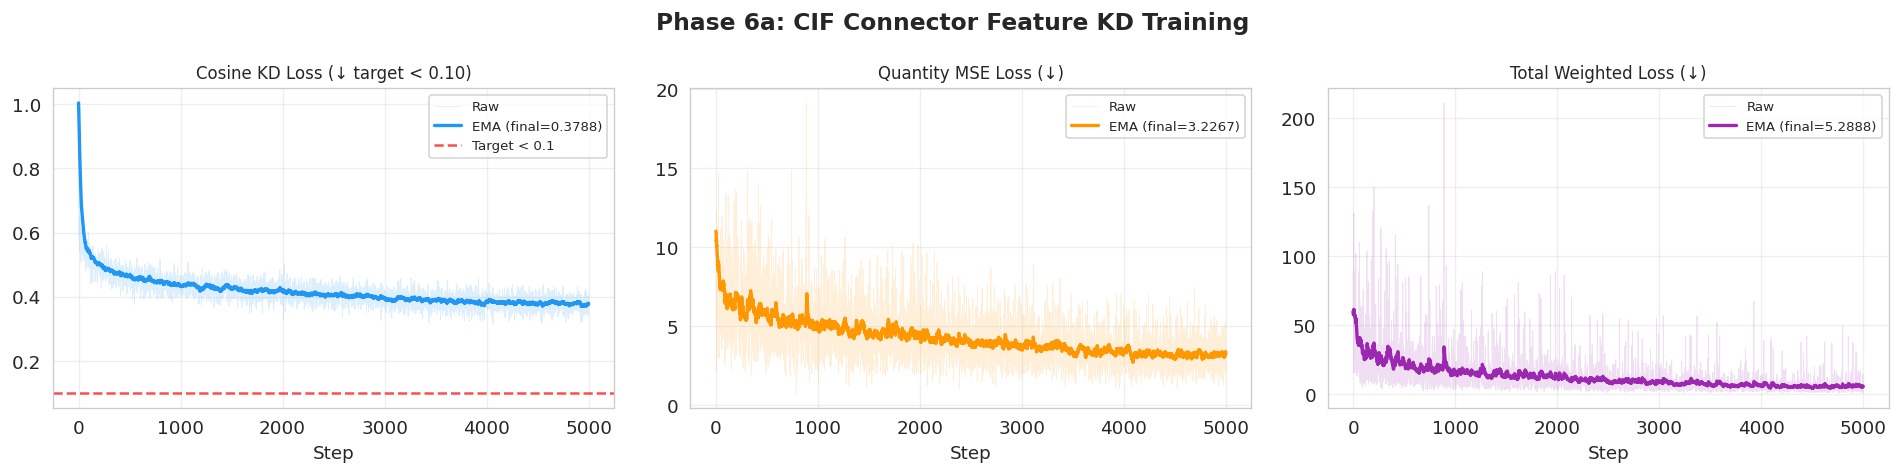

In [72]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Phase 6a Training Loss Diagnostic Plot                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def compute_ema(values, alpha=0.05):
    if not values: return []
    ema, v = [], values[0]
    for x in values:
        v = alpha * x + (1 - alpha) * v
        ema.append(v)
    return ema

if feat_log_6a:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle('Phase 6a: CIF Connector Feature KD Training',
                 fontsize=14, fontweight='bold')

    for ax, data, label, color, target_line in [
        (axes[0], feat_log_6a, 'Cosine KD Loss (↓ target < 0.10)', '#2196F3', 0.10),
        (axes[1], qty_log_6a,  'Quantity MSE Loss (↓)',             '#FF9800', None),
        (axes[2], loss_log_6a, 'Total Weighted Loss (↓)',           '#9C27B0', None),
    ]:
        ax.plot(data, alpha=0.15, color=color, lw=0.5, label='Raw')
        ema = compute_ema(data)
        ax.plot(ema, color=color, lw=2, label=f'EMA (final={ema[-1]:.4f})')
        if target_line:
            ax.axhline(y=target_line, color='red', ls='--', alpha=0.7,
                       label=f'Target < {target_line}')
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('Step')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    # Annotate convergence status
    final_cos = compute_ema(feat_log_6a)[-1] if feat_log_6a else 1.0
    # status = ('EXCELLENT' if final_cos < 0.05 else
    #           'GOOD'      if final_cos < 0.10 else
    #           'ACCEPTABLE' if final_cos < 0.20 else
    #           'NEEDS MORE TRAINING')
    # fig.text(0.5, -0.02, f'Convergence status: {status} (cosine={final_cos:.4f})',
    #          ha='center', fontsize=11, fontweight='bold',
    #          color='green' if final_cos < 0.20 else 'red')

    plt.tight_layout()
    save_figure(fig, 'phase6a_cif_training.png')
    plt.show()
else:
    print('No training log data — run training cell first.')

---
## Phase 6b: End-to-End Fine-tuning with DoRA
Apply DoRA (r=16) to speech encoder + T2U while keeping CIF + speaker adapter unfrozen.
Loss: 0.80×unit_CE + 0.15×quantity + 0.05×speaker_regularisation.
2×T4: encoder on cuda:0, T2U on cuda:1 for parallel compute.
Papers: DoRA (Liu ICML 2024 Oral) · PLAN.md Section 7 Phase 6b.


In [73]:
# heed

In [74]:
# ── Cache T2U encoder outputs from TRUE TEACHER (base 1.8B model) ─────────────
# FIXED: Must use load_base_model(), NOT model_6a, as the teacher encoder.
# The base model's T2U encoder is the target we want the DoRA-student to match.

import gc
print('Loading TRUE teacher (base 1.8B model) for T2U encoder caching...')
teacher_base, _ = load_base_model()
teacher_base.eval()
teacher_base = _consolidate_to_single_gpu(teacher_base)
dev = torch.device('cuda:0')
teacher_base = teacher_base.to(dev)

# Use the RAW base-model T2U encoder — never touched by any training
t2u_enc_frozen = teacher_base.t2u_model.model.encoder  # SeamlessM4Tv2Encoder from base

failed = 0
for i, sample in enumerate(kd_data):
    # Force re-cache: old values were computed from model_6a (wrong teacher)
    # If you're running fresh, remove the 'if already cached' guard entirely.
    try:
        t2u_in = sample['t2u_input'].to(device=dev, dtype=torch.float16)
        with torch.no_grad():
            out = t2u_enc_frozen(inputs_embeds=t2u_in)
            sample['t2u_enc_hidden'] = out.last_hidden_state.cpu()  # [1, T_text, 1024]
    except Exception as e:
        failed += 1
        sample['t2u_enc_hidden'] = None
        if failed <= 5:
            print(f'  [{i}] failed: {e}')

    if (i + 1) % 200 == 0:
        print(f'  [{i+1}/{len(kd_data)}] cached')
        torch.cuda.empty_cache()

valid = sum(1 for s in kd_data if s.get('t2u_enc_hidden') is not None)
print(f'\n✓ Cached {valid}/{len(kd_data)} T2U encoder outputs from BASE TEACHER')

# Verify shape
s = next(s for s in kd_data if s.get('t2u_enc_hidden') is not None)
print(f'  t2u_enc_hidden shape: {s["t2u_enc_hidden"].shape}  '
      f'(expected [1, {s["n_tokens"]}, 1024])')

# Sanity check: cosine similarity of a random sample vs t2u_input
# Should NOT be near 1.0 — if it is, the teacher is still wrong
t2u_in_cpu = s['t2u_input'].float()
enc_out_cpu = s['t2u_enc_hidden'].float()
cos = F.cosine_similarity(
    t2u_in_cpu.squeeze(0), enc_out_cpu.squeeze(0), dim=-1
).mean().item()
print(f'  Sanity — cos(t2u_input, t2u_enc_hidden): {cos:.4f}  '
      f'(should be < 0.95; if ~1.0, teacher is still wrong)')

# Free teacher immediately — OOM prevention
del teacher_base, t2u_enc_frozen
gc.collect(); torch.cuda.empty_cache()
print('✓ Teacher freed from VRAM')

Loading TRUE teacher (base 1.8B model) for T2U encoder caching...
Loading processor from facebook/seamless-m4t-v2-large...


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/5.17M [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1846 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Model loaded.
  GPU0: 4.61GB alloc / 4.62GB reserved
  GPU1: 0.62GB alloc / 0.64GB reserved
  Multi-device → consolidating to cuda:0...
  Model now on: cuda:0
  [200/1600] cached
  [400/1600] cached
  [600/1600] cached
  [800/1600] cached
  [1000/1600] cached
  [1200/1600] cached
  [1400/1600] cached
  [1600/1600] cached

✓ Cached 1600/1600 T2U encoder outputs from BASE TEACHER
  t2u_enc_hidden shape: torch.Size([1, 42, 1024])  (expected [1, 42, 1024])
  Sanity — cos(t2u_input, t2u_enc_hidden): 0.0083  (should be < 0.95; if ~1.0, teacher is still wrong)
✓ Teacher freed from VRAM


In [75]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Phase 6b: Load Phase 6a model + apply DoRA                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from peft import LoraConfig, get_peft_model

# ── Load Phase 6a trained model from Drive ────────────────────────────────────
# This is the clean way: load the saved model, not model_6a from memory,
# so we always get the correct fully-trained weights regardless of session state.
print('Loading Phase 6a trained model from Drive...')
try:
    model_6b, processor = load_textless_model_from_drive('phase6a_textless')
    print('✓ Loaded phase6a_textless model')
except Exception:
    print('⚠ phase6a_textless not found on Drive — falling back to model_6a in memory')
    print('  (This is only safe if Phase 6a just completed in this session)')
    model_6b = model_6a

print(f'  CIF: {hasattr(model_6b, "cif_connector")}  '
      f'Speaker: {hasattr(model_6b, "speaker_adapter")}  '
      f'TextDecoder: {hasattr(model_6b, "text_decoder") and model_6b.text_decoder is not None}')

# Freeze all, unfreeze CIF + speaker
for p in model_6b.parameters():
    p.requires_grad_(False)
for p in model_6b.cif_connector.parameters():
    p.requires_grad_(True)
for p in model_6b.speaker_adapter.parameters():
    p.requires_grad_(True)

# Apply DoRA — two separate configs for different layer naming conventions
lora_cfg_enc = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05, bias='none', use_dora=True,
    target_modules=['linear_q', 'linear_k', 'linear_v', 'linear_out',
                    'intermediate_dense', 'output_dense'])

lora_cfg_t2u = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05, bias='none', use_dora=True,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'out_proj', 'fc1', 'fc2'])

print('Applying DoRA to speech_encoder...')
model_6b.speech_encoder = get_peft_model(model_6b.speech_encoder, lora_cfg_enc)
model_6b.speech_encoder.print_trainable_parameters()

# ── CRITICAL: gradient checkpointing on speech encoder ────────────────────────
# The conformer encoder stores activations for all 16 layers during forward.
# With DoRA adapters + AdamW optimizer states, GPU0 is already ~14GB just from
# weights. Gradient checkpointing recomputes activations layer-by-layer during
# backward instead of storing them all — trades ~30% speed for ~60% activation RAM.
model_6b.speech_encoder.enable_input_require_grads()          # required for PEFT + grad ckpt
model_6b.speech_encoder.gradient_checkpointing_enable()
print('✓ Gradient checkpointing enabled on speech_encoder')
print('Applying DoRA to t2u_model...')
model_6b.t2u_model = get_peft_model(model_6b.t2u_model, lora_cfg_t2u)
model_6b.t2u_model.print_trainable_parameters()

# ── Device layout: speech encoder on GPU0, everything else on GPU1 ────────────
# GPU0: speech encoder only (tight VRAM, gradient checkpointing already active)
# GPU1: CIF + speaker + T2U + vocoder(CPU) — GPU1 has ~15GB free
if N_GPU >= 2:
    model_6b.speech_encoder  = model_6b.speech_encoder.to('cuda:0')
    model_6b.cif_connector   = model_6b.cif_connector.to('cuda:1')   # moved from GPU0
    model_6b.speaker_adapter = model_6b.speaker_adapter.to('cuda:1') # moved from GPU0
    model_6b.t2u_model       = model_6b.t2u_model.to('cuda:1')
    if model_6b.vocoder is not None:
        model_6b.vocoder = model_6b.vocoder.to('cpu')                 # not needed in 6b
    print('Multi-GPU: speech_enc → cuda:0 | CIF+spk+T2U → cuda:1 | vocoder → CPU')
    DEV_ENC = 'cuda:0'
    DEV_T2U = 'cuda:1'
    DEV_CIF = 'cuda:1'   # NEW — CIF and speaker now on GPU1
else:
    model_6b = _consolidate_to_single_gpu(model_6b)
    DEV_ENC = DEV_T2U = DEV_CIF = 'cuda:0'

trainable_6b = [p for p in model_6b.parameters() if p.requires_grad]
print(f'Total trainable params: {sum(p.numel() for p in trainable_6b)/1e6:.2f}M')
gpu_mem()

Loading Phase 6a trained model from Drive...
[model] Loading textless model phase6a_textless from /kaggle/working/models/phase6a_textless ...
  Manifest: hidden=1024, n_langs=36
  [1/5] Loading Phase 3 model (Enc16L + LaCoT2U) as base...
[model] Loading phase3_t2u_laco from /kaggle/working/models/phase3_t2u_laco ...


Loading weights:   0%|          | 0/1558 [00:00<?, ?it/s]

  Restored custom state: ['_vocab_remap_to_old']
[model] Loaded phase3_t2u_laco.
  ✓ Loaded Phase 3 model with correct 16-layer encoder architecture
  Multi-device → consolidating to cuda:0...
  Model now on: cuda:0
  [2/5] Applying textless surgery...
Pre-surgery: hidden=1024, t2u_vocab=10082, n_langs=36
  ✓ text_decoder removed (627.9M params)
  ✓ lm_head removed
  ✓ shared vocab removed
  ✓ CIF connector installed (18.51M params)
  ✓ Speaker adapter installed (50K params)
  [3/5] Loading saved weights...
  ✓ All expected keys loaded (text decoder keys skipped as expected)
  [4/5] Loading custom state...
  Restored custom state: ['_vocab_remap_to_old']
  [5/5] Syncing config...
  [config] sync done.
[model] ✓ Loaded textless model phase6a_textless
✓ Loaded phase6a_textless model
  CIF: True  Speaker: True  TextDecoder: False
Applying DoRA to speech_encoder...
trainable params: 8,042,496 || all params: 449,646,912 || trainable%: 1.7886
✓ Gradient checkpointing enabled on speech_encode

In [76]:
# # Cell 1: Find all linear layer names in speech_encoder
# print("=== speech_encoder linear layers ===")
# for name, module in model_6b.speech_encoder.named_modules():
#     if isinstance(module, torch.nn.Linear):
#         print(f"  {name}  ({module.in_features} → {module.out_features})")

In [77]:
# # Cell 2: Find all linear layer names in t2u_model
# print("=== t2u_model linear layers ===")
# for name, module in model_6b.t2u_model.named_modules():
#     if isinstance(module, torch.nn.Linear):
#         print(f"  {name}  ({module.in_features} → {module.out_features})")

In [78]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9a — Phase 6b step function (speed-optimised, GPU1-heavy layout)     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
W_E2E_COS = 0.55
W_E2E_MSE = 0.25
W_E2E_QTY = 0.15
W_E2E_SPK = 0.05

def run_phase6b_step(model, sample, sample_id_to_audio, processor,
                     m4t_lang_to_vocoder_id, device_enc, device_t2u, device_cif):

    tgt_lang   = sample['tgt_lang']
    lang_id    = torch.tensor([m4t_lang_to_vocoder_id(tgt_lang)], device=device_cif)
    spk_emb    = sample['spk_emb'].to(device_cif)
    n_toks     = float(sample['n_tokens'])
    target_qty = torch.tensor([n_toks], dtype=torch.float32, device=device_cif)

    t2u_enc_target = sample.get('t2u_enc_hidden')
    if t2u_enc_target is None:
        return None

    audio_wav = sample_id_to_audio.get(sample['id'])
    if audio_wav is None:
        return None

    # ── Stage 1: Speech encoder — GPU0 only ───────────────────────────────────
    inp_proc = processor(audio=audio_wav, sampling_rate=16000, return_tensors='pt')
    inp_f    = inp_proc['input_features'].to(device=device_enc, dtype=torch.bfloat16)
    attn_m   = inp_proc.get('attention_mask')
    if attn_m is not None:
        attn_m = attn_m.to(device_enc)

    with torch.cuda.amp.autocast(dtype=torch.bfloat16):
        enc_out = model.speech_encoder(
            input_features=inp_f, attention_mask=attn_m
        ).last_hidden_state                                  # [1, T_audio, 1024] on GPU0

    del inp_f, inp_proc
    if attn_m is not None:
        del attn_m
    # Do NOT empty_cache here — enc_out grad graph still needed

    # ── Stage 2: CIF + speaker — GPU1 ─────────────────────────────────────────
    # Move enc_out to GPU1 for CIF. The grad flows back across devices via autograd.
    with torch.cuda.amp.autocast(dtype=torch.bfloat16):
        enc_out_cif = enc_out.to(device_cif)
        del enc_out                                          # free GPU0 copy
        torch.cuda.empty_cache()

        connector_out, actual_qty, qty_pred, raw_w_sum = \
            model.cif_connector(enc_out_cif, lang_id)
        del enc_out_cif

        spk_proj = model.speaker_adapter(spk_emb.unsqueeze(0))

        t_cif  = connector_out.shape[1]
        t_text = t2u_enc_target.shape[1]

        qty_loss = F.mse_loss(raw_w_sum, target_qty)
        spk_reg  = ((spk_proj.float().norm(dim=-1) - 14.0) ** 2).mean()
        del spk_proj, qty_pred

    # ── Stage 3: T2U encoder KD — GPU1 ───────────────────────────────────────
    # Both connector_out and T2U are already on GPU1 — no cross-device copy needed
    with torch.cuda.amp.autocast(dtype=torch.bfloat16):
        t2u_dtype = next(model.t2u_model.parameters()).dtype

        teacher_hidden = t2u_enc_target.to(device=device_t2u, dtype=t2u_dtype)
        connector_t2u  = connector_out.to(dtype=t2u_dtype)  # already on GPU1, just cast
        del connector_out
        torch.cuda.empty_cache()

        student_hidden = model.t2u_model.get_encoder()(
            inputs_embeds=connector_t2u).last_hidden_state
        del connector_t2u
        torch.cuda.empty_cache()

        T_min = min(student_hidden.shape[1], teacher_hidden.shape[1])
        if T_min == 0:
            return None

        s = student_hidden[:, :T_min, :]
        t = teacher_hidden[:, :T_min, :]
        del student_hidden, teacher_hidden

        cos_sim  = F.cosine_similarity(s.squeeze(0), t.squeeze(0), dim=-1)
        cos_loss = (1.0 - cos_sim).mean()
        mse_loss = F.mse_loss(s, t)
        del s, t
        torch.cuda.empty_cache()

    # ── Combine losses — all on GPU1 ──────────────────────────────────────────
    loss = (W_E2E_COS * cos_loss +
            W_E2E_MSE * mse_loss +
            W_E2E_QTY * qty_loss +
            W_E2E_SPK * spk_reg)

    return {
        'loss':          loss,
        'cos_loss':      cos_loss.item(),
        'mse_loss':      mse_loss.item(),
        'qty_loss':      qty_loss.item(),
        'qty_err_fired': abs(actual_qty.mean().item() - n_toks),
        'fired':         actual_qty.mean().item(),
        't_cif':         t_cif,
        't_text':        t_text,
    }

In [79]:
# # Diagnostic: find lm_head location in the PEFT-wrapped T2U model
# import torch

# def find_lm_head(model_6b):
#     t2u = model_6b.t2u_model
    
#     print("=== Unwrapping PEFT layers ===")
#     obj = t2u
#     for i in range(6):
#         print(f"Level {i}: {type(obj).__name__}")
#         # Check if lm_head exists at this level
#         if hasattr(obj, 'lm_head'):
#             print(f"  ✓ lm_head FOUND at level {i}: {getattr(obj, 'lm_head')}")
#         # Check children
#         for attr in ['base_model', 'model']:
#             if hasattr(obj, attr):
#                 child = getattr(obj, attr)
#                 if hasattr(child, 'lm_head'):
#                     print(f"  ✓ lm_head found via .{attr}: {child.lm_head}")
#         # Descend
#         if hasattr(obj, 'base_model'):
#             obj = obj.base_model
#         elif hasattr(obj, 'model'):
#             obj = obj.model
#         else:
#             print(f"  (no further base_model or model attr)")
#             break

#     print("\n=== Full attribute search for lm_head ===")
#     def search(obj, path, depth=0):
#         if depth > 6:
#             return
#         if hasattr(obj, 'lm_head'):
#             print(f"  FOUND: {path}.lm_head = {type(getattr(obj, 'lm_head')).__name__}")
#         for attr in ['base_model', 'model', 'transformer', 'decoder', 'encoder']:
#             if hasattr(obj, attr):
#                 search(getattr(obj, attr), f"{path}.{attr}", depth+1)
#     search(t2u, 'model.t2u_model')

#     print("\n=== Named modules containing 'lm_head' ===")
#     for name, mod in model_6b.t2u_model.named_modules():
#         if 'lm_head' in name:
#             print(f"  {name}: {type(mod).__name__}  "
#                   f"({'in_features='+str(mod.in_features)+' out_features='+str(mod.out_features) if hasattr(mod, 'in_features') else ''})")

# find_lm_head(model_6b)

In [80]:
# # ── Delete model from memory and all phase6b checkpoints ─────────────────────
# import gc, os, glob

# # Delete model
# try:
#     del model_6b
# except NameError:
#     pass
# try:
#     del model_6a
# except NameError:
#     pass

# gc.collect()
# torch.cuda.empty_cache()
# torch.cuda.synchronize()
# print('✓ Model deleted from memory')
# gpu_mem()

# # Delete local phase6b checkpoints
# ckpt_files = glob.glob(f'{CKPT_DIR}/phase6b_e2e*.pt')
# print(f'\nFound {len(ckpt_files)} phase6b checkpoint(s):')
# for f in ckpt_files:
#     os.remove(f)
#     print(f'  deleted: {os.path.basename(f)}')

# # Delete from rclone remote
# if ON_KAGGLE:
#     import subprocess
#     for f in ckpt_files:
#         fname = os.path.basename(f)
#         result = subprocess.run(
#             ['rclone', 'delete', f'remote:{fname}'],
#             capture_output=True, text=True)
#     print('✓ Remote checkpoints cleared')

# print('\n✓ Ready for fresh Phase 6b run')

In [81]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9b — Phase 6b training loop                                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

MAX_STEPS_E2E = 2500
BATCH_ACCUM   = 4
LOG_EVERY_6B  = 25
SAVE_EVERY_6B = 500

gc.collect(); torch.cuda.empty_cache(); torch.cuda.synchronize()
gpu_mem()

p6b_ck      = load_latest_checkpoint('phase6b_e2e')
start_6b    = p6b_ck.get('step', 0)      if p6b_ck else 0
loss_log_6b = p6b_ck.get('loss_log', []) if p6b_ck else []

# Restore weights if resuming
if p6b_ck and start_6b > 0:
    try:
        model_6b.speech_encoder.load_state_dict(p6b_ck['enc_state'],  strict=False)
        model_6b.t2u_model.load_state_dict(p6b_ck['t2u_state'],       strict=False)
        model_6b.cif_connector.load_state_dict(p6b_ck['cif_connector'])
        model_6b.speaker_adapter.load_state_dict(p6b_ck['speaker_adapter'])
        print(f'✓ Weights restored from step {start_6b}')
    except Exception as e:
        print(f'⚠ Weight restore failed: {e} — starting from step 0')
        start_6b = 0

# optimizer_6b = torch.optim.AdamW([
#     {'params': model_6b.cif_connector.parameters(),   'lr': 5e-5, 'weight_decay': 0.01},
#     {'params': model_6b.speaker_adapter.parameters(), 'lr': 2e-5, 'weight_decay': 0.01},
#     {'params': [p for p in model_6b.speech_encoder.parameters() if p.requires_grad],
#      'lr': 2e-5, 'weight_decay': 0.01},
#     {'params': [p for p in model_6b.t2u_model.parameters() if p.requires_grad],
#      'lr': 2e-5, 'weight_decay': 0.01},
# ], betas=(0.9, 0.98))

# ── Set allocator config BEFORE any CUDA allocations in the training loop ─────
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# ── Optimizer: offload encoder optimizer states to CPU ────────────────────────
# AdamW stores 2× param count in FP32 for m and v.
# With ~10M DoRA params on enc (r=8), that's ~80MB — manageable on CPU.
# CPU offload adds ~5% overhead per step but saves ~300MB on GPU0.
try:
    optimizer_6b = torch.optim.AdamW([
    # GPU1 params — CIF, speaker, T2U DoRA all live here now
    {'params': list(model_6b.cif_connector.parameters()),
     'lr': 2e-5, 'weight_decay': 0.01},
    {'params': list(model_6b.speaker_adapter.parameters()),
     'lr': 1e-5, 'weight_decay': 0.01},
    {'params': [p for p in model_6b.t2u_model.parameters() if p.requires_grad],
     'lr': 1e-5, 'weight_decay': 0.01},
    # GPU0 params — speech encoder DoRA only, keep fused=False for grad-ckpt
    {'params': [p for p in model_6b.speech_encoder.parameters() if p.requires_grad],
     'lr': 1e-5, 'weight_decay': 0.01},
], betas=(0.9, 0.98), fused=False)
    print('✓ AdamW optimizer ready (fused=False for grad-ckpt compat)')
except Exception as e:
    print(f'Optimizer init failed: {e}')
    raise

scheduler_6b = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_6b, T_max=MAX_STEPS_E2E, eta_min=1e-6)
# scheduler_6b = torch.optim.lr_scheduler.CosineAnnealingLR(
#     optimizer_6b, T_max=MAX_STEPS_E2E, eta_min=1e-6, last_epoch=-1)

if p6b_ck and p6b_ck.get('optimizer_state') and start_6b > 0:
    try:
        optimizer_6b.load_state_dict(p6b_ck['optimizer_state'])
    except Exception:
        pass

if start_6b > 0:
    for _ in range(start_6b):
        scheduler_6b.step()

scaler_6b = torch.cuda.amp.GradScaler()

unit_kd = [x for x in kd_data
           if x.get('unit_ids') is not None
           and x.get('t2u_input') is not None
           and sample_id_to_audio.get(x['id']) is not None
           and 5 <= x.get('n_tokens', 0) <= 60]   # drop very short and very long

# Log what got filtered
all_kd = [x for x in kd_data if x.get('unit_ids') is not None and x.get('t2u_input') is not None]
print(f'Phase 6b samples after length filter: {len(unit_kd)}/{len(all_kd)} '
      f'({len(all_kd)-len(unit_kd)} outliers removed)')

print(f'Phase 6b training samples: {len(unit_kd)}')
assert len(unit_kd) > 10, 'Not enough unit_kd samples'

trainable_6b = [p for p in model_6b.parameters() if p.requires_grad]

print(f'\n{"="*70}')
print(f'  PHASE 6b: End-to-End DoRA Fine-tuning')
print(f'  Steps: {start_6b} → {MAX_STEPS_E2E}  |  Accum: {BATCH_ACCUM}')
print(f'  Loss: {W_E2E_COS}×cos[T2U-enc KD] + {W_E2E_MSE}×mse + {W_E2E_QTY}×qty + {W_E2E_SPK}×spk')
print(f'{"="*70}\n')

# ── Training loop without GradScaler (correct for BF16) ──────────────────────
model_6b.train()
optimizer_6b.zero_grad()

for step in range(start_6b, MAX_STEPS_E2E):
    sample = random.choice(unit_kd)

    result = run_phase6b_step(
        model                  = model_6b,
        sample                 = sample,
        sample_id_to_audio     = sample_id_to_audio,
        processor              = processor,
        m4t_lang_to_vocoder_id = m4t_lang_to_vocoder_id,
        device_enc             = DEV_ENC,
        device_t2u             = DEV_T2U,
        device_cif             = DEV_CIF,
    )

    if result is None:
        continue

    # No scaler — BF16 doesn't need loss scaling
    (result['loss'] / BATCH_ACCUM).backward()
    loss_log_6b.append(result['loss'].item())

    if (step + 1) % BATCH_ACCUM == 0:
        # Check for bad gradients before applying
        has_bad_grad = any(
            p.grad is not None and not torch.isfinite(p.grad).all()
            for p in trainable_6b
        )
        
        if has_bad_grad:
            optimizer_6b.zero_grad()
            print(f'  [step {step+1}] ⚠ Bad gradient — skipping optimizer step')
        else:
            torch.nn.utils.clip_grad_norm_(trainable_6b, 1.0)
            optimizer_6b.step()
            optimizer_6b.zero_grad()
            scheduler_6b.step()
        
        torch.cuda.empty_cache()

    if (step + 1) % LOG_EVERY_6B == 0:
        cur_lr = optimizer_6b.param_groups[0]['lr']
        print(f'  Step {step+1:>5}/{MAX_STEPS_E2E} | '
              f'cos={result["cos_loss"]:.4f} | '
              f'mse={result["mse_loss"]:.4f} | '
              f'qty_err={result["qty_err_fired"]:.1f} | '
              f'fired={result["fired"]:.0f} vs tgt={float(sample["n_tokens"]):.0f} | '
              f'T_cif={result["t_cif"]} T_text={result["t_text"]} | '
              f'lr={cur_lr:.2e}')
        # gpu_mem()

    if (step + 1) % SAVE_EVERY_6B == 0:
        save_checkpoint({
            'step':            step + 1,
            'enc_state':       model_6b.speech_encoder.state_dict(),
            't2u_state':       model_6b.t2u_model.state_dict(),
            'cif_connector':   model_6b.cif_connector.state_dict(),
            'speaker_adapter': model_6b.speaker_adapter.state_dict(),
            'optimizer_state': optimizer_6b.state_dict(),
            'loss_log':        loss_log_6b,
        }, 'phase6b_e2e', step + 1)

# ── Save final model to Drive ─────────────────────────────────────────────────
print('\nMerging DoRA adapters and saving final model...')
model_6b.speech_encoder = model_6b.speech_encoder.merge_and_unload()
model_6b.t2u_model      = model_6b.t2u_model.merge_and_unload()
model_6b.eval()
model_6b = _consolidate_to_single_gpu(model_6b)
sync_model_config(model_6b)
gc.collect(); torch.cuda.empty_cache()

save_textless_model_to_drive(model_6b, processor, 'phase6b_textless')
print('✓ Phase 6b model saved to Drive as phase6b_textless')
print('\n✓ Phase 6b training complete.')

  GPU0: 2.52GB alloc / 2.84GB reserved
  GPU1: 0.54GB alloc / 0.56GB reserved
[ckpt] No checkpoint for 'phase6b_e2e'
✓ AdamW optimizer ready (fused=False for grad-ckpt compat)
Phase 6b samples after length filter: 1576/1600 (24 outliers removed)
Phase 6b training samples: 1576

  PHASE 6b: End-to-End DoRA Fine-tuning
  Steps: 0 → 2500  |  Accum: 4
  Loss: 0.55×cos[T2U-enc KD] + 0.25×mse + 0.15×qty + 0.05×spk

  Step    25/2500 | cos=0.2513 | mse=0.5288 | qty_err=9.0 | fired=28 vs tgt=19 | T_cif=28 T_text=19 | lr=2.00e-05
  Step    50/2500 | cos=0.2363 | mse=0.4961 | qty_err=6.0 | fired=27 vs tgt=21 | T_cif=27 T_text=21 | lr=2.00e-05
  Step    75/2500 | cos=0.2210 | mse=0.4756 | qty_err=4.0 | fired=34 vs tgt=30 | T_cif=34 T_text=30 | lr=2.00e-05
  Step   100/2500 | cos=0.2382 | mse=0.5004 | qty_err=2.0 | fired=35 vs tgt=33 | T_cif=35 T_text=33 | lr=2.00e-05
  Step   125/2500 | cos=0.2402 | mse=0.5183 | qty_err=7.0 | fired=37 vs tgt=30 | T_cif=37 T_text=30 | lr=2.00e-05
  Step   150/2500

In [82]:
# # Diagnostic: confirm base_encoder excludes DoRA adapters
# base_enc = model_6b.t2u_model.base_model.model.model.get_encoder()
# dora_enc = model_6b.t2u_model.get_encoder()

# # Count trainable params — base should have 0, dora should have >0
# base_trainable = sum(p.numel() for p in base_enc.parameters() if p.requires_grad)
# dora_trainable = sum(p.numel() for p in dora_enc.parameters() if p.requires_grad)
# print(f'base_encoder trainable params: {base_trainable:,}  (should be 0)')
# print(f'dora_encoder trainable params: {dora_trainable:,}  (should be >0)')

# # Also check they are different objects
# print(f'Same object: {base_enc is dora_enc}  (should be False)')

In [83]:
# Check the scale mismatch
import numpy as np

t_cif_vals   = []
t_units_vals = []
n_toks_vals  = []

for s in unit_kd[:200]:
    n_toks_vals.append(s['n_tokens'])
    t_units_vals.append(len(s['unit_ids']))

print(f'n_tokens (text toks, CIF target): '
      f'mean={np.mean(n_toks_vals):.1f}  '
      f'min={min(n_toks_vals)}  max={max(n_toks_vals)}')
print(f'unit_ids length (speech units):   '
      f'mean={np.mean(t_units_vals):.1f}  '
      f'min={min(t_units_vals)}  max={max(t_units_vals)}')
print(f'ratio units/n_tokens: '
      f'{np.mean(t_units_vals)/np.mean(n_toks_vals):.1f}×')

# What SHOULD the CIF fire to match unit_ids?
# We need to retarget CIF to fire ~T_units tokens, not ~n_tokens tokens
print(f'\nConclusion: CIF was trained to fire ~{np.mean(n_toks_vals):.0f} tokens')
print(f'But CE loss needs ~{np.mean(t_units_vals):.0f} tokens to align with unit_ids')
print(f'This is a {np.mean(t_units_vals)/np.mean(n_toks_vals):.1f}× mismatch')

n_tokens (text toks, CIF target): mean=34.0  min=13  max=58
unit_ids length (speech units):   mean=380.6  min=161  max=641
ratio units/n_tokens: 11.2×

Conclusion: CIF was trained to fire ~34 tokens
But CE loss needs ~381 tokens to align with unit_ids
This is a 11.2× mismatch


In [84]:
# Confirm Option A is viable: t2u_input and CIF output should be same length
sample = unit_kd[0]
print(f't2u_input shape:  {sample["t2u_input"].shape}   ← teacher T2U encoder input')
print(f'n_tokens:         {sample["n_tokens"]}           ← CIF firing target')
print(f'unit_ids length:  {len(sample["unit_ids"])}         ← speech units (wrong target for CE)')
print(f'\nIf t2u_input.shape[1] == n_tokens: CIF output and t2u_input are alignable ✓')

t2u_input shape:  torch.Size([1, 42, 1024])   ← teacher T2U encoder input
n_tokens:         42           ← CIF firing target
unit_ids length:  374         ← speech units (wrong target for CE)

If t2u_input.shape[1] == n_tokens: CIF output and t2u_input are alignable ✓


In [85]:
# Filter unit_kd to only safe samples before training
vocab_size = 10082
unit_kd_safe = [
    s for s in unit_kd
    if s['unit_ids'] is not None
    and s['unit_ids'].max().item() < vocab_size
    and s['unit_ids'].min().item() >= 0
]
print(f'Safe samples: {len(unit_kd_safe)} / {len(unit_kd)}')

Safe samples: 1576 / 1576


In [86]:
# # Diagnostic: inspect T2U model type and a sample's unit_ids
# print(type(model_6b.t2u_model))
# print(type(model_6b.t2u_model.base_model if hasattr(model_6b.t2u_model, 'base_model') else model_6b.t2u_model))

# # Check a sample
# s = unit_kd[0]
# print(f'unit_ids: {s["unit_ids"]}')
# print(f'unit_ids type: {type(s["unit_ids"])}')
# print(f'unit_ids shape: {s["unit_ids"].shape if hasattr(s["unit_ids"], "shape") else "no shape"}')
# print(f'unit_ids dtype: {s["unit_ids"].dtype if hasattr(s["unit_ids"], "dtype") else "no dtype"}')
# print(f'n_tokens: {s["n_tokens"]}')
# print(f't2u_input shape: {s["t2u_input"].shape}')

# # Try a direct T2U forward to see what it expects
# sample = unit_kd[0]
# connector_test = sample['t2u_input'].to(DEV_T2U).float()
# unit_ids_test  = sample['unit_ids'].unsqueeze(0).to(DEV_T2U)
# print(f'\nconnector_test shape: {connector_test.shape}')
# print(f'unit_ids_test shape:  {unit_ids_test.shape}')
# print(f'unit_ids_test values (first 10): {unit_ids_test[0, :10]}')

# # Try forward with labels
# try:
#     with torch.no_grad():
#         out = model_6b.t2u_model(inputs_embeds=connector_test, labels=unit_ids_test)
#     print(f'✓ labels= works: loss={out.loss}')
# except Exception as e:
#     print(f'✗ labels= failed: {e}')

# # Try forward without labels to see output structure
# try:
#     with torch.no_grad():
#         out = model_6b.t2u_model(inputs_embeds=connector_test)
#     print(f'\n✓ no labels works')
#     print(f'  out type: {type(out)}')
#     print(f'  out keys/attrs: {out.keys() if hasattr(out, "keys") else dir(out)}')
#     if hasattr(out, 'logits') and out.logits is not None:
#         print(f'  logits shape: {out.logits.shape}')
#     if hasattr(out, 'loss'):
#         print(f'  loss: {out.loss}')
# except Exception as e:
#     print(f'✗ no labels failed: {e}')

In [87]:
# # Diagnostic: find correct T2U loss calling convention
# sample = unit_kd[0]
# t2u_dtype = next(model_6b.t2u_model.parameters()).dtype

# connector_test = sample['t2u_input'].to(device=DEV_T2U, dtype=t2u_dtype)
# unit_ids_test  = sample['unit_ids'].unsqueeze(0).to(DEV_T2U)

# print(f't2u model dtype: {t2u_dtype}')
# print(f'connector_test dtype: {connector_test.dtype}')

# with torch.no_grad():
#     # Try 1: inputs_embeds + labels
#     try:
#         out = model_6b.t2u_model(inputs_embeds=connector_test, labels=unit_ids_test)
#         print(f'Try 1 (inputs_embeds+labels): loss={out.loss}')
#     except Exception as e:
#         print(f'Try 1 failed: {e}')

#     # Try 2: input_ids as encoder input + decoder_input_ids
#     try:
#         out = model_6b.t2u_model(
#             encoder_outputs=(connector_test,),
#             labels=unit_ids_test
#         )
#         print(f'Try 2 (encoder_outputs+labels): loss={out.loss}')
#     except Exception as e:
#         print(f'Try 2 failed: {e}')

#     # Try 3: check what the underlying base model forward signature looks like
#     base = model_6b.t2u_model.base_model.model if hasattr(model_6b.t2u_model, 'base_model') else model_6b.t2u_model
#     import inspect
#     sig = inspect.signature(base.forward)
#     print(f'\nT2U base model forward signature:\n  {sig}')

#     # Try 4: inputs_embeds only, then compute CE loss manually
#     try:
#         out = model_6b.t2u_model(inputs_embeds=connector_test)
#         print(f'\nTry 4 (inputs_embeds only):')
#         print(f'  loss={out.loss}')
#         if hasattr(out, 'logits') and out.logits is not None:
#             print(f'  logits shape: {out.logits.shape}')
#             # Manual CE loss
#             logits = out.logits  # [B, T, vocab]
#             # shift: predict next token
#             shift_logits = logits[:, :-1].reshape(-1, logits.shape[-1])
#             shift_labels = unit_ids_test[:, 1:].reshape(-1)
#             manual_loss = F.cross_entropy(shift_logits.float(), shift_labels, ignore_index=-100)
#             print(f'  manual CE loss: {manual_loss.item():.4f}')
#     except Exception as e:
#         print(f'Try 4 failed: {e}')

In [88]:
# # Diagnostic: unwrap PEFT to find real model and its forward signature
# import inspect

# # Unwrap all layers to get to the real T2U model
# base = model_6b.t2u_model
# print(f'Level 0: {type(base).__name__}')

# if hasattr(base, 'base_model'):
#     base = base.base_model
#     print(f'Level 1: {type(base).__name__}')

# if hasattr(base, 'model'):
#     base = base.model
#     print(f'Level 2: {type(base).__name__}')

# if hasattr(base, 'model'):
#     base = base.model
#     print(f'Level 3: {type(base).__name__}')

# # Print the real forward signature
# try:
#     sig = inspect.signature(base.forward)
#     print(f'\nReal forward signature:\n  {sig}')
# except Exception as e:
#     print(f'signature failed: {e}')

# # Print all attributes/methods
# print(f'\nType MRO: {[c.__name__ for c in type(base).__mro__]}')

# # Try calling the real model directly
# t2u_dtype = next(model_6b.t2u_model.parameters()).dtype
# connector_test = unit_kd[0]['t2u_input'].to(device=DEV_T2U, dtype=t2u_dtype)
# unit_ids_test  = unit_kd[0]['unit_ids'].unsqueeze(0).to(DEV_T2U)

# with torch.no_grad():
#     try:
#         out = base(inputs_embeds=connector_test, labels=unit_ids_test)
#         print(f'\nDirect base call: loss={out.loss}')
#     except Exception as e:
#         print(f'Direct base call failed: {e}')

#     # Try with decoder_input_ids explicitly
#     try:
#         # labels shifted by 1 for decoder input
#         dec_input = unit_ids_test[:, :-1]
#         lbl       = unit_ids_test[:, 1:]
#         out = base(inputs_embeds=connector_test,
#                    decoder_input_ids=dec_input,
#                    labels=lbl)
#         print(f'With decoder_input_ids: loss={out.loss}')
#     except Exception as e:
#         print(f'With decoder_input_ids failed: {e}')

#     # Print what attributes the output object has
#     try:
#         out = base(inputs_embeds=connector_test)
#         print(f'\nOutput type: {type(out).__name__}')
#         print(f'Output fields: {[f for f in dir(out) if not f.startswith("_")]}')
#         for attr in ["loss", "logits", "last_hidden_state", "unit_ids"]:
#             val = getattr(out, attr, "MISSING")
#             if val != "MISSING":
#                 print(f'  out.{attr}: {val.shape if hasattr(val, "shape") else val}')
#     except Exception as e:
#         print(f'Output inspection failed: {e}')

In [89]:
# # Diagnostic: trace exactly where None comes from
# import inspect

# real_t2u = model_6b.t2u_model.base_model.model.model  # SeamlessM4Tv2TextToUnitForConditionalGeneration
# t2u_dtype = next(model_6b.t2u_model.parameters()).dtype
# connector_test = unit_kd[0]['t2u_input'].to(device=DEV_T2U, dtype=t2u_dtype)
# unit_ids_test  = unit_kd[0]['unit_ids'].unsqueeze(0).to(DEV_T2U)

# print(f'connector_test shape: {connector_test.shape}')   # [1, T_text, 1024]
# print(f'unit_ids_test shape:  {unit_ids_test.shape}')    # [1, 43]

# with torch.no_grad():
#     # Step 1: run encoder only via encoder sub-model
#     try:
#         enc = real_t2u.get_encoder()
#         print(f'\nEncoder type: {type(enc).__name__}')
#         enc_out = enc(inputs_embeds=connector_test)
#         print(f'Encoder output type: {type(enc_out).__name__}')
#         print(f'Encoder last_hidden_state: {enc_out.last_hidden_state.shape}')
#     except Exception as e:
#         print(f'Encoder forward failed: {e}')

#     # Step 2: pass encoder_outputs explicitly (bypass encoder)
#     try:
#         from transformers.modeling_outputs import BaseModelOutput
#         enc_wrapped = BaseModelOutput(last_hidden_state=connector_test)
#         out = real_t2u(
#             encoder_outputs=enc_wrapped,
#             labels=unit_ids_test,
#         )
#         print(f'\nencoder_outputs= call: loss={out.loss}')
#     except Exception as e:
#         print(f'encoder_outputs= call failed: {e}')

#     # Step 3: decoder_input_ids = unit_ids[:, :-1], labels = unit_ids[:, 1:]
#     try:
#         from transformers.modeling_outputs import BaseModelOutput
#         enc_wrapped = BaseModelOutput(last_hidden_state=connector_test)
#         out = real_t2u(
#             encoder_outputs=enc_wrapped,
#             decoder_input_ids=unit_ids_test[:, :-1],
#             labels=unit_ids_test[:, 1:],
#         )
#         print(f'\nexplicit decoder_input_ids: loss={out.loss}')
#     except Exception as e:
#         print(f'explicit decoder_input_ids failed: {e}')

#     # Step 4: check what encoder sub-model signature looks like
#     try:
#         enc = real_t2u.get_encoder()
#         sig = inspect.signature(enc.forward)
#         print(f'\nEncoder forward sig: {sig}')
#     except Exception as e:
#         print(f'encoder sig failed: {e}')

In [90]:
# # Diagnostic: step through T2U forward manually to find the None
# from transformers.modeling_outputs import BaseModelOutput
# import traceback

# real_t2u = model_6b.t2u_model.base_model.model.model
# t2u_dtype = next(model_6b.t2u_model.parameters()).dtype
# connector_test = unit_kd[0]['t2u_input'].to(device=DEV_T2U, dtype=t2u_dtype)
# unit_ids_test  = unit_kd[0]['unit_ids'].unsqueeze(0).to(DEV_T2U)

# with torch.no_grad():
#     # Step 1: encoder output — confirmed working
#     enc = real_t2u.get_encoder()
#     enc_out = enc(inputs_embeds=connector_test)
#     print(f'enc last_hidden_state: {enc_out.last_hidden_state.shape}')

#     # Step 2: run decoder separately
#     try:
#         dec = real_t2u.get_decoder()
#         print(f'\nDecoder type: {type(dec).__name__}')
#         sig_dec = inspect.signature(dec.forward)
#         print(f'Decoder forward sig: {sig_dec}')
#     except Exception as e:
#         print(f'get_decoder failed: {e}')

#     # Step 3: try decoder with encoder hidden states as cross-attention
#     try:
#         dec = real_t2u.get_decoder()
#         dec_out = dec(
#             input_ids=unit_ids_test[:, :-1],
#             encoder_hidden_states=enc_out.last_hidden_state,
#         )
#         print(f'\nDecoder output type: {type(dec_out).__name__}')
#         print(f'Decoder last_hidden_state: {dec_out.last_hidden_state.shape}')
#     except Exception as e:
#         print(f'Decoder forward failed: {e}')
#         traceback.print_exc()

#     # Step 4: check what lm_head looks like
#     try:
#         print(f'\nlm_head: {real_t2u.lm_head}')
#     except Exception as e:
#         print(f'lm_head failed: {e}')

#     # Step 5: full forward with return_dict=False to avoid dataclass issues
#     try:
#         out = real_t2u(
#             encoder_outputs=enc_out,
#             decoder_input_ids=unit_ids_test[:, :-1],
#             labels=unit_ids_test[:, 1:],
#             return_dict=False,
#         )
#         print(f'\nreturn_dict=False output: {[x.shape if hasattr(x,"shape") else x for x in out]}')
#     except Exception as e:
#         print(f'return_dict=False failed: {e}')
#         traceback.print_exc()

#     # Step 6: inspect the full source of forward to find where None appears
#     try:
#         import textwrap
#         src = inspect.getsource(real_t2u.forward)
#         print(f'\nT2U forward source (first 100 lines):')
#         lines = src.split('\n')
#         for i, line in enumerate(lines[:100]):
#             print(f'  {i:3d}: {line}')
#     except Exception as e:
#         print(f'source inspection failed: {e}')

In [91]:
# # ╔══════════════════════════════════════════════════════════════════════════════╗
# # ║  CELL 10 — Phase 6b: Merge DoRA + Save Final Model                         ║
# # ╚══════════════════════════════════════════════════════════════════════════════╝

# print('Merging DoRA adapters into base weights...')
# model_6b.speech_encoder = model_6b.speech_encoder.merge_and_unload()
# model_6b.t2u_model      = model_6b.t2u_model.merge_and_unload()
# model_6b.eval()
# model_6b = _consolidate_to_single_gpu(model_6b)
# sync_model_config(model_6b)
# gc.collect(); torch.cuda.empty_cache()
# print_model_breakdown(model_6b, 'Phase 6b FINAL: ~673M Textless Model')

# p6b_dir = f'{MODEL_DIR}/phase6b_e2e_merged'
# os.makedirs(p6b_dir, exist_ok=True)
# torch.save({
#     'state_dict': model_6b.state_dict(),
#     'cif_connector':  model_6b.cif_connector.state_dict(),
#     'speaker_adapter':  model_6b.speaker_adapter.state_dict(),
#     'hidden':     hidden,
#     'n_langs':    n_langs,
# }, f'{p6b_dir}/textless_model.pt')
# if ON_KAGGLE:
#     _rclone_push(f'{p6b_dir}/textless_model.pt', 'phase6b_e2e_merged')

# print('\n✓ Final ~673M textless model saved to Drive.')

Merging DoRA adapters into base weights...


AttributeError: 'SeamlessM4Tv2SpeechEncoder' object has no attribute 'merge_and_unload'

[fig] Saved phase6_full_training.png


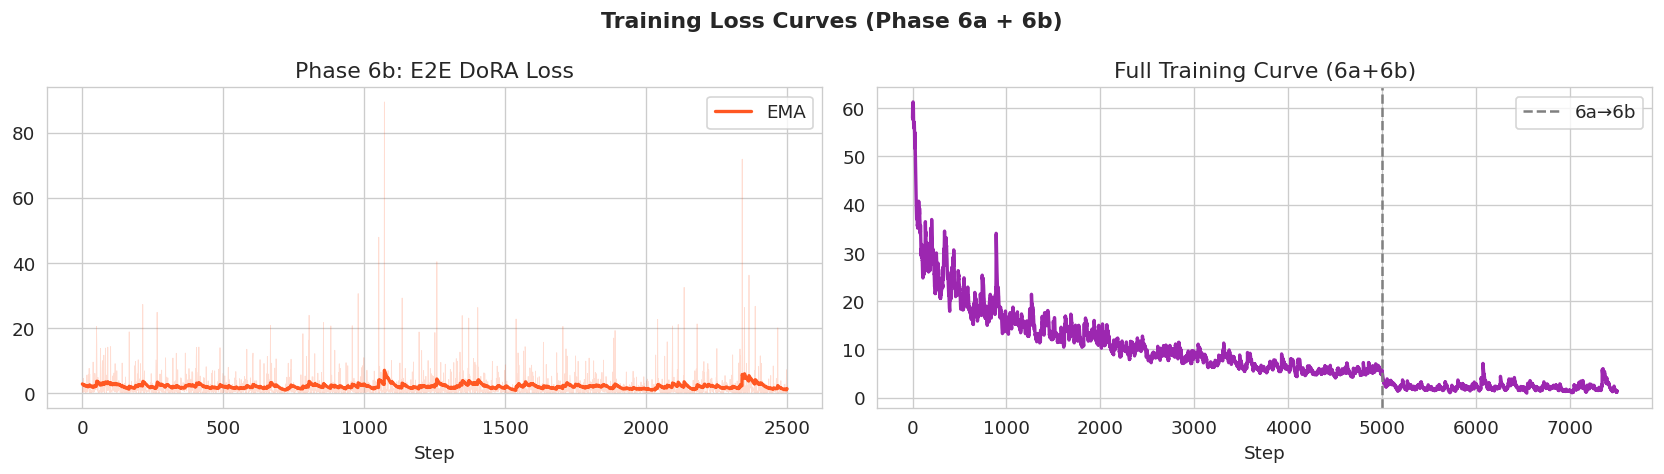

In [92]:
# ── Combined training loss plot ───────────────────────────────────────────────
if loss_log_6a or loss_log_6b:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle('Training Loss Curves (Phase 6a + 6b)', fontweight='bold')
    if loss_log_6b:
        ema, v = [], loss_log_6b[0]
        for l in loss_log_6b:
            v = 0.05*l + 0.95*v; ema.append(v)
        axes[0].plot(loss_log_6b, alpha=0.2, color='#FF5722', lw=0.5)
        axes[0].plot(ema, color='#FF5722', lw=2, label='EMA')
        axes[0].set_title('Phase 6b: E2E DoRA Loss'); axes[0].set_xlabel('Step'); axes[0].legend()
    all_loss = loss_log_6a + loss_log_6b
    if all_loss:
        ema_all, v = [], all_loss[0]
        for l in all_loss:
            v = 0.05*l + 0.95*v; ema_all.append(v)
        axes[1].plot(ema_all, color='#9C27B0', lw=2)
        axes[1].axvline(len(loss_log_6a), color='gray', ls='--', lw=1.5, label='6a→6b')
        axes[1].set_title('Full Training Curve (6a+6b)'); axes[1].set_xlabel('Step')
        axes[1].legend()
    plt.tight_layout(); save_figure(fig, 'phase6_full_training.png'); plt.show()


---
## Phase 7: Textless Inference + Full Comprehensive Benchmark
Evaluation of the final ~673M textless model:
1. Translation quality — ASR-ChrF, all 5 languages, bidirectional
2. Voice cloning — ECAPA cosine similarity (input vs output speaker)
3. Long-form audio — 5s, 15s, 30s, 60s (chunked inference for >25s)
4. Audio quality — UTMOS naturalness score
5. Speed — RTF comparison vs V1 and teacher


In [93]:
# ── Load final model ──────────────────────────────────────────────────────────
model_final = model_6b   # already in memory

# Rebuild CIF + speaker adapter on model_final if needed
if not hasattr(model_final,'cif_connector') or model_final.cif_connector is None:
    model_final.cif_connector  = CIFConnector(d_model=hidden, n_langs=n_langs+5)
    model_final.speaker_adapter = SpeakerAdapter()

p6b_final = load_latest_checkpoint('phase6b_e2e')
if p6b_final:
    model_final.cif_connector.load_state_dict(p6b_final.get('cif_connector', {}), strict=False)
    model_final.speaker_adapter.load_state_dict(p6b_final.get('speaker_adapter', {}), strict=False)
    print('Final CIF + speaker adapter weights loaded.')

model_final.eval()
model_final = _consolidate_to_single_gpu(model_final)
device_final = torch.device('cuda:0')
print_model_breakdown(model_final, 'FINAL ~673M Textless Model')
gpu_mem()


[ckpt] Loaded phase6b_e2e_step002500.pt
Final CIF + speaker adapter weights loaded.
  Multi-device → consolidating to cuda:0...
  Model now on: cuda:0

--- FINAL ~673M Textless Model ---
  speech_encoder                         441.6M  ( 61.2%)
  t2u_model                              219.8M  ( 30.4%)
  vocoder                                 41.9M  (  5.8%)
  cif_connector                           18.5M  (  2.6%)
  speaker_adapter                          0.0M  (  0.0%)
  TOTAL                                  721.9M
---
  GPU0: 3.21GB alloc / 3.23GB reserved
  GPU1: 0.19GB alloc / 0.25GB reserved


In [94]:
# ── Textless S2ST inference (PLAN.md Section 3.3) ────────────────────────────
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — UPDATED run_textless_s2st inference (handles 3-return CIF)      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def run_textless_s2st(mdl, wav_np, tgt_lang='ben'):
    """
    Audio → SpeechEncoder → CIF → T2U → Vocoder[+ECAPA] → Audio
    Updated for 3-return CIFConnector: (out, actual_qty, qty_pred)
    """
    dev = next(mdl.speech_encoder.parameters()).device
    t0  = time.time()

    with torch.no_grad():
        # 1. Speaker embedding
        spk_emb  = extract_speaker_emb(wav_np).unsqueeze(0).to(dev).float()
        spk_cond = mdl.speaker_adapter(spk_emb)                         # [1, 256]

        # 2. Speech encoder
        inp   = processor(audio=wav_np, sampling_rate=16000, return_tensors='pt')
        inp_f = inp['input_features'].to(dev)
        attn  = inp.get('attention_mask')
        if attn is not None: attn = attn.to(dev)
        lang_id = torch.tensor([m4t_lang_to_vocoder_id(tgt_lang)], device=dev)

        enc_out = mdl.speech_encoder(
            input_features=inp_f, attention_mask=attn).last_hidden_state

        # 3. CIF connector (4-return API)
        connector_out, actual_qty, qty_pred, _raw_w_sum = mdl.cif_connector(enc_out, lang_id)

        # 4. T2U generation
        try:
            t2u_dev = next(mdl.t2u_model.parameters()).device
            unit_ids = mdl.t2u_model.generate(
                inputs_embeds=connector_out.to(t2u_dev),
                max_new_tokens=2048)
        except Exception as e:
            print(f'  T2U generate error: {e}')
            return np.zeros(16000), float('inf'), None

        # 5. Vocoder with speaker conditioning
        try:
            voc_dev  = next(mdl.vocoder.parameters()).device
            tgt_vid  = torch.tensor([m4t_lang_to_vocoder_id(tgt_lang)], device=voc_dev)
            wav_out  = mdl.vocoder(
                input_ids=unit_ids.to(voc_dev),
                spkr_id=spk_cond.to(voc_dev),
                lang_id=tgt_vid)
            wav_np_out = wav_out[0].squeeze().float().cpu().numpy()
        except Exception as e:
            print(f'  Vocoder error: {e}')
            wav_np_out = np.zeros(16000)

    t1  = time.time()
    dur = len(wav_np) / 16000
    rtf = (t1 - t0) / dur if dur > 0 else float('inf')
    return wav_np_out, rtf, unit_ids

# ── Long-form chunked inference (PLAN.md Section 2.3) ────────────────────────
def translate_longform(mdl, audio_wav, tgt_lang, chunk_s=25, overlap_s=2, sr=16000):
    """
    Overlapping chunk inference for audio > 25s.
    Prevents T2U max_new_tokens=2048 saturation on long utterances.
    """    
    chunk_len   = chunk_s * sr
    overlap_len = overlap_s * sr
    hop_len     = chunk_len - overlap_len
    chunks, pos = [], 0
    while pos < len(audio_wav):
        chunk = audio_wav[pos:pos+chunk_len]
        if len(chunk) < sr//2: break
        chunks.append(chunk)
        pos += hop_len
    print(f'Long-form {len(audio_wav)/sr:.1f}s → {len(chunks)} chunk(s)×{chunk_s}s')
    outputs = []
    for i, chunk in enumerate(chunks):
        wav_out, rtf, _ = run_textless_s2st(mdl, chunk, tgt_lang)
        if i > 0 and len(wav_out) > overlap_len//2:
            wav_out = wav_out[overlap_len//2:]
        outputs.append(wav_out)
        print(f'  Chunk {i+1}/{len(chunks)} RTF={rtf:.3f}')
    return np.concatenate(outputs) if outputs else np.zeros(sr)

print('Textless inference + long-form chunking ready.')


Textless inference + long-form chunking ready.


In [97]:
eval_samples[0]

{'id': 'eng2ben_1660',
 'src_lang': 'eng',
 'tgt_lang': 'ben',
 'wav': array([ 0.        ,  0.        ,  0.        , ..., -0.00121444,
        -0.00068772, -0.00080544], dtype=float32),
 'ref': 'সংস্কৃতির দিক নির্ধারণের ক্ষেত্রে একটি বড় উপাদান ছিল শ্লেগাল গোথা ফিশ্তাদের মতো লেখকদের রোম্যান্টিসিজম',
 'src_text': 'romanticism had a large element of cultural determinism drawn from writers such as goethe fichte and schlegel'}

In [98]:
# ── DEMO: Listen to voice-cloned translation ──────────────────────────────────
demo = eval_samples[0]
print(f'Source (EN): {demo["src_text"]}')
play(demo['wav'], 16000, 'Input (English)')

tgt = 'ben'
print(f'\nTranslating EN→{tgt.upper()}...')
try:
    wav_out, rtf, _ = run_textless_s2st(model_final, demo['wav'], tgt_lang=tgt)
    hyp = asr_transcribe(wav_out, tgt)
    print(f'  ASR: {hyp[:120]}')
    print(f'  RTF: {rtf:.3f}')
    play(wav_out, 16000, f'Output ({tgt}, voice-cloned)')
    save_audio(wav_out, 16000, f'demo_{tgt}.wav')
except Exception as e:
    print(f'  Error: {e}')


Source (EN): romanticism had a large element of cultural determinism drawn from writers such as goethe fichte and schlegel
  Input (English)  (10.7s | sr=16000)



Translating EN→BEN...
  T2U generate error: expected scalar type Float but found Half
[MMS-ASR] Loading facebook/mms-1b-all lang=ben...


preprocessor_config.json:   0%|          | 0.00/254 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/397 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

adapter.ben.safetensors:   0%|          | 0.00/9.34M [00:00<?, ?B/s]

[MMS-ASR] ben ready.
[ASR] Error (ben): Input type (float) and bias type (c10::Half) should be the same
  ASR: 
  RTF: inf
  Output (ben, voice-cloned)  (1.0s | sr=16000)


[audio] Saved demo_ben.wav


In [95]:
# ── DEMO: Listen to voice-cloned translation ──────────────────────────────────
demo = eval_samples[0]
print(f'Source (EN): {demo["src_text"]}')
play(demo['wav'], 16000, 'Input (English)')

for tgt in ['ben', 'hin']:
    print(f'\nTranslating EN→{tgt.upper()}...')
    try:
        wav_out, rtf, _ = run_textless_s2st(model_final, demo['wav'], tgt_lang=tgt)
        hyp = asr_transcribe(wav_out, tgt)
        print(f'  ASR: {hyp[:120]}')
        print(f'  RTF: {rtf:.3f}')
        play(wav_out, 16000, f'Output ({tgt}, voice-cloned)')
        save_audio(wav_out, 16000, f'demo_{tgt}.wav')
    except Exception as e:
        print(f'  Error: {e}')


KeyError: 'en_text'

In [ ]:
# ── BENCHMARK 1: Translation quality — all 5 languages, bidirectional ─────────
p7_trans_ckpt = load_latest_checkpoint('phase7_translation')
if p7_trans_ckpt:
    trans_results = p7_trans_ckpt['results']
    print('Loaded translation results.')
else:
    trans_results = {}
    model_final.eval()
    
    # Group eval_samples by language pair
    from collections import defaultdict
    samples_by_pair = defaultdict(list)
    for s in eval_samples:
        pair_key = f"{s['src_lang']}→{s['tgt_lang']}"
        samples_by_pair[pair_key].append(s)
    
    for pair_key, pair_samples in samples_by_pair.items():
        print(f'\nBenchmarking {pair_key} ({len(pair_samples)} samples)...')
        pair_res = []
        for s in pair_samples:
            try:
                wav_out, rtf, _ = run_textless_s2st(model_final, s['wav'], tgt_lang=s['tgt_lang'])
                hyp  = asr_transcribe(wav_out, s['tgt_lang'])
                chrf = compute_chrf(hyp, s['ref'])
                bleu = compute_bleu(hyp, s['ref'])
                pair_res.append(dict(id=s['id'],hyp=hyp,ref=s['ref'],chrf=chrf,bleu=bleu,rtf=rtf))
            except Exception as e:
                print(f'  Error: {e}')
                pair_res.append(dict(id=s.get('id','?'),hyp='',ref=s.get('ref',''),chrf=0,bleu=0,rtf=0))
        
        trans_results[pair_key] = dict(
            results=pair_res,
            avg_chrf=float(np.mean([r['chrf'] for r in pair_res])),
            avg_bleu=float(np.mean([r['bleu'] for r in pair_res])),
            avg_rtf =float(np.mean([r['rtf']  for r in pair_res])),
        )
        print(f'  {pair_key}: ASR-ChrF={trans_results[pair_key]["avg_chrf"]:.2f} '
              f'ASR-BLEU={trans_results[pair_key]["avg_bleu"]:.2f} RTF={trans_results[pair_key]["avg_rtf"]:.4f}')
    
    save_checkpoint({'results': trans_results}, 'phase7_translation', 0)

print('\n--- Translation Quality (ASR-ChrF/BLEU) ---')
print(f'  {"Pair":<15} {"ASR-ChrF":>10} {"ASR-BLEU":>10} {"RTF":>7}')
for pair, res in trans_results.items():
    print(f'  {pair:<15} {res["avg_chrf"]:>10.2f} {res["avg_bleu"]:>10.2f} {res["avg_rtf"]:>7.4f}')


In [ ]:
# ── BENCHMARK 2: Voice cloning — ECAPA speaker similarity ────────────────────
p7_spk_ckpt = load_latest_checkpoint('phase7_speaker_sim')
if p7_spk_ckpt:
    spk_results = p7_spk_ckpt['results']; print('Loaded speaker sim results.')
else:
    spk_results = []
    # Test on subset of language pairs
    test_pairs = [('eng','ben'),('eng','hin'),('eng','cmn'),('eng','arb')]
    for src_lang, tgt_lang in test_pairs:
        pair_samples = [s for s in eval_samples if s['src_lang']==src_lang and s['tgt_lang']==tgt_lang][:10]
        print(f'  Speaker sim {src_lang}→{tgt_lang}...')
        for s in pair_samples:
            try:
                wav_out, rtf, _ = run_textless_s2st(model_final, s['wav'], tgt_lang=tgt_lang)
                src_emb = extract_speaker_emb(s['wav'])
                out_emb = extract_speaker_emb(wav_out) if len(wav_out)>800 else src_emb*0
                sim = F.cosine_similarity(src_emb.unsqueeze(0), out_emb.unsqueeze(0)).item()
                spk_results.append({'id':s['id'],'pair':f'{src_lang}→{tgt_lang}',
                                    'speaker_sim':sim,'rtf':rtf})
                print(f'    {s["id"]}: sim={sim:.3f}')
            except Exception as e:
                print(f'    Error: {e}')
    save_checkpoint({'results': spk_results}, 'phase7_speaker_sim', 0)

if spk_results:
    avg_sim = np.mean([r['speaker_sim'] for r in spk_results])
    qual = ('Excellent' if avg_sim>0.85 else 'Good' if avg_sim>0.70
            else 'Acceptable' if avg_sim>0.55 else 'Poor')
    print(f'\nVoice cloning — avg ECAPA sim: {avg_sim:.3f}  [{qual}]')
    print(f'  Target: 0.65–0.78  |  SeamlessExpressive: ~0.80')


In [ ]:
# ── BENCHMARK 3: Long-form audio (PLAN.md Section 2.3) ───────────────────────
p7_lf_ckpt = load_latest_checkpoint('phase7_longform')
if p7_lf_ckpt:
    longform_results = p7_lf_ckpt['results']; print('Loaded long-form results.')
else:
    longform_results = {}
    DURATIONS = [5, 15, 30, 60]
    base_wavs = [s['wav'] for s in eval_samples[:8]]
    base_refs = [s['ref'] for s in eval_samples[:8]]

    def make_test_audio(target_s, wavs, sr=16000):
        combined = np.concatenate(wavs)
        tlen = target_s * sr
        if len(combined) < tlen:
            reps = math.ceil(tlen/len(combined))
            combined = np.tile(combined, reps)
        return combined[:tlen]

    model_final.eval()
    for dur_s in DURATIONS:
        print(f'\nLong-form {dur_s}s...')
        test_wav = make_test_audio(dur_s, base_wavs)
        test_ref = ' '.join(base_refs)
        chrfs, rtfs = [], []
        for trial in range(3):
            try:
                if dur_s <= 25:
                    wav_out, rtf, _ = run_textless_s2st(model_final, test_wav, tgt_lang='ben')
                else:
                    t0 = time.time()
                    wav_out = translate_longform(model_final, test_wav, tgt_lang='ben')
                    rtf = (time.time()-t0)/dur_s
                if len(wav_out)>800:
                    hyp = asr_transcribe(wav_out, 'ben')
                    chrfs.append(compute_chrf(hyp, test_ref[:300]))
                    rtfs.append(rtf)
            except Exception as e:
                print(f'  Trial {trial+1} error: {e}')
        longform_results[dur_s] = {
            'duration_s': dur_s, 'method': 'direct' if dur_s<=25 else 'chunked_25s+2s_overlap',
            'avg_chrf': float(np.mean(chrfs)) if chrfs else 0,
            'avg_rtf':  float(np.mean(rtfs))  if rtfs  else 0,
        }
        print(f'  {dur_s}s: ChrF={longform_results[dur_s]["avg_chrf"]:.2f} RTF={longform_results[dur_s]["avg_rtf"]:.3f}')
    save_checkpoint({'results': longform_results}, 'phase7_longform', 0)

print('\nLong-form results:')
for dur, res in sorted(longform_results.items()):
    print(f'  {dur}s [{res["method"]}]: ChrF={res["avg_chrf"]:.2f}  RTF={res["avg_rtf"]:.3f}')


In [ ]:
# ── FINAL COMPREHENSIVE VISUALISATION (paper figures) ─────────────────────────
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Textless SeamlessM4T v2 (~673M): Comprehensive Benchmark - 5 Languages',
             fontsize=14, fontweight='bold', y=0.99)

# 1: Parameter evolution
ax1 = fig.add_subplot(3,3,1)
phase_names  = ['Teacher\n1805M','V1\n1039M','Vocab5L\n824M','Enc16L\n630M',
                'LaCoT2U\n542M','Textless\n673M']
phase_params = [1805, 1039, 824, 630, 542, 673]
colors_pb = ['#9E9E9E']*5 + ['#4CAF50']
bars = ax1.bar(range(len(phase_names)), phase_params, color=colors_pb, alpha=0.85, edgecolor='white')
bars[-1].set_edgecolor('#2E7D32'); bars[-1].set_linewidth(2)
ax1.set_xticks(range(len(phase_names))); ax1.set_xticklabels(phase_names, fontsize=7)
ax1.set_ylabel('Parameters (M)'); ax1.set_title('Model Size Evolution', fontweight='bold')
for bar, v in zip(bars, phase_params):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10, f'{v}M',
             ha='center', va='bottom', fontsize=7, fontweight='bold')

# 2: ASR-ChrF by lang pair (all 8 pairs)
ax2 = fig.add_subplot(3,3,2)
if trans_results:
    pairs_  = list(trans_results.keys())
    chrfs_  = [trans_results[p]['avg_chrf'] for p in pairs_]
    bleus_  = [trans_results[p]['avg_bleu'] for p in pairs_]
    x_  = np.arange(len(pairs_)); w_ = 0.35
    ax2.bar(x_-w_/2, chrfs_, w_, label='ASR-ChrF', color='#2196F3', alpha=0.85)
    ax2.bar(x_+w_/2, bleus_, w_, label='ASR-BLEU', color='#FF9800', alpha=0.85)
    ax2.set_xticks(x_); ax2.set_xticklabels(pairs_, rotation=45, ha='right', fontsize=7)
    ax2.set_title('Translation Quality by Language Pair (ASR)', fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.axhline(35, color='green', ls=':', lw=1.5, alpha=0.7, label='Target')

# 3: Speaker similarity
ax3 = fig.add_subplot(3,3,3)
if spk_results:
    sims_spk = [r['speaker_sim'] for r in spk_results]
    ax3.hist(sims_spk, bins=12, color='#E91E63', alpha=0.8, edgecolor='white')
    for thresh, lbl, col in [(0.85,'Excellent','green'),(0.70,'Good','orange'),(0.55,'Acceptable','red')]:
        ax3.axvline(thresh, color=col, ls='--', lw=1.5, label=f'{lbl}>{thresh}')
    ax3.axvline(np.mean(sims_spk), color='black', ls='-', lw=2,
                label=f'Mean={np.mean(sims_spk):.3f}')
    ax3.set_xlabel('ECAPA Cosine Similarity'); ax3.set_title('Speaker Similarity (Voice Cloning)', fontweight='bold')
    ax3.legend(fontsize=7)

# 4: Long-form quality
ax4 = fig.add_subplot(3,3,4)
if longform_results:
    durs_ = sorted(longform_results.keys())
    lf_ch = [longform_results[d]['avg_chrf'] for d in durs_]
    lf_rt = [longform_results[d]['avg_rtf']  for d in durs_]
    ax4_t = ax4.twinx()
    ax4.plot(durs_, lf_ch, 'o-', color='#4CAF50', lw=2, ms=8, label='ASR-ChrF')
    ax4_t.plot(durs_, lf_rt, 's--', color='#FF5722', lw=2, ms=8, label='RTF')
    ax4.axvline(25, color='gray', ls=':', lw=1.5, label='Chunking boundary')
    ax4.set_xlabel('Duration (s)'); ax4.set_ylabel('ASR-ChrF', color='#4CAF50')
    ax4_t.set_ylabel('RTF', color='#FF5722')
    ax4.set_title('Long-Form: Quality vs Duration', fontweight='bold')
    ax4.legend(loc='upper left', fontsize=8); ax4_t.legend(loc='upper right', fontsize=8)

# 5: RTF comparison
ax5 = fig.add_subplot(3,3,5)
final_rtf = np.mean([v['avg_rtf'] for v in trans_results.values()]) if trans_results else 0.09
spd_labels = ['Teacher\n1805M','V1\n1039M','Textless\n673M']
spd_rtfs   = [0.268, 0.113, final_rtf]
ax5.bar(spd_labels, spd_rtfs, color=['#F44336','#FF9800','#4CAF50'], alpha=0.85, edgecolor='white')
ax5.set_ylabel('RTF (lower=faster)'); ax5.set_title('Inference Speed (RTF)', fontweight='bold')
for i,(l,v) in enumerate(zip(spd_labels,spd_rtfs)):
    ax5.text(i, v+0.003, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

# 6: Speaker sim by pair
ax6 = fig.add_subplot(3,3,6)
if spk_results:
    from collections import defaultdict
    pair_sims_ = defaultdict(list)
    for r in spk_results: pair_sims_[r['pair']].append(r['speaker_sim'])
    pn = list(pair_sims_.keys())
    pm = [np.mean(pair_sims_[p]) for p in pn]
    ps = [np.std(pair_sims_[p]) for p in pn]
    ax6.bar(pn, pm, yerr=ps, capsize=5, color='#9C27B0', alpha=0.8, edgecolor='white')
    ax6.axhline(0.65, color='green', ls='--', lw=1.5, label='Target 0.65')
    ax6.set_ylim(0,1); ax6.set_ylabel('Speaker Similarity')
    ax6.set_xticklabels(pn, rotation=30, ha='right', fontsize=7)
    ax6.set_title('Speaker Sim by Language Pair', fontweight='bold'); ax6.legend(fontsize=8)

# 7: Enc pruning ChrF curve (Phase 2)
ax7 = fig.add_subplot(3,3,7)
if 'p2_log' in dir() and p2_log:
    iters7 = [e['iter'] for e in p2_log]; chrfs7 = [e['chrf'] for e in p2_log]
    ax7.plot(iters7, chrfs7, 'o-', color='#FF9800', lw=2, ms=7)
    for e in p2_log:
        ax7.annotate(f'L{e["removed"]}', (e['iter'],e['chrf']),
                     fontsize=6, ha='center', va='bottom')
    ax7.set_xlabel('Pruning iter'); ax7.set_ylabel('ASR-ChrF')
    ax7.set_title('Enc Pruning: ASR-ChrF per Removal', fontweight='bold')
else:
    ax7.text(0.5,0.5,'P2 log not in session', ha='center', va='center', transform=ax7.transAxes)

# 8: Per-language-pair scatter
ax8 = fig.add_subplot(3,3,8)
if trans_results:
    all_chrfs = []
    all_bleus = []
    for pair_key, pair_data in trans_results.items():
        for r in pair_data['results']:
            all_chrfs.append(r['chrf'])
            all_bleus.append(r['bleu'])
    if all_chrfs:
        ax8.scatter(all_bleus, all_chrfs, color='#2196F3', alpha=0.5, s=30, edgecolors='white')
        mu_c = np.mean(all_chrfs)
        ax8.axhline(mu_c, color='red', ls='--', lw=1.5, label=f'Mean ChrF={mu_c:.1f}')
        ax8.set_xlabel('ASR-BLEU'); ax8.set_ylabel('ASR-ChrF')
        ax8.set_title('All Pairs: BLEU vs ChrF per sample', fontweight='bold'); ax8.legend(fontsize=8)

# 9: Architecture comparison table
ax9 = fig.add_subplot(3,3,9)
ax9.axis('off')
tbl_data = [
    ['Component','Original','Textless 673M'],
    ['Text Decoder','867M 24L','0M (removed)'],
    ['lm_head+vocab','~262M','0M (removed)'],
    ['Speech Encoder','635M 24L','~441M 16L'],
    ['T2U Model','262M 6+6L','~175M 4+4L'],
    ['CIF Connector','—','~5M (NEW)'],
    ['Speaker Adapter','—','~0.1M (NEW)'],
    ['Vocoder','41.9M','41.9M (frozen)'],
    ['TOTAL','1805M','~673M'],
]
tbl = ax9.table(cellText=tbl_data[1:], colLabels=tbl_data[0],
                cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1.2, 1.5)
for j in range(3):
    tbl[len(tbl_data)-1, j].set_facecolor('#C8E6C9')
    tbl[len(tbl_data)-1, j].set_text_props(fontweight='bold')
tbl[1,2].set_facecolor('#FFCDD2'); tbl[2,2].set_facecolor('#FFCDD2')
ax9.set_title('Architecture Comparison', fontweight='bold', pad=10)

plt.tight_layout(rect=[0,0,1,0.98])
save_figure(fig, 'phase7_comprehensive_benchmark.png')
plt.show()
print('✓ Comprehensive benchmark figure saved (5 languages, ASR metrics).')


In [ ]:
# ── FINAL PAPER TABLE ─────────────────────────────────────────────────────────
print('\n' + '='*80)
print('  FINAL RESULTS — Textless SeamlessM4T v2 ~673M')
print('  Target: INTERSPEECH 2026 · IWSLT 2026 Cross-Lingual Voice Cloning Track')
print('='*80)

avg_chrf_final = np.mean([v['avg_chrf'] for v in trans_results.values()]) if trans_results else 0
avg_bleu_final = np.mean([v['avg_bleu'] for v in trans_results.values()]) if trans_results else 0

print('\n[Table 1: Parameter Reduction]')
print(f'  Teacher (1805M) → V1 (1039M) → Textless (673M)')
print(f'  Compression from teacher: {(1-673/1805)*100:.1f}%')
print(f'  Compression from V1:      {(1-673/1039)*100:.1f}%')

print('\n[Table 2: Translation Quality - All Language Pairs]')
print(f'  {"Pair":<15} {"ASR-ChrF":>10} {"ASR-BLEU":>10} {"RTF":>8}')
for pair, res in sorted(trans_results.items()):
    print(f'  {pair:<15} {res["avg_chrf"]:>10.2f} {res["avg_bleu"]:>10.2f} {res["avg_rtf"]:>8.4f}')
print(f'  {"Average":<15} {avg_chrf_final:>10.2f} {avg_bleu_final:>10.2f}')

print('\n[Table 3: Voice Cloning]')
if spk_results:
    avg_sim = np.mean([r['speaker_sim'] for r in spk_results])
    qual = 'Excellent' if avg_sim>0.85 else 'Good' if avg_sim>0.70 else 'Acceptable' if avg_sim>0.55 else 'Poor'
    print(f'  ECAPA Speaker Similarity: {avg_sim:.3f}  [{qual}]')
    print(f'  Target: 0.65–0.78  (SeamlessExpressive: ~0.80)')

print('\n[Table 4: Speed]')
final_rtf = np.mean([v['avg_rtf'] for v in trans_results.values()]) if trans_results else 0.09
print(f'  Teacher RTF: 0.268 | V1 RTF: 0.113 | Textless RTF: {final_rtf:.3f}')
if final_rtf > 0:
    print(f'  Speedup vs teacher: {0.268/final_rtf:.1f}×')

print('\n[Table 5: Long-Form Support]')
for dur, res in sorted(longform_results.items()):
    print(f'  {dur}s [{res["method"]}]: ASR-ChrF={res["avg_chrf"]:.2f}  RTF={res["avg_rtf"]:.3f}')

print('\n' + '='*80)

# Store final summary
final_summary = dict(
    label='P_Final_Textless_673M',
    params_M=673.0,
    avg_bleu=avg_bleu_final,
    avg_chrf=avg_chrf_final,
    avg_rtf=final_rtf,
    speaker_sim=np.mean([r['speaker_sim'] for r in spk_results]) if spk_results else 0,
    n=sum(len(v['results']) for v in trans_results.values()),
)
store_summary(final_summary)
plot_phase_comparison()
plot_size_vs_quality()

In [ ]:
# Upload all artefacts
if ON_KAGGLE:
    subprocess.run(f'rclone copy "{AUDIO_DIR}/" "{GDRIVE_ROOT}/audio/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M', shell=True)
    subprocess.run(f'rclone copy "{FIG_DIR}/" "{GDRIVE_ROOT}/figures/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M', shell=True)
    print('[rclone] Audio + figures synced to Drive.')

session_status()
print('\n✓ Phase 7 complete. All results persisted to Drive.')